# Setup

Install the necessary dependencies and PILE dataset, from which we generate the corpus for the first k checkpoints as well as its corresponding index.

In [ ]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"          # avoid xet dependency
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"   # faster downloads

from huggingface_hub import snapshot_download
from transformers import AutoTokenizer

# 1) Download just the first shard
local_dir = "pile_deduped_shard0"
snapshot_download(
    repo_id="EleutherAI/pile-deduped-pythia-preshuffled",
    repo_type="dataset",
    allow_patterns=["document-00000-of-00020.bin"],
    local_dir=local_dir,
    local_dir_use_symlinks=False,
)

shard0 = f"{local_dir}/document-00000-of-00020.bin"

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


document-00000-of-00020.bin:   0%|          | 0.00/30.0G [00:00<?, ?B/s]

In [ ]:
import numpy as np

PYTHIA_TOKENS_PER_STEP = 2_097_152  # 2^21
EARLY_STEPS_12 = np.array([0,1,2,4,8,16,32,64,128,256,512,1000], dtype=np.int64)

# [3000, 13000, 23000, 33000, 43000, 53000, 63000, 73000, 83000, 93000, 103000, 113000, 123000, 133000, 143000]

EARLY_CUTOFFS_12 = EARLY_STEPS_12 * np.int64(PYTHIA_TOKENS_PER_STEP)
T_MAX = int(EARLY_CUTOFFS_12.max())

tok = AutoTokenizer.from_pretrained("EleutherAI/pythia-70m-deduped")
dtype = np.uint16 if tok.vocab_size <= 2**16 else np.uint32
vocab_param = 2**16 if tok.vocab_size <= 2**16 else 2**32

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

In [ ]:
from pathlib import Path

prefix_dir = Path("./pile_prefix_step1000")
prefix_dir.mkdir(parents=True, exist_ok=True)
prefix_bin = prefix_dir / f"document-prefix-{T_MAX}.bin"

if not prefix_bin.exists():
    n_bytes = Path(shard0).stat().st_size
    tokens_in_shard = n_bytes // np.dtype(dtype).itemsize
    if T_MAX > tokens_in_shard:
        raise ValueError(f"Need {T_MAX:,} tokens but shard0 has only {tokens_in_shard:,}. "
                         "Download the next shard or lower MAX step.")
    src = np.memmap(shard0, dtype=dtype, mode="r")
    chunk = 64_000_000  # tokens per chunk (~128MB for u16)
    with open(prefix_bin, "wb") as f:
        for start in range(0, T_MAX, chunk):
            end = min(T_MAX, start + chunk)
            f.write(src[start:end].tobytes())
    del src

In [ ]:
from ngrams.backends.tokengrams import TokengramsIndex

tkg_idx = prefix_bin.with_suffix(".tkg.idx")
tg = TokengramsIndex()
tg.build_index(
    corpus_path=str(prefix_bin),
    index_path=str(tkg_idx),
    vocab=vocab_param,
    verbose=True,
    load_only=tkg_idx.exists(),  # skip rebuild if the index is already there
)

If running this notebook for the first time, feel free to try out the two code blocks below as a smoke test to see whether the ngrams API is working properly.

In [ ]:
from typing import List, Tuple, Dict
import numpy as np
from ngrams.interface import batch_counts

def encode_ngrams(text_grams: List[str]) -> List[Tuple[int, ...]]:
    out = []
    for g in text_grams:
        ids = tok.encode(g)
        if ids:
            out.append(tuple(int(i) for i in ids))
    return out

def counts_matrix(ngrams_ids: List[Tuple[int,...]]) -> np.ndarray:
    cmap: Dict[Tuple[int,...], np.ndarray] = batch_counts(
        ngrams=ngrams_ids,
        cutoffs=EARLY_CUTOFFS_12,
        index=tg,
        batch_size=5000,
        cutoffs_are_token_counts=True,
    )
    # preserve input order
    return np.vstack([cmap[ng] for ng in ngrams_ids]) if ngrams_ids else np.zeros((0, EARLY_CUTOFFS_12.shape[0]), dtype=np.int64)

In [ ]:
# Quick smoke test

grams = [" the", "of", " in", " to"]     # replace with your set
ng_ids = encode_ngrams(grams)
counts = counts_matrix(ng_ids)             # shape [len(grams), 12]
print(counts)

[[       0    59526   117202   237124   469994   942306  1899625  3795254
   7577424 15160987 30311255 59215953]
 [       0      363      691     1460     3002     6101    12100    24255
     48721    98038   195456   382118]
 [       0    20052    39791    80928   160411   320361   642784  1287148
   2574060  5150785 10299817 20129007]
 [       0    29058    56738   113640   226763   453458   909072  1821609
   3644623  7298253 14594397 28507989]]


# Candidate N-Grams

Generate the list of candidate n-grams, which will be queried against the Tokengrams API.

In [ ]:
from typing import List, Tuple, Dict
from pathlib import Path
import numpy as np
import pandas as pd

capital_pairs: List[Tuple[str, str]] = [
    ("United States", "Washington"), ("United Kingdom", "London"),
    ("France", "Paris"), ("Japan", "Tokyo"),
    ("Germany", "Berlin"), ("Canada", "Ottawa"),
    ("Italy", "Rome"), ("Spain", "Madrid"),
    ("South Korea", "Seoul"), ("Australia", "Canberra"),
    ("Mongolia", "Ulaanbaatar"), ("Kyrgyzstan", "Bishkek"),
    ("Tuvalu", "Funafuti"), ("Samoa", "Apia"),
    ("Afghanistan", "Kabul"),
    ("Albania", "Tirana"),
    ("Algeria", "Algiers"),
    ("Andorra", "Andorra la Vella"),
    ("Angola", "Luanda"),
    ("Antigua and Barbuda", "St. John's"),
    ("Argentina", "Buenos Aires"),
    ("Armenia", "Yerevan"),
    ("Austria", "Vienna"),
    ("Azerbaijan", "Baku"),
    ("Bahamas", "Nassau"),
    ("Bahrain", "Manama"),
    ("Bangladesh", "Dhaka"),
    ("Barbados", "Bridgetown"),
    ("Belarus", "Minsk"),
    ("Belgium", "Brussels"),
    ("Belize", "Belmopan"),
    ("Benin", "Porto-Novo"),
    ("Bhutan", "Thimphu"),
    ("Bolivia", "La Paz"),
    ("Bosnia and Herzegovina", "Sarajevo"),
    ("Botswana", "Gaborone"),
    ("Brazil", "Brasília"),
    ("Brunei", "Bandar Seri Begawan"),
    ("Bulgaria", "Sofia"),
    ("Burkina Faso", "Ouagadougou"),
    ("Burundi", "Gitega"),
    ("Cabo Verde", "Praia"),
    ("Cambodia", "Phnom Penh"),
    ("Cameroon", "Yaoundé"),
    ("Central African Republic", "Bangui"),
    ("Chad", "N'Djamena"),
    ("Chile", "Santiago"),
    ("China", "Beijing"),
    ("Colombia", "Bogotá"),
    ("Comoros", "Moroni"),
    ("Democratic Republic of the Congo", "Kinshasa"),
    ("Republic of the Congo", "Brazzaville"),
    ("Costa Rica", "San José"),
    ("Côte d'Ivoire", "Yamoussoukro"),
    ("Croatia", "Zagreb"),
    ("Cuba", "Havana"),
    ("Cyprus", "Nicosia"),
    ("Czechia", "Prague"),
    ("Denmark", "Copenhagen"),
    ("Djibouti", "Djibouti"),
    ("Dominica", "Roseau"),
    ("Dominican Republic", "Santo Domingo"),
    ("Ecuador", "Quito"),
    ("Egypt", "Cairo"),
    ("El Salvador", "San Salvador"),
    ("Equatorial Guinea", "Malabo"),
    ("Eritrea", "Asmara"),
    ("Estonia", "Tallinn"),
    ("Eswatini", "Mbabane"),
    ("Ethiopia", "Addis Ababa"),
    ("Fiji", "Suva"),
    ("Finland", "Helsinki"),
    ("Gabon", "Libreville"),
    ("Gambia", "Banjul"),
    ("Georgia", "Tbilisi"),
    ("Ghana", "Accra"),
    ("Greece", "Athens"),
    ("Grenada", "St. George's"),
    ("Guatemala", "Guatemala City"),
    ("Guinea", "Conakry"),
    ("Guinea-Bissau", "Bissau"),
    ("Guyana", "Georgetown"),
    ("Haiti", "Port-au-Prince"),
    ("Honduras", "Tegucigalpa"),
    ("Hungary", "Budapest"),
    ("Iceland", "Reykjavík"),
    ("India", "New Delhi"),
    ("Indonesia", "Jakarta"),
    ("Iran", "Tehran"),
    ("Iraq", "Baghdad"),
    ("Ireland", "Dublin"),
    ("Jamaica", "Kingston"),
    ("Jordan", "Amman"),
    ("Kazakhstan", "Astana"),
    ("Kenya", "Nairobi"),
    ("Kiribati", "Tarawa"),
    ("Kuwait", "Kuwait City"),
    ("Laos", "Vientiane"),
    ("Latvia", "Riga"),
    ("Lebanon", "Beirut"),
    ("Lesotho", "Maseru"),
    ("Liberia", "Monrovia"),
    ("Libya", "Tripoli"),
    ("Liechtenstein", "Vaduz"),
    ("Lithuania", "Vilnius"),
    ("Luxembourg", "Luxembourg"),
    ("Madagascar", "Antananarivo"),
    ("Malawi", "Lilongwe"),
    ("Malaysia", "Kuala Lumpur"),
    ("Maldives", "Malé"),
    ("Mali", "Bamako"),
    ("Malta", "Valletta"),
    ("Marshall Islands", "Majuro"),
    ("Mauritania", "Nouakchott"),
    ("Mauritius", "Port Louis"),
    ("Mexico", "Mexico City"),
    ("Micronesia", "Palikir"),
    ("Moldova", "Chișinău"),
    ("Monaco", "Monaco"),
    ("Montenegro", "Podgorica"),
    ("Morocco", "Rabat"),
    ("Mozambique", "Maputo"),
    ("Myanmar", "Naypyidaw"),
    ("Namibia", "Windhoek"),
    ("Nauru", "Yaren"),
    ("Nepal", "Kathmandu"),
    ("Netherlands", "Amsterdam"),
    ("New Zealand", "Wellington"),
    ("Nicaragua", "Managua"),
    ("Niger", "Niamey"),
    ("Nigeria", "Abuja"),
    ("North Korea", "Pyongyang"),
    ("North Macedonia", "Skopje"),
    ("Norway", "Oslo"),
    ("Oman", "Muscat"),
    ("Pakistan", "Islamabad"),
    ("Palau", "Ngerulmud"),
    ("Panama", "Panama City"),
    ("Papua New Guinea", "Port Moresby"),
    ("Paraguay", "Asunción"),
    ("Peru", "Lima"),
    ("Philippines", "Manila"),
    ("Poland", "Warsaw"),
    ("Portugal", "Lisbon"),
    ("Qatar", "Doha"),
    ("Romania", "Bucharest"),
    ("Russia", "Moscow"),
    ("Rwanda", "Kigali"),
    ("Saint Kitts and Nevis", "Basseterre"),
    ("Saint Lucia", "Castries"),
    ("Saint Vincent and the Grenadines", "Kingstown"),
    ("San Marino", "San Marino"),
    ("São Tomé and Príncipe", "São Tomé"),
    ("Saudi Arabia", "Riyadh"),
    ("Senegal", "Dakar"),
    ("Serbia", "Belgrade"),
    ("Seychelles", "Victoria"),
    ("Sierra Leone", "Freetown"),
    ("Singapore", "Singapore"),
    ("Slovakia", "Bratislava"),
    ("Slovenia", "Ljubljana"),
    ("Solomon Islands", "Honiara"),
    ("Somalia", "Mogadishu"),
    ("South Africa", "Pretoria"),
    ("South Sudan", "Juba"),
    ("Sri Lanka", "Sri Jayawardenepura Kotte"),
    ("Sudan", "Khartoum"),
    ("Suriname", "Paramaribo"),
    ("Sweden", "Stockholm"),
    ("Switzerland", "Bern"),
    ("Syria", "Damascus"),
    ("Taiwan", "Taipei"),
    ("Tajikistan", "Dushanbe"),
    ("Tanzania", "Dodoma"),
    ("Thailand", "Bangkok"),
    ("Timor-Leste", "Dili"),
    ("Togo", "Lomé"),
    ("Tonga", "Nukuʻalofa"),
    ("Trinidad and Tobago", "Port of Spain"),
    ("Tunisia", "Tunis"),
    ("Turkey", "Ankara"),
    ("Turkmenistan", "Ashgabat"),
    ("Uganda", "Kampala"),
    ("Ukraine", "Kyiv"),
    ("United Arab Emirates", "Abu Dhabi"),
    ("Uruguay", "Montevideo"),
    ("Uzbekistan", "Tashkent"),
    ("Vanuatu", "Port Vila"),
    ("Vatican City", "Vatican City"),
    ("Venezuela", "Caracas"),
    ("Vietnam", "Hanoi"),
    ("Yemen", "Sana'a"),
    ("Zambia", "Lusaka"),
    ("Zimbabwe", "Harare"),
]

def variants_for_pair(country: str, capital: str) -> List[str]:
    return [
        f" {capital}",
        f" in {capital}",
        f" {capital},",
        f" capital of {country}",
    ]

def encode_capital_ngrams(strings: List[str], max_tokens: int = 3) -> Tuple[List[str], List[Tuple[int, ...]]]:
    texts, ids = [], []
    for s in strings:
        tok_ids = tok.encode(s)
        if 1 <= len(tok_ids) <= max_tokens:
            texts.append(s)
            ids.append(tuple(int(i) for i in tok_ids))
    seen, out_texts, out_ids = set(), [], []
    for t, ng in zip(texts, ids):
        if ng not in seen:
            seen.add(ng); out_texts.append(t); out_ids.append(ng)
    return out_texts, out_ids

# Build the pool
all_texts: List[str] = []
all_ids: List[Tuple[int, ...]] = []
for country, capital in capital_pairs:
    v = variants_for_pair(country, capital)
    t, i = encode_capital_ngrams(v, max_tokens=3)
    all_texts.extend(t); all_ids.extend(i)

In [ ]:
# 3) Count across early checkpoints, then take step=1000 for bucketing
counts_map: Dict[Tuple[int, ...], np.ndarray] = batch_counts(
    ngrams=all_ids,
    cutoffs=EARLY_CUTOFFS_12,
    index=tg,
    batch_size=5000,
    cutoffs_are_token_counts=True,
)
# preserve input order
counts_mat = np.vstack([counts_map[ng] for ng in all_ids]) if all_ids else np.zeros((0, len(EARLY_CUTOFFS_12)), dtype=np.int64)
freq_step1000 = counts_mat[:, -1] if counts_mat.size else np.array([], dtype=np.int64)

In [ ]:
# 4) Bucket by frequency quantiles and sample randomly per bucket
def bucket_indices_by_quantiles(freq: np.ndarray, q: int = 4) -> List[np.ndarray]:
    if freq.size == 0:
        return []
    # Use ranks; duplicates fall naturally into bins
    qs = np.quantile(freq, np.linspace(0, 1, q+1))
    bins = []
    for j in range(q):
        lo, hi = qs[j], qs[j+1]
        if j < q-1:
            idx = np.where((freq >= lo) & (freq < hi))[0]
        else:
            idx = np.where((freq >= lo) & (freq <= hi))[0]
        bins.append(idx)
    return bins

bins = bucket_indices_by_quantiles(freq_step1000, q=4)
K = 25
rng = np.random.default_rng(0)
selected_idx = np.concatenate([
    rng.choice(b, size=min(K, b.size), replace=False) for b in bins if b.size
]) if bins else np.array([], dtype=int)

In [ ]:
# 5) Materialize a tidy table and save
rows = []
for i in range(len(selected_idx)):
    j = int(selected_idx[i])
    rows.append({
        "text": all_texts[j],
        "ngram_ids": list(all_ids[j]),
        "len": len(all_ids[j]),
        "counts": counts_mat[j].tolist(),
        "freq_step1000": int(freq_step1000[j]),
        "bucket": int(np.where([j in b for b in bins])[0][0]) if bins else -1,
    })
df_candidates = pd.DataFrame(rows).sort_values(["bucket", "freq_step1000"]).reset_index(drop=True)

out_dir = Path("./exposure_artifacts/step1000")
out_dir.mkdir(parents=True, exist_ok=True)
df_candidates.to_parquet(out_dir / "capital_relation_candidates.parquet", index=False)
print(f"Saved {len(df_candidates)} candidates to {out_dir/'capital_relation_candidates.parquet'}")
print(df_candidates.head(100))

Saved 100 candidates to exposure_artifacts/step1000/capital_relation_candidates.parquet
                    text           ngram_ids  len  \
0     capital of Ecuador  [5347, 273, 40145]    3   
1      capital of Taiwan  [5347, 273, 17975]    3   
2                 Yaren,     [714, 6950, 13]    3   
3     capital of Lebanon  [5347, 273, 28746]    3   
4    capital of Malaysia  [5347, 273, 23799]    3   
..                   ...                 ...  ...   
95                Paris,          [7785, 13]    2   
96               Beijing             [18496]    1   
97              Victoria             [16225]    1   
98         in Washington         [275, 5041]    2   
99             in London         [275, 4693]    2   

                                               counts  freq_step1000  bucket  
0                [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]              1       0  
1                [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2]              2       0  
2                [0, 0, 0, 0, 0, 0, 0,

Saved exposure_artifacts/step1000/figs/freq_ecdf_by_bucket.png
Saved exposure_artifacts/step1000/figs/freq_boxplot_by_bucket.png


/tmp/ipython-input-4056507301.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data, labels=[str(b) for b in bucket_ids], showfliers=False)
/tmp/ipython-input-4056507301.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_log, labels=[str(b) for b in bucket_ids], showfliers=False)


Saved exposure_artifacts/step1000/figs/rank_frequency_all.png
Saved exposure_artifacts/step1000/figs/rank_frequency_by_bucket.png
Saved exposure_artifacts/step1000/figs/trajectories_with_medians.png
Saved exposure_artifacts/step1000/figs/counts_heatmap_log.png
Saved exposure_artifacts/step1000/figs/first_seen_hist.png


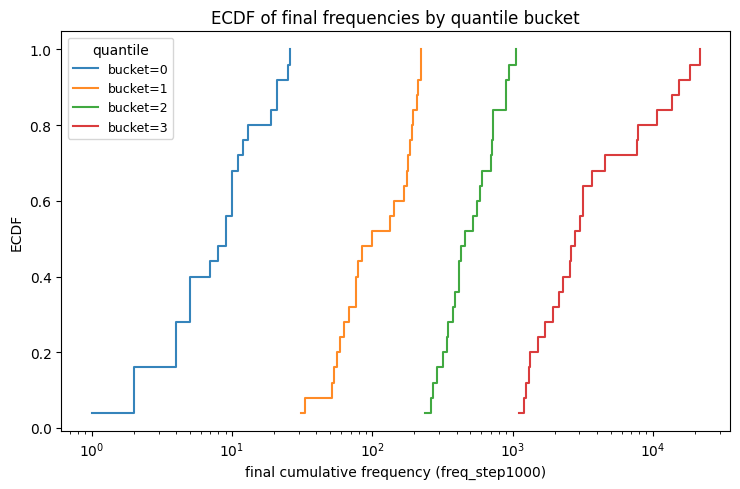

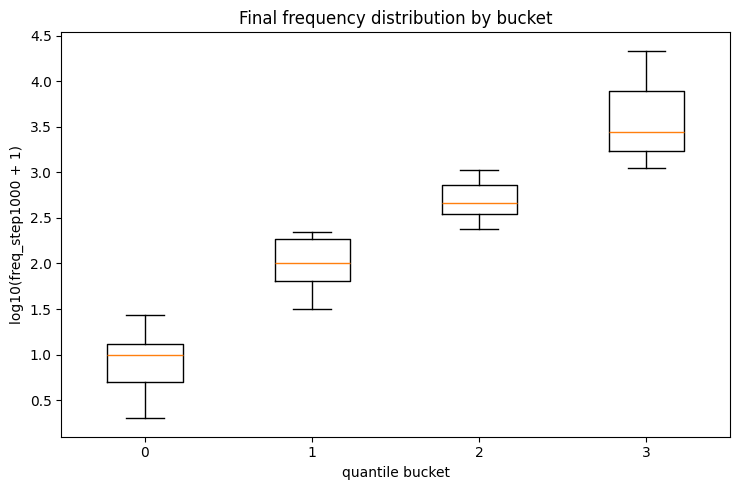

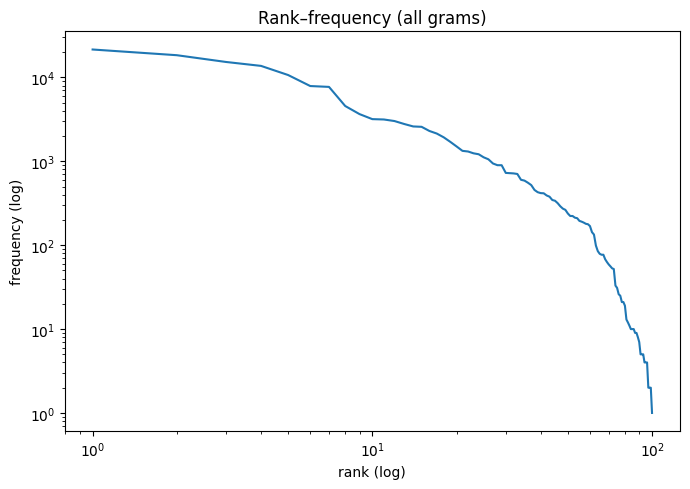

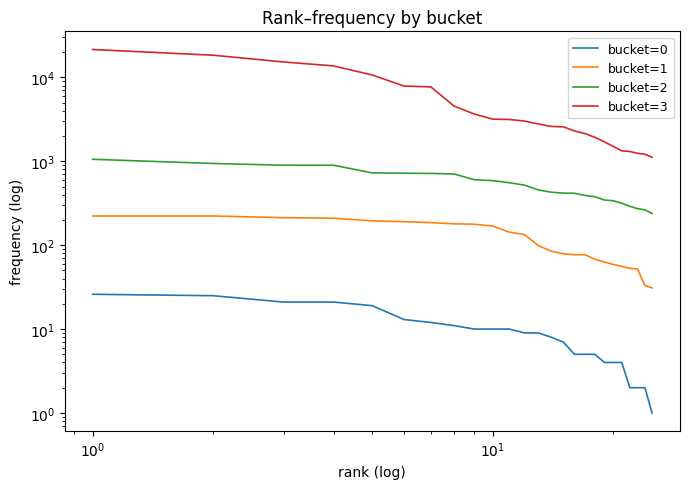

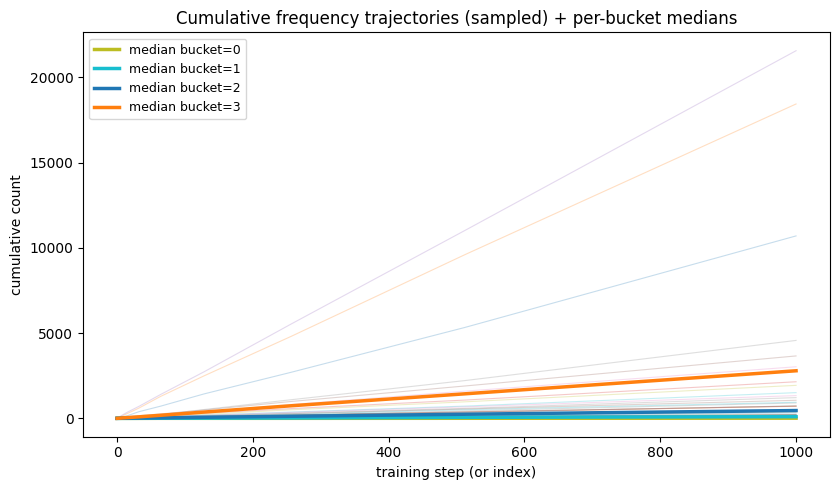

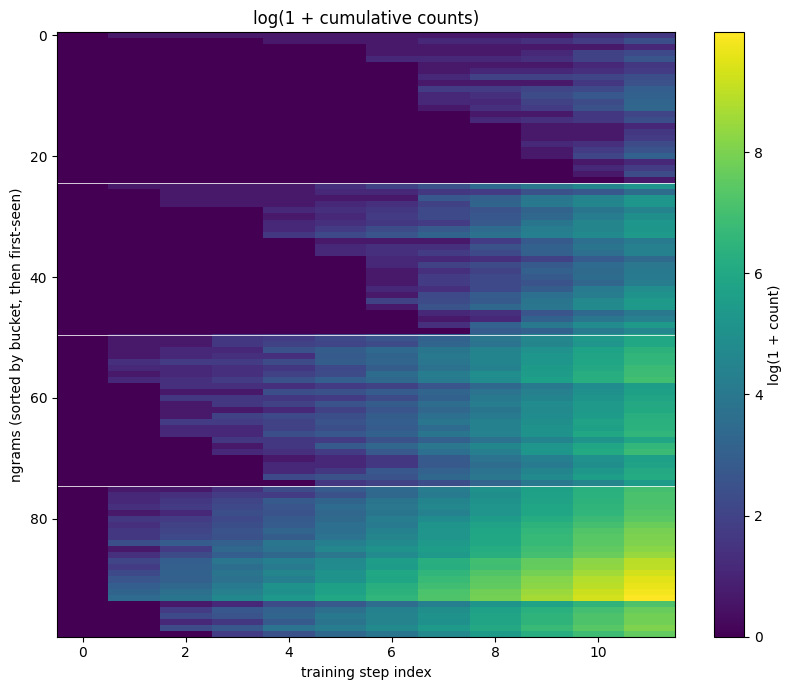

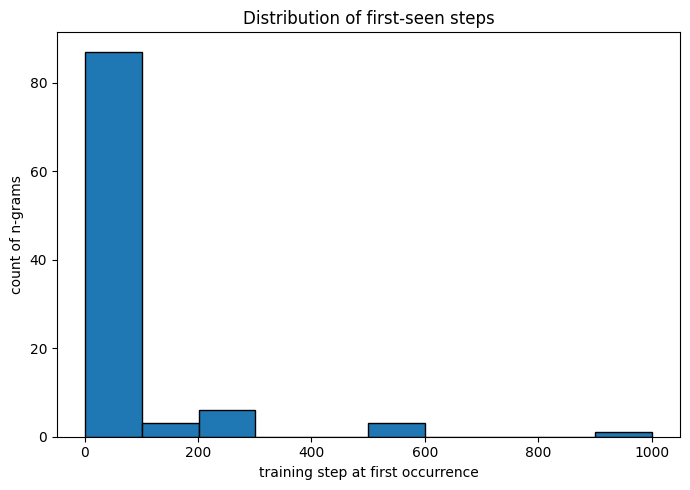

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------------
# 0) Load + prep
# ------------------------------------------------------------------------------------
# If df_candidates is already defined in your session, this block will just use it.
# Otherwise, set PARQUET_PATH to your saved file and it will be loaded.

PARQUET_PATH = "./exposure_artifacts/step1000/capital_relation_candidates.parquet"
OUT_DIR = Path("./exposure_artifacts/step1000/figs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    df = df_candidates.copy()
except NameError:
    df = pd.read_parquet(PARQUET_PATH)

# Ensure expected columns exist
req_cols = {"text", "ngram_ids", "len", "counts", "freq_step1000", "bucket"}
missing = req_cols - set(df.columns)
if missing:
    raise ValueError(f"df_candidates is missing columns: {missing}")

# Convert counts to a [G, T] array
C = np.asarray(df["counts"].tolist(), dtype=np.int64)  # cumulative counts
G, T = C.shape

# Steps array (x-axis). If you have EARLY_STEPS_12 in scope, use it; else fall back to 0..T-1
try:
    steps = np.asarray(EARLY_STEPS_12, dtype=int)
    assert steps.shape[0] == T
except Exception:
    steps = np.arange(T, dtype=int)

# First-seen index per gram (−1 if never)
mask = C > 0
first_seen_idx = np.where(mask.any(axis=1), mask.argmax(axis=1), -1)

# Make sure bucket is int and contiguous 0..Q-1
df["bucket"] = df["bucket"].astype(int)
bucket_ids = sorted(df["bucket"].dropna().unique().tolist())

# Utility: consistent figure saving
def _save(fig, name):
    p = OUT_DIR / name
    fig.tight_layout()
    fig.savefig(p, dpi=160, bbox_inches="tight")
    print(f"Saved {p}")

# ------------------------------------------------------------------------------------
# 1) ECDF + Boxplot of freq_step1000 by quantile bucket
# ------------------------------------------------------------------------------------
def plot_freq_distributions(df, logx=True):
    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    for b in bucket_ids:
        x = df.loc[df["bucket"] == b, "freq_step1000"].to_numpy(np.int64)
        if x.size == 0:
            continue
        x_sorted = np.sort(x)
        y = np.arange(1, x_sorted.size + 1) / x_sorted.size
        label = f"bucket={b}"
        ax.step(x_sorted, y, where="post", label=label, alpha=0.9)
    ax.set_xlabel("final cumulative frequency (freq_step1000)")
    ax.set_ylabel("ECDF")
    if logx:
        ax.set_xscale("log")
    ax.legend(title="quantile", fontsize=9)
    ax.set_title("ECDF of final frequencies by quantile bucket")
    _save(fig, "freq_ecdf_by_bucket.png")

    # Boxplot
    fig2, ax2 = plt.subplots(figsize=(7.5, 5.0))
    data = [df.loc[df["bucket"] == b, "freq_step1000"].to_numpy(np.int64) for b in bucket_ids]
    ax2.boxplot(data, labels=[str(b) for b in bucket_ids], showfliers=False)
    if logx:
        # Matplotlib boxplot doesn't support log-x directly; log-transform the data instead
        # For display only: add +1 to avoid log(0)
        data_log = [np.log10(d.astype(float) + 1.0) for d in data]
        ax2.clear()
        ax2.boxplot(data_log, labels=[str(b) for b in bucket_ids], showfliers=False)
        ax2.set_ylabel("log10(freq_step1000 + 1)")
    else:
        ax2.set_ylabel("freq_step1000")
    ax2.set_xlabel("quantile bucket")
    ax2.set_title("Final frequency distribution by bucket")
    _save(fig2, "freq_boxplot_by_bucket.png")

# ------------------------------------------------------------------------------------
# 2) Rank–frequency (Zipf-like) overall and by bucket
# ------------------------------------------------------------------------------------
def plot_rank_frequency(df):
    # Overall
    f = df["freq_step1000"].to_numpy(np.int64)
    f = f[f > 0]
    ranks = np.arange(1, f.size + 1)
    f_sorted = np.sort(f)[::-1]
    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    ax.plot(ranks, f_sorted, lw=1.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("rank (log)")
    ax.set_ylabel("frequency (log)")
    ax.set_title("Rank–frequency (all grams)")
    _save(fig, "rank_frequency_all.png")

    # By bucket
    fig2, ax2 = plt.subplots(figsize=(7.0, 5.0))
    for b in bucket_ids:
        fb = df.loc[df["bucket"] == b, "freq_step1000"].to_numpy(np.int64)
        fb = fb[fb > 0]
        if fb.size == 0:
            continue
        rb = np.arange(1, fb.size + 1)
        fb_sorted = np.sort(fb)[::-1]
        ax2.plot(rb, fb_sorted, lw=1.2, label=f"bucket={b}")
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel("rank (log)")
    ax2.set_ylabel("frequency (log)")
    ax2.set_title("Rank–frequency by bucket")
    ax2.legend(fontsize=9)
    _save(fig2, "rank_frequency_by_bucket.png")

# ------------------------------------------------------------------------------------
# 3) Trajectory (“spaghetti”) plots + per-bucket medians
# ------------------------------------------------------------------------------------
def plot_trajectories(C, steps, df, samples_per_bucket=12, alpha_lines=0.25):
    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    # Plot sampled trajectories
    for b in bucket_ids:
        idx = df.index[df["bucket"] == b].to_numpy()
        if idx.size == 0:
            continue
        if idx.size > samples_per_bucket:
            idx = rng.choice(idx, size=samples_per_bucket, replace=False)
        # lines
        for j in idx:
            ax.plot(steps, C[j], lw=0.8, alpha=alpha_lines)
    # Plot per-bucket median in bold
    for b in bucket_ids:
        idx = df.index[df["bucket"] == b].to_numpy()
        if idx.size == 0:
            continue
        med = np.median(C[idx], axis=0)
        ax.plot(steps, med, lw=2.5, label=f"median bucket={b}")
    ax.set_xlabel("training step (or index)")
    ax.set_ylabel("cumulative count")
    ax.set_title("Cumulative frequency trajectories (sampled) + per-bucket medians")
    ax.legend(fontsize=9)
    _save(fig, "trajectories_with_medians.png")

# ------------------------------------------------------------------------------------
# 4) Heatmap of log-counts (sorted by bucket, then first-seen)
# ------------------------------------------------------------------------------------
def plot_counts_heatmap(C, steps, df):
    # Sort rows: bucket asc, then first_seen_idx asc (−1 to the end)
    order = np.lexsort((
        np.where(first_seen_idx < 0, 10**9, first_seen_idx),
        df["bucket"].to_numpy()
    ))
    C_sorted = C[order]
    bucket_sorted = df["bucket"].to_numpy()[order]

    # Log transform for visibility
    H = np.log1p(C_sorted.astype(np.float64))

    fig, ax = plt.subplots(figsize=(8.5, 7.0))
    im = ax.imshow(H, aspect="auto", interpolation="nearest", origin="upper")
    ax.set_xlabel("training step index")
    ax.set_ylabel("ngrams (sorted by bucket, then first-seen)")
    ax.set_title("log(1 + cumulative counts)")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("log(1 + count)")
    # Bucket separators
    for b in np.unique(bucket_sorted):
        # draw a line above the first row of the next bucket
        rows_in_b = np.where(bucket_sorted == b)[0]
        last_row = rows_in_b[-1]
        ax.axhline(last_row + 0.5, color="white", lw=0.7, alpha=0.8)
    _save(fig, "counts_heatmap_log.png")

# ------------------------------------------------------------------------------------
# 5) First-seen histogram
# ------------------------------------------------------------------------------------
def plot_first_seen_histogram(first_seen_idx, steps):
    fs = first_seen_idx[first_seen_idx >= 0]
    if fs.size == 0:
        print("No first-seen events to plot.")
        return
    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    # Convert idx -> step values if steps are actual step numbers
    step_vals = steps[fs]
    ax.hist(step_vals, bins=min(20, max(5, int(np.sqrt(step_vals.size)))), edgecolor="black")
    ax.set_xlabel("training step at first occurrence")
    ax.set_ylabel("count of n-grams")
    ax.set_title("Distribution of first-seen steps")
    _save(fig, "first_seen_hist.png")

# ------------------------------------------------------------------------------------
# 6) Convenience: run all
# ------------------------------------------------------------------------------------
def render_all():
    plot_freq_distributions(df, logx=True)
    plot_rank_frequency(df)
    plot_trajectories(C, steps, df, samples_per_bucket=12)
    plot_counts_heatmap(C, steps, df)
    plot_first_seen_histogram(first_seen_idx, steps)

# Uncomment to run everything in one go:

render_all()

# Exposure Metric(s)

Compute and plot a series of basic exposure and frequency metrics at each checkpoints.

In [ ]:
from __future__ import annotations
from dataclasses import dataclass, asdict
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd

def recency_exposure(
    counts: np.ndarray,              # [G, T] cumulative >= 0
    cutoffs_tokens: np.ndarray,      # [T] token cutoffs
    *,
    half_life_tokens: float | None = None,
    steps: np.ndarray | None = None, # [T] step indices
    half_life_steps: float | None = None,
) -> np.ndarray:
    if (half_life_tokens is None) == (half_life_steps is None):
        raise ValueError("Specify exactly one of half_life_tokens or half_life_steps.")
    G, T = counts.shape
    if cutoffs_tokens.shape[0] != T:
        raise ValueError("cutoffs_tokens length must match counts' time dimension")

    # deltas >= 0 since counts are cumulative
    deltas = np.empty_like(counts, dtype=np.float64)
    deltas[:, 0] = counts[:, 0]
    if T > 1:
        deltas[:, 1:] = counts[:, 1:] - counts[:, :-1]

    rec = np.zeros((G, T), dtype=np.float64)

    if half_life_tokens is not None:
        gaps = np.empty(T, dtype=np.float64)
        gaps[0] = 0.0
        if T > 1:
            gaps[1:] = cutoffs_tokens[1:] - cutoffs_tokens[:-1]
        interval_decay = np.exp(-np.log(2.0) * (gaps / float(half_life_tokens)))
    else:
        if steps is None:
            raise ValueError("steps is required when using half_life_steps.")
        gaps = np.empty(T, dtype=np.float64)
        gaps[0] = 0.0
        if T > 1:
            gaps[1:] = steps[1:] - steps[:-1]
        interval_decay = np.exp(-np.log(2.0) * (gaps / float(half_life_steps)))

    rec[:, 0] = deltas[:, 0]
    for t in range(1, T):
        rec[:, t] = rec[:, t-1] * interval_decay[t] + deltas[:, t]
    return rec

def _safe_div(a: np.ndarray, b: np.ndarray | float) -> np.ndarray:
    return a / np.where(b == 0, 1.0, b)

def _first_seen_idx(counts: np.ndarray) -> np.ndarray:
    mask = counts > 0
    return np.where(mask.any(1), mask.argmax(1), -1)

def _deltas_from_counts(counts: np.ndarray) -> np.ndarray:
    G, T = counts.shape
    deltas = np.empty_like(counts, dtype=np.float64)
    deltas[:, 0] = counts[:, 0]
    if T > 1:
        deltas[:, 1:] = counts[:, 1:] - counts[:, :-1]
    return deltas

def _percentile_time_idx(counts: np.ndarray, pct: float) -> np.ndarray:
    """
    For each row, return smallest t with counts[t] >= pct * counts[-1].
    If final_count==0 -> -1.
    """
    final = counts[:, -1]
    targets = final * pct
    G, T = counts.shape
    out = np.full(G, -1, dtype=int)
    for g in range(G):
        if final[g] <= 0:
            continue
        t = np.searchsorted(counts[g], targets[g], side="left")
        if t < T:
            out[g] = t
    return out

def _entropy_normalized(deltas: np.ndarray) -> np.ndarray:
    # entropy over Δ distribution (per row), normalized by log(T_nonzero)
    G, T = deltas.shape
    out = np.zeros(G, dtype=np.float64)
    sums = deltas.sum(1)
    for g in range(G):
        s = sums[g]
        if s <= 0:
            out[g] = 0.0
            continue
        p = deltas[g] / s
        nz = p[p > 0]
        H = -np.sum(nz * np.log(nz))
        # normalize by log(#nonzero bins) to get 0..1
        k = nz.size
        out[g] = 0.0 if k <= 1 else (H / np.log(k))
    return out

def _gini(values: np.ndarray) -> np.ndarray:
    """
    Gini of Δ distribution per row (0=even, 1=all mass in one interval).
    """
    G, T = values.shape
    out = np.zeros(G, dtype=np.float64)
    for g in range(G):
        x = values[g]
        s = x.sum()
        if s <= 0:
            out[g] = 0.0
            continue
        # Sort ascending
        xs = np.sort(x)
        n = xs.size
        cum = np.cumsum(xs)
        # Gini via Lorenz curve: 1 - 2 * (sum_i cum_i)/(n * sum_x) + 1/n
        # Equivalent stable formula:
        # G = (n + 1 - 2 * (sum_{i} (n+1-i) * x_i)/sum_x) / n
        numer = (n + 1) - 2.0 * np.sum((n - np.arange(n)) * xs) / s
        out[g] = numer / n
        out[g] = max(0.0, min(1.0, out[g]))
    return out

def _ols_slope_r2(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    """
    OLS fit y = a + b x. Returns (a, b, r2) for a single pair (1D arrays).
    """
    x = x.astype(np.float64)
    y = y.astype(np.float64)
    n = x.size
    if n < 2:
        return (float(y.mean()) if n else 0.0, 0.0, 0.0)
    xm, ym = x.mean(), y.mean()
    xv = x - xm
    yv = y - ym
    denom = np.dot(xv, xv)
    if denom == 0.0:
        return (ym, 0.0, 0.0)
    b = np.dot(xv, yv) / denom
    a = ym - b * xm
    yhat = a + b * x
    ss_tot = np.dot(yv, yv)
    ss_res = np.dot(y - yhat, y - yhat)
    r2 = 0.0 if ss_tot == 0.0 else (1 - ss_res / ss_tot)
    return (a, b, r2)

In [ ]:
@dataclass
class ExposureConfig:
    # Files
    in_parquet: str = "./exposure_artifacts/step1000/capital_relation_candidates.parquet"
    out_parquet: str = "./exposure_artifacts/step1000/exposure_metrics.parquet"
    out_config_json: str = "./exposure_artifacts/step1000/exposure_metrics_config.json"
    # Decays (you can add more half-lives; first of each will be emitted as a full timeseries)
    token_half_lives: tuple[float, ...] = (5e8, 1e9)
    step_half_lives:  tuple[float, ...] = (64.0, 128.0)
    # Freshness windows (number of rightmost bins)
    freshness_windows: tuple[int, ...] = (1, 2, 4)
    # Numerical stability
    eps_log: float = 1.0

def build_exposure_metrics(
    cfg: ExposureConfig,
    *,
    cutoffs_tokens: np.ndarray,  # e.g., EARLY_CUTOFFS_12
    steps: np.ndarray,           # e.g., EARLY_STEPS_12
) -> pd.DataFrame:
    """
    Reads candidate counts parquet, computes exposure metrics, writes new parquet + JSON.
    Returns the resulting DataFrame.
    """
    cutoffs_tokens = np.asarray(cutoffs_tokens, dtype=np.int64)
    steps = np.asarray(steps, dtype=np.int64)

    df = pd.read_parquet(cfg.in_parquet)
    if "counts" not in df.columns:
        raise ValueError("Input parquet must contain a 'counts' column (list[int] per row).")

    # Shape: [G, T]
    counts = np.asarray(df["counts"].tolist(), dtype=np.int64)
    G, T = counts.shape
    if cutoffs_tokens.shape[0] != T or steps.shape[0] != T:
        raise ValueError(f"Expected cutoffs/steps length {T}; got {cutoffs_tokens.shape[0]} and {steps.shape[0]}.")

    deltas = _deltas_from_counts(counts)

    # ---- Base exposures (time series)
    exp_log = np.log(counts + cfg.eps_log)                              # [G, T]
    exp_rel = (counts / np.maximum(1, cutoffs_tokens)).astype(np.float64)

    # One canonical full-timeseries for tokens/steps decays (first half-life in each list)
    rec_tok_ts = recency_exposure(counts, cutoffs_tokens, half_life_tokens=cfg.token_half_lives[0])
    rec_stp_ts = recency_exposure(counts, cutoffs_tokens, steps=steps, half_life_steps=cfg.step_half_lives[0])

    # Additional decays -> store only final scalar (to save space)
    rec_tok_final = {}
    for hl in cfg.token_half_lives:
        r = recency_exposure(counts, cutoffs_tokens, half_life_tokens=hl)
        rec_tok_final[hl] = r[:, -1]  # [G]

    rec_stp_final = {}
    for hl in cfg.step_half_lives:
        r = recency_exposure(counts, cutoffs_tokens, steps=steps, half_life_steps=hl)
        rec_stp_final[hl] = r[:, -1]  # [G]

    # ---- First seen
    first_idx = _first_seen_idx(counts)
    first_seen_step = np.where(first_idx >= 0, steps[first_idx], -1)

    # ---- Scalars
    final_count = counts[:, -1].astype(np.int64)
    final_rel   = exp_rel[:, -1]

    # Freshness
    freshness = {}
    for k in cfg.freshness_windows:
        take = deltas[:, -k:].sum(1) if k <= T else deltas.sum(1)
        freshness[k] = _safe_div(take, final_count)  # fraction in last k bins

    # Median / quantile exposure times (in tokens + steps)
    p25_idx = _percentile_time_idx(counts, 0.25)
    p50_idx = _percentile_time_idx(counts, 0.50)
    p75_idx = _percentile_time_idx(counts, 0.75)
    def _idx_to_val(idx: np.ndarray, grid: np.ndarray) -> np.ndarray:
        return np.where(idx >= 0, grid[idx], -1)
    t25_tok = _idx_to_val(p25_idx, cutoffs_tokens)
    t50_tok = _idx_to_val(p50_idx, cutoffs_tokens)
    t75_tok = _idx_to_val(p75_idx, cutoffs_tokens)
    t25_stp = _idx_to_val(p25_idx, steps)
    t50_stp = _idx_to_val(p50_idx, steps)
    t75_stp = _idx_to_val(p75_idx, steps)

    # Entropy / Gini / Burstiness on Δ
    ent_norm = _entropy_normalized(deltas)
    gini = _gini(deltas)
    with np.errstate(divide="ignore", invalid="ignore"):
        mean_delta = np.where(final_count > 0, final_count / T, 0.0)
        burstiness = np.where(mean_delta > 0, deltas.max(1) / mean_delta, 0.0)

    # Slopes vs tokens/steps
    slopes_tok, r2_tok = np.zeros(G), np.zeros(G)
    slopes_stp, r2_stp = np.zeros(G), np.zeros(G)
    for g in range(G):
        _, b_tok, r_tok = _ols_slope_r2(cutoffs_tokens, counts[g])
        _, b_stp, r_stp = _ols_slope_r2(steps, counts[g])
        slopes_tok[g], r2_tok[g] = b_tok, r_tok
        slopes_stp[g], r2_stp[g] = b_stp, r_stp

    # ---- Build output rows (preserve useful original columns)
    out_rows = []
    for i in range(G):
        base = {
            "text": df.at[i, "text"] if "text" in df.columns else None,
            "ngram_ids": df.at[i, "ngram_ids"] if "ngram_ids" in df.columns else None,
            "len": int(df.at[i, "len"]) if "len" in df.columns else None,
            "bucket": int(df.at[i, "bucket"]) if "bucket" in df.columns else None,
            "freq_step1000": int(df.at[i, "freq_step1000"]) if "freq_step1000" in df.columns else int(final_count[i]),
            "counts": counts[i].tolist(),
            "deltas": deltas[i].tolist(),
            # time series exposures (canonical)
            "exp_log": exp_log[i].tolist(),
            "exp_rel": exp_rel[i].tolist(),
            "exp_rec_tok_hl_%.0e_ts" % cfg.token_half_lives[0]: rec_tok_ts[i].tolist(),
            "exp_rec_steps_hl_%.0e_ts" % cfg.step_half_lives[0]: rec_stp_ts[i].tolist(),
            # scalars
            "final_count": int(final_count[i]),
            "final_rel": float(final_rel[i]),
            "first_seen_idx": int(first_idx[i]),
            "first_seen_step": int(first_seen_step[i]),
            "fresh_last_%d" % cfg.freshness_windows[0]: float(freshness[cfg.freshness_windows[0]][i]),
            **{("fresh_last_%d" % k): float(freshness[k][i]) for k in cfg.freshness_windows},
            "p25_idx": int(p25_idx[i]), "p50_idx": int(p50_idx[i]), "p75_idx": int(p75_idx[i]),
            "p25_tokens": int(t25_tok[i]), "p50_tokens": int(t50_tok[i]), "p75_tokens": int(t75_tok[i]),
            "p25_step": int(t25_stp[i]), "p50_step": int(t50_stp[i]), "p75_step": int(t75_stp[i]),
            "entropy_norm": float(ent_norm[i]),
            "gini": float(gini[i]),
            "burstiness": float(burstiness[i]),
            "slope_tokens": float(slopes_tok[i]),
            "slope_steps": float(slopes_stp[i]),
            "r2_tokens": float(r2_tok[i]),
            "r2_steps": float(r2_stp[i]),
        }

        # Add final recency exposures for all configured half-lives
        for hl, vec in rec_tok_final.items():
            base["exp_rec_tok_hl_%.0e_final" % hl] = float(vec[i])
        for hl, vec in rec_stp_final.items():
            base["exp_rec_steps_hl_%.0e_final" % hl] = float(vec[i])

        out_rows.append(base)

    out_df = pd.DataFrame(out_rows)

    # Write outputs
    out_path = Path(cfg.out_parquet)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_df.to_parquet(out_path, index=False)

    # Save a tiny config/provenance sidecar
    sidecar = {
        "config": asdict(cfg),
        "shape": {"G": int(G), "T": int(T)},
        "cutoffs_head": [int(x) for x in cutoffs_tokens[:5]],
        "steps_head": [int(x) for x in steps[:5]],
    }
    with open(cfg.out_config_json, "w") as f:
        json.dump(sidecar, f, indent=2)

    print(f"Wrote metrics: {out_path}")
    print(f"Wrote config:  {cfg.out_config_json}")
    return out_df

In [ ]:
cfg = ExposureConfig(
    in_parquet="./exposure_artifacts/step1000/capital_relation_candidates.parquet",
    out_parquet="./exposure_artifacts/step1000/exposure_metrics.parquet",
    out_config_json="./exposure_artifacts/step1000/exposure_metrics_config.json",
    token_half_lives=(5e8, 1e9),
    step_half_lives=(64.0, 128.0),
    freshness_windows=(1, 2, 4),
)
df_metrics = build_exposure_metrics(cfg, cutoffs_tokens=EARLY_CUTOFFS_12, steps=EARLY_STEPS_12)
print(df_metrics.head(100))

Wrote metrics: exposure_artifacts/step1000/exposure_metrics.parquet
Wrote config:  ./exposure_artifacts/step1000/exposure_metrics_config.json
                    text           ngram_ids  len  bucket  freq_step1000  \
0     capital of Ecuador  [5347, 273, 40145]    3       0              1   
1      capital of Taiwan  [5347, 273, 17975]    3       0              2   
2                 Yaren,     [714, 6950, 13]    3       0              2   
3     capital of Lebanon  [5347, 273, 28746]    3       0              2   
4    capital of Malaysia  [5347, 273, 23799]    3       0              4   
..                   ...                 ...  ...     ...            ...   
95                Paris,          [7785, 13]    2       3          10696   
96               Beijing             [18496]    1       3          13748   
97              Victoria             [16225]    1       3          15306   
98         in Washington         [275, 5041]    2       3          18432   
99             in Lond

Saved exposure_artifacts/step1000/figs_exposure/final_count_hist_loglog.png
Saved exposure_artifacts/step1000/figs_exposure/final_rel_hist.png
Saved exposure_artifacts/step1000/figs_exposure/first_seen_hist.png
Saved exposure_artifacts/step1000/figs_exposure/first_seen_ecdf.png


/tmp/ipython-input-2519572062.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace("fresh_last_", "k=") for c in cols_sorted], showfliers=False)


Saved exposure_artifacts/step1000/figs_exposure/freshness_boxplots.png
Saved exposure_artifacts/step1000/figs_exposure/entropy_vs_gini_scatter.png
Saved exposure_artifacts/step1000/figs_exposure/entropy_vs_gini_hexbin_weighted.png
Saved exposure_artifacts/step1000/figs_exposure/burstiness_hist.png
Saved exposure_artifacts/step1000/figs_exposure/slope_vs_r2_tokens.png
Saved exposure_artifacts/step1000/figs_exposure/slope_vs_r2_steps.png
Saved exposure_artifacts/step1000/figs_exposure/p50_vs_final_count.png
Saved exposure_artifacts/step1000/figs_exposure/exp_rel_medians_by_bucket.png
Saved exposure_artifacts/step1000/figs_exposure/recency_ts_sampled_tok.png
Saved exposure_artifacts/step1000/figs_exposure/recency_ts_sampled_stp.png
Saved exposure_artifacts/step1000/figs_exposure/recency_final_vs_final_count_grid.png
Saved exposure_artifacts/step1000/figs_exposure/delta_heatmap_sorted.png


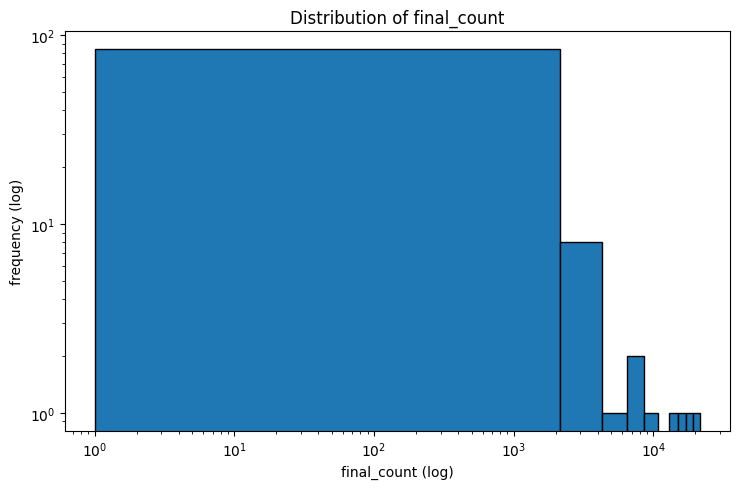

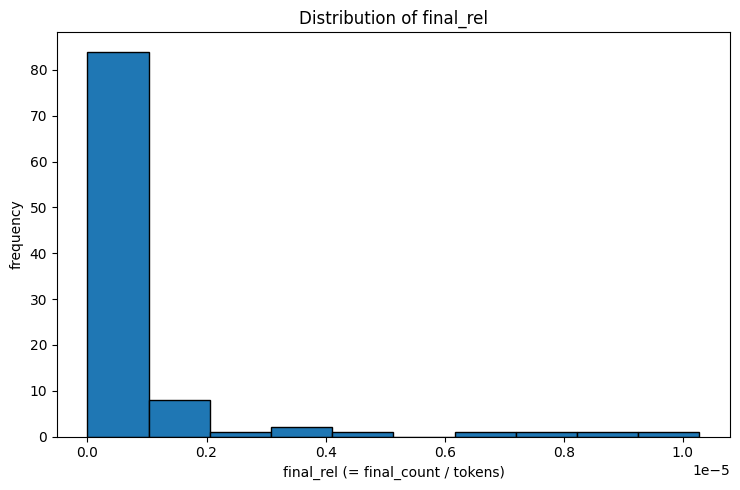

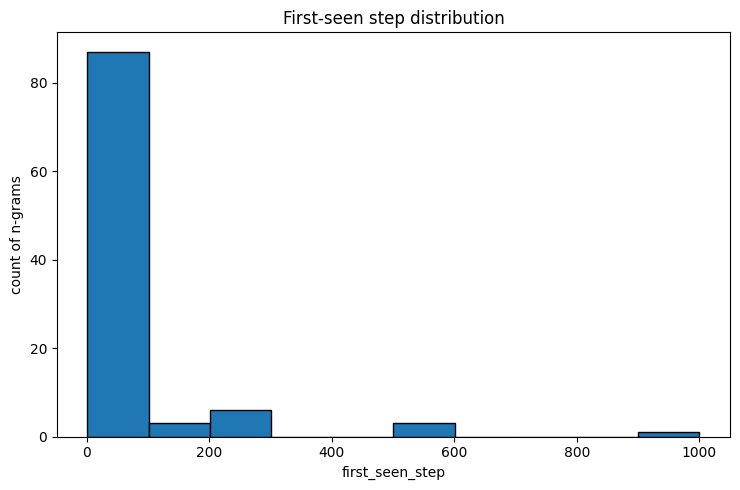

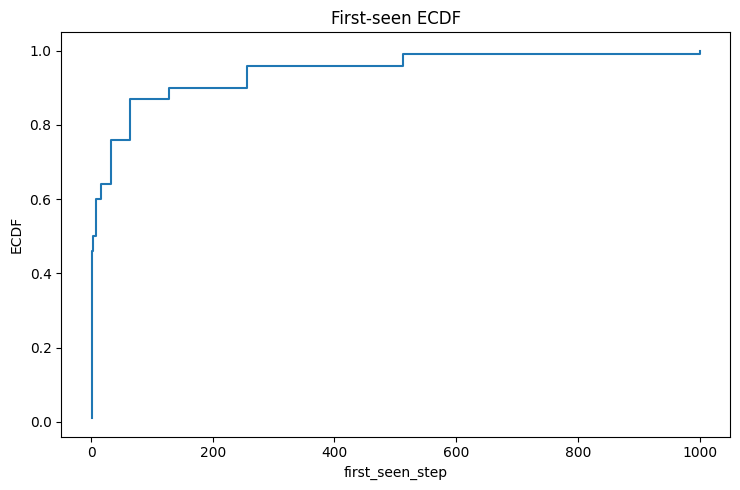

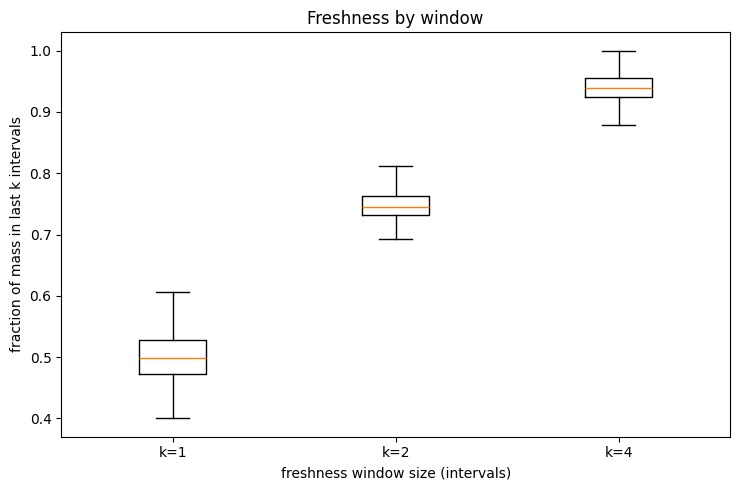

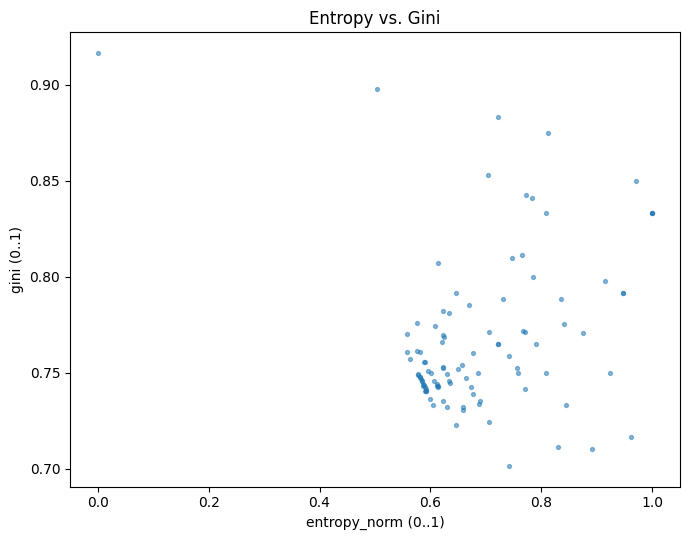

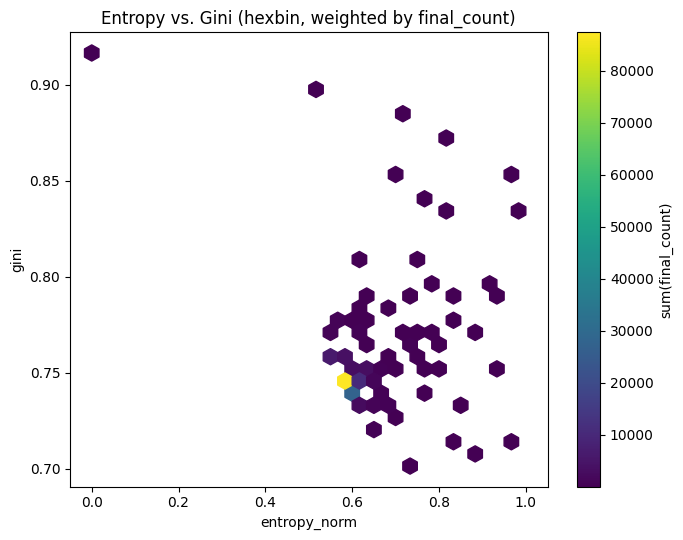

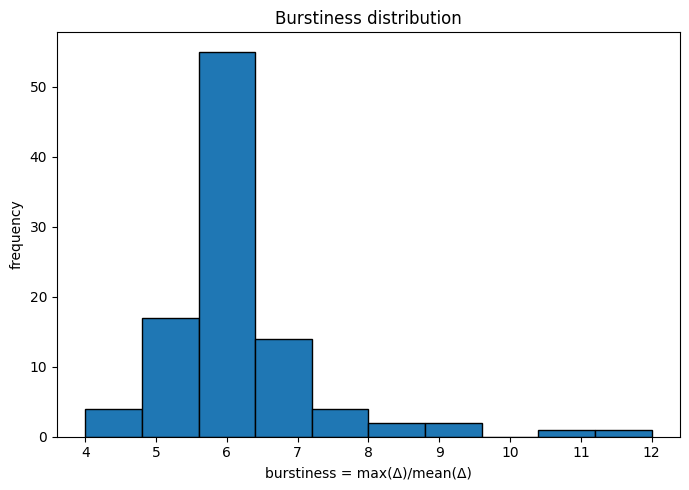

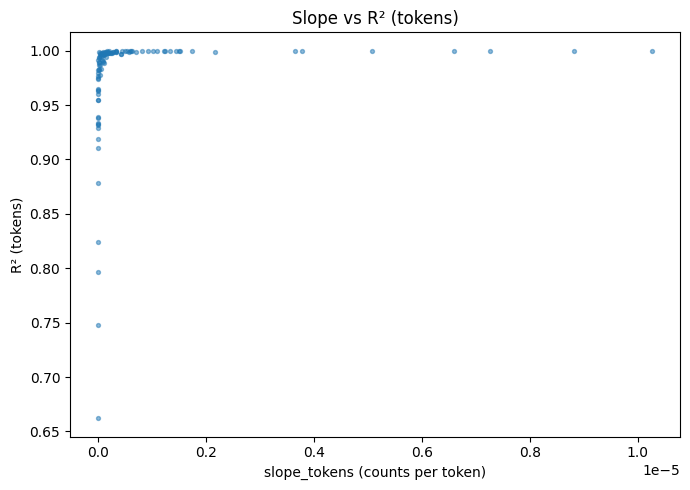

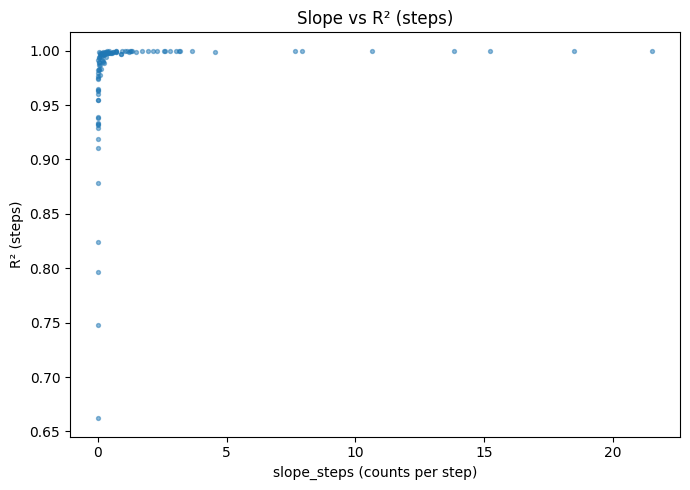

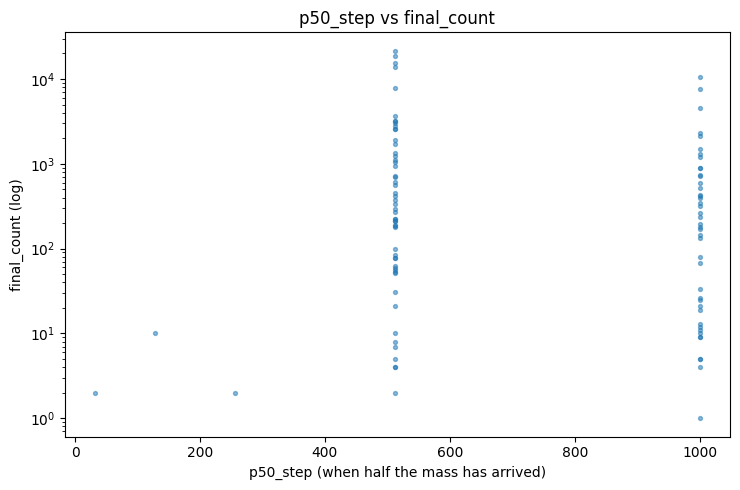

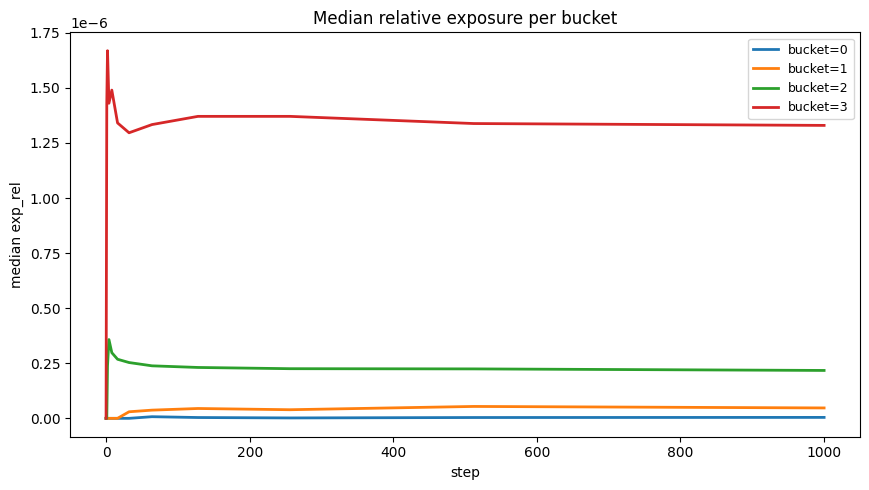

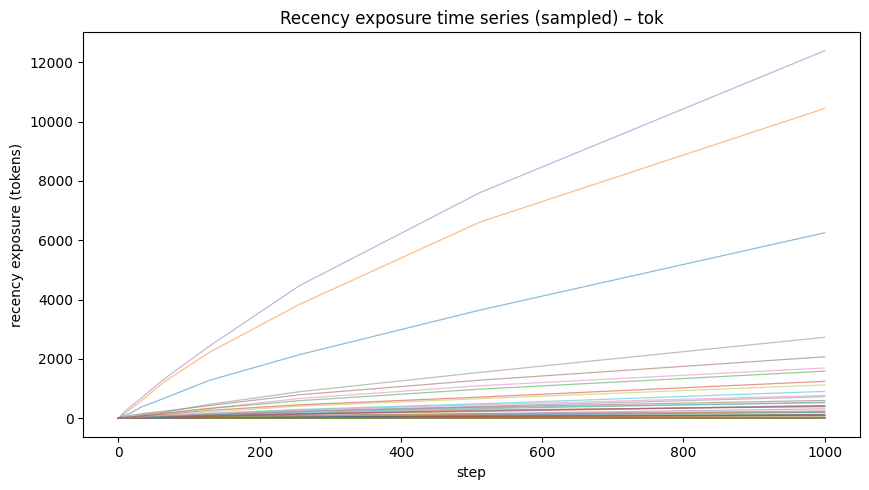

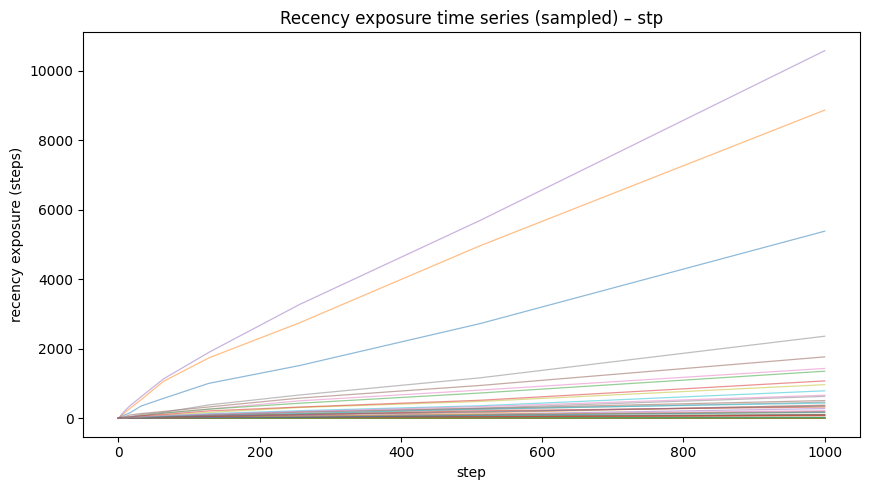

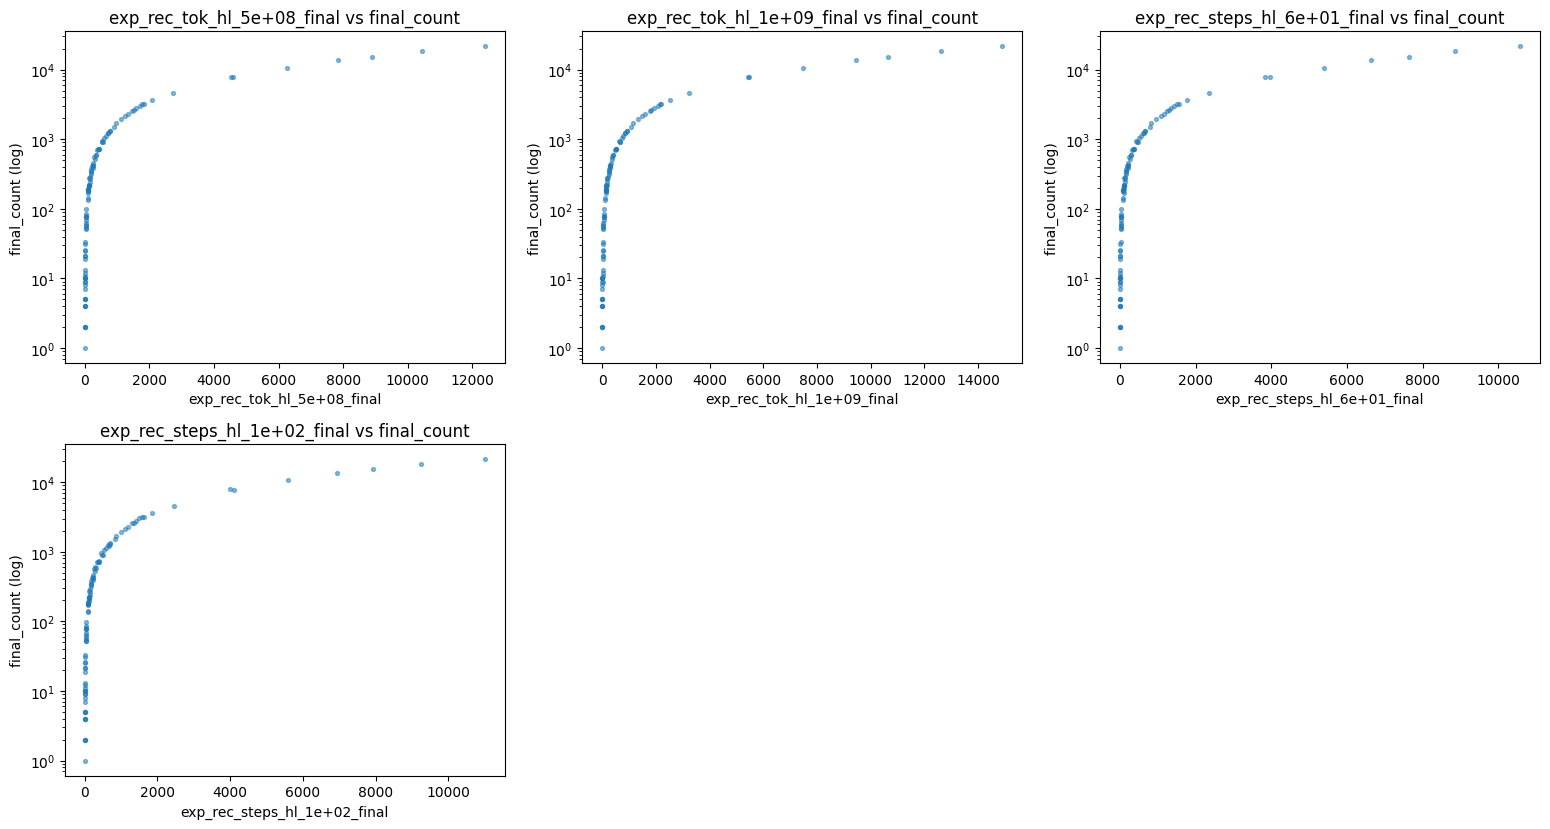

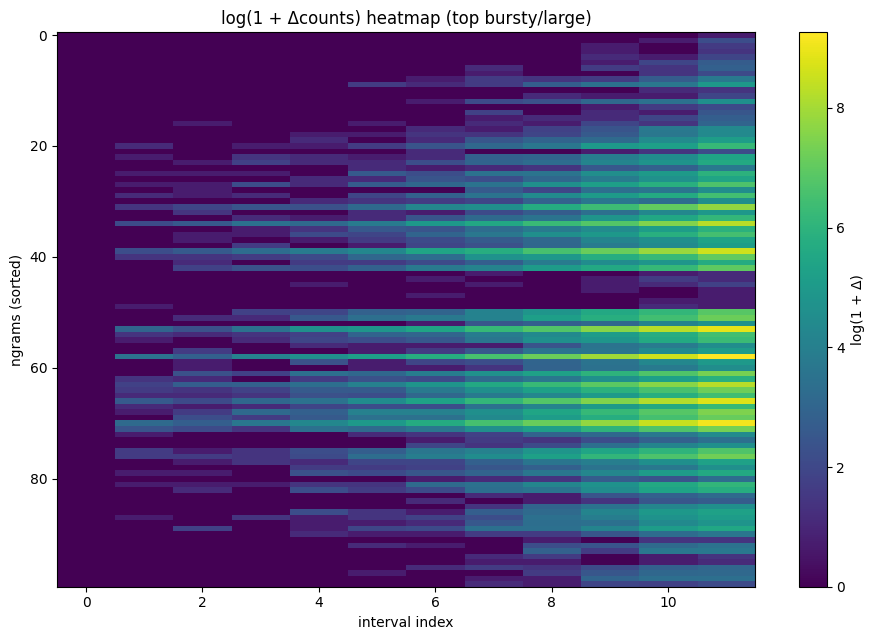

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# ------------------------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------------------------
IN_PARQUET = "./exposure_artifacts/step1000/exposure_metrics.parquet"
OUT_DIR = Path("./exposure_artifacts/step1000/figs_exposure")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: read sidecar for provenance (if you wrote it)
SIDE_CAR = "./exposure_artifacts/step1000/exposure_metrics_config.json"
sidecar = None
try:
    with open(SIDE_CAR, "r") as f:
        sidecar = json.load(f)
except Exception:
    pass

# ------------------------------------------------------------------------------------
# Load
# ------------------------------------------------------------------------------------
df = pd.read_parquet(IN_PARQUET)

# Core arrays
counts = np.asarray(df["counts"].tolist(), dtype=np.int64)            # [G, T]
deltas = np.asarray(df["deltas"].tolist(), dtype=np.float64)          # [G, T]
G, T = counts.shape

# Time axis
try:
    steps = np.asarray(EARLY_STEPS_12, dtype=int)  # if available in your session
    assert steps.shape[0] == T
except Exception:
    steps = np.arange(T, dtype=int)

# Buckets (optional)
buckets = None
if "bucket" in df.columns:
    df["bucket"] = df["bucket"].astype(int)
    buckets = sorted(df["bucket"].dropna().unique().tolist())

# Helpers
def _save(fig, name):
    p = OUT_DIR / name
    fig.tight_layout()
    fig.savefig(p, dpi=160, bbox_inches="tight")
    print(f"Saved {p}")

def _colnames(prefix):
    return [c for c in df.columns if c.startswith(prefix)]

def _try_series_col(prefix_regex):
    """Return first column matching regex (useful for the canonical recency time series)."""
    pat = re.compile(prefix_regex)
    for c in df.columns:
        if pat.match(c):
            return c
    return None

# Detect recency columns
REC_TOK_TS_COL = _try_series_col(r"^exp_rec_tok_hl_.*_ts$")
REC_STP_TS_COL = _try_series_col(r"^exp_rec_steps_hl_.*_ts$")
REC_TOK_FINAL_COLS = [c for c in df.columns if re.match(r"^exp_rec_tok_hl_.*_final$", c)]
REC_STP_FINAL_COLS = [c for c in df.columns if re.match(r"^exp_rec_steps_hl_.*_final$", c)]

# ------------------------------------------------------------------------------------
# 1) Final count / relative exposure distributions
# ------------------------------------------------------------------------------------
def plot_final_distributions():
    # Final count
    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    x = df["final_count"].to_numpy(np.int64)
    x = x[x >= 0]
    ax.hist(x, bins=min(50, max(10, int(np.sqrt(x.size)))), edgecolor="black")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlabel("final_count (log)")
    ax.set_ylabel("frequency (log)")
    ax.set_title("Distribution of final_count")
    _save(fig, "final_count_hist_loglog.png")

    # Final relative
    if "final_rel" in df.columns:
        fig2, ax2 = plt.subplots(figsize=(7.5, 5.0))
        r = df["final_rel"].to_numpy(float)
        ax2.hist(r, bins=min(50, max(10, int(np.sqrt(r.size)))), edgecolor="black")
        ax2.set_xlabel("final_rel (= final_count / tokens)")
        ax2.set_ylabel("frequency")
        ax2.set_title("Distribution of final_rel")
        _save(fig2, "final_rel_hist.png")

# ------------------------------------------------------------------------------------
# 2) First-seen step hist + ECDF
# ------------------------------------------------------------------------------------
def plot_first_seen():
    if "first_seen_step" not in df.columns:
        print("No first_seen_step column.")
        return
    fs = df["first_seen_step"].to_numpy(int)
    fs = fs[fs >= 0]
    if fs.size == 0:
        print("No nonnegative first_seen_step values to plot.")
        return
    # Histogram
    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.hist(fs, bins=min(30, max(10, int(np.sqrt(fs.size)))), edgecolor="black")
    ax.set_xlabel("first_seen_step")
    ax.set_ylabel("count of n-grams")
    ax.set_title("First-seen step distribution")
    _save(fig, "first_seen_hist.png")

    # ECDF
    fig2, ax2 = plt.subplots(figsize=(7.5, 5.0))
    s = np.sort(fs)
    y = np.arange(1, s.size + 1) / s.size
    ax2.step(s, y, where="post")
    ax2.set_xlabel("first_seen_step")
    ax2.set_ylabel("ECDF")
    ax2.set_title("First-seen ECDF")
    _save(fig2, "first_seen_ecdf.png")

# ------------------------------------------------------------------------------------
# 3) Freshness boxplots for all configured windows
# ------------------------------------------------------------------------------------
def plot_freshness_boxplots():
    cols = _colnames("fresh_last_")
    if not cols:
        print("No freshness columns (fresh_last_*) found.")
        return
    cols_sorted = sorted(cols, key=lambda c: int(c.split("_")[-1]))
    data = [df[c].to_numpy(float) for c in cols_sorted]

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.boxplot(data, labels=[c.replace("fresh_last_", "k=") for c in cols_sorted], showfliers=False)
    ax.set_xlabel("freshness window size (intervals)")
    ax.set_ylabel("fraction of mass in last k intervals")
    ax.set_title("Freshness by window")
    _save(fig, "freshness_boxplots.png")

# ------------------------------------------------------------------------------------
# 4) Entropy vs Gini scatter (+ hexbin weighted by final_count)
# ------------------------------------------------------------------------------------
def plot_entropy_gini():
    if "entropy_norm" not in df.columns or "gini" not in df.columns:
        print("Missing entropy_norm or gini.")
        return
    x = df["entropy_norm"].to_numpy(float)
    y = df["gini"].to_numpy(float)

    fig, ax = plt.subplots(figsize=(7.0, 5.5))
    ax.scatter(x, y, s=8, alpha=0.5)
    ax.set_xlabel("entropy_norm (0..1)")
    ax.set_ylabel("gini (0..1)")
    ax.set_title("Entropy vs. Gini")
    _save(fig, "entropy_vs_gini_scatter.png")

    # Hexbin, sized by count
    w = df["final_count"].to_numpy(float) if "final_count" in df.columns else np.ones_like(x)
    fig2, ax2 = plt.subplots(figsize=(7.0, 5.5))
    hb = ax2.hexbin(x, y, C=w, reduce_C_function=np.sum, gridsize=30)
    ax2.set_xlabel("entropy_norm")
    ax2.set_ylabel("gini")
    ax2.set_title("Entropy vs. Gini (hexbin, weighted by final_count)")
    cb = fig2.colorbar(hb, ax=ax2)
    cb.set_label("sum(final_count)")
    _save(fig2, "entropy_vs_gini_hexbin_weighted.png")

# ------------------------------------------------------------------------------------
# 5) Burstiness and slope diagnostics
# ------------------------------------------------------------------------------------
def plot_burstiness_and_slopes():
    # Burstiness
    if "burstiness" in df.columns:
        fig, ax = plt.subplots(figsize=(7.0, 5.0))
        b = df["burstiness"].to_numpy(float)
        ax.hist(b, bins=min(50, max(10, int(np.sqrt(b.size)))), edgecolor="black")
        ax.set_xlabel("burstiness = max(Δ)/mean(Δ)")
        ax.set_ylabel("frequency")
        ax.set_title("Burstiness distribution")
        _save(fig, "burstiness_hist.png")

    # Slopes vs tokens/steps
    if "slope_tokens" in df.columns and "r2_tokens" in df.columns:
        fig2, ax2 = plt.subplots(figsize=(7.0, 5.0))
        ax2.scatter(df["slope_tokens"], df["r2_tokens"], s=8, alpha=0.5)
        ax2.set_xlabel("slope_tokens (counts per token)")
        ax2.set_ylabel("R² (tokens)")
        ax2.set_title("Slope vs R² (tokens)")
        _save(fig2, "slope_vs_r2_tokens.png")

    if "slope_steps" in df.columns and "r2_steps" in df.columns:
        fig3, ax3 = plt.subplots(figsize=(7.0, 5.0))
        ax3.scatter(df["slope_steps"], df["r2_steps"], s=8, alpha=0.5)
        ax3.set_xlabel("slope_steps (counts per step)")
        ax3.set_ylabel("R² (steps)")
        ax3.set_title("Slope vs R² (steps)")
        _save(fig3, "slope_vs_r2_steps.png")

# ------------------------------------------------------------------------------------
# 6) Median time (p50) vs final_count; and per-bucket medians of exp_rel
# ------------------------------------------------------------------------------------
def plot_p50_vs_final_count():
    cols_needed = {"p50_step", "final_count"}
    if not cols_needed.issubset(df.columns):
        print("Missing p50_step or final_count.")
        return
    x = df["p50_step"].to_numpy(int)
    y = df["final_count"].to_numpy(np.int64)

    mask = (x >= 0) & (y > 0)
    x, y = x[mask], y[mask]

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.scatter(x, y, s=8, alpha=0.5)
    ax.set_yscale("log")
    ax.set_xlabel("p50_step (when half the mass has arrived)")
    ax.set_ylabel("final_count (log)")
    ax.set_title("p50_step vs final_count")
    _save(fig, "p50_vs_final_count.png")

def plot_exp_rel_medians_by_bucket():
    col = "exp_rel"
    if col not in df.columns:
        print("No exp_rel time series.")
        return
    if buckets is None:
        print("No 'bucket' column—skipping per-bucket medians.")
        return
    rel = np.asarray(df[col].tolist(), dtype=float)  # [G, T]
    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    for b in buckets:
        idx = df.index[df["bucket"] == b].to_numpy()
        if idx.size == 0:
            continue
        med = np.median(rel[idx], axis=0)
        ax.plot(steps, med, lw=2.0, label=f"bucket={b}")
    ax.set_xlabel("step")
    ax.set_ylabel("median exp_rel")
    ax.set_title("Median relative exposure per bucket")
    ax.legend(fontsize=9)
    _save(fig, "exp_rel_medians_by_bucket.png")

# ------------------------------------------------------------------------------------
# 7) Recency time series (sampled) and correlation vs final_count
# ------------------------------------------------------------------------------------
def plot_recency_timeseries_samples(samples_per_bucket=10, which="tok"):
    """
    which: "tok" for token-decay series, "stp" for step-decay series
    """
    col = REC_TOK_TS_COL if which == "tok" else REC_STP_TS_COL
    if col is None:
        print(f"No recency time series column for '{which}'.")
        return
    R = np.asarray(df[col].tolist(), dtype=float)  # [G, T]

    # Sample lines
    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    rng = np.random.default_rng(0)
    if buckets is None:
        idx = np.arange(min(G, samples_per_bucket))
        for j in idx:
            ax.plot(steps, R[j], lw=0.9, alpha=0.5)
    else:
        for b in buckets:
            bi = df.index[df["bucket"] == b].to_numpy()
            if bi.size == 0:
                continue
            take = bi if bi.size <= samples_per_bucket else rng.choice(bi, size=samples_per_bucket, replace=False)
            for j in take:
                ax.plot(steps, R[j], lw=0.9, alpha=0.5)
    ax.set_xlabel("step")
    ax.set_ylabel(f"recency exposure ({'tokens' if which=='tok' else 'steps'})")
    ax.set_title(f"Recency exposure time series (sampled) – {which}")
    _save(fig, f"recency_ts_sampled_{which}.png")

def plot_recency_final_vs_final_count():
    cols = REC_TOK_FINAL_COLS + REC_STP_FINAL_COLS
    if not cols or "final_count" not in df.columns:
        print("Missing recency final or final_count.")
        return
    m = len(cols)
    ncols = 3
    nrows = int(np.ceil(m / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.2*ncols, 4.2*nrows))
    axes = np.array(axes).reshape(-1)
    y = df["final_count"].to_numpy(np.int64)
    y = y[y > 0]
    for i, c in enumerate(cols):
        x = df[c].to_numpy(float)
        xi = x[:y.size] if x.size != y.size else x
        ax = axes[i]
        ax.scatter(xi, y[:xi.size], s=8, alpha=0.5)
        ax.set_yscale("log")
        ax.set_xlabel(c)
        ax.set_ylabel("final_count (log)")
        ax.set_title(f"{c} vs final_count")
    # turn off any unused axes
    for j in range(m, axes.size):
        axes[j].axis("off")
    _save(fig, "recency_final_vs_final_count_grid.png")

# ------------------------------------------------------------------------------------
# 8) Delta heatmap (optional; good for eyeballing burstiness)
# ------------------------------------------------------------------------------------
def plot_delta_heatmap_sorted(limit=500):
    # Sort rows by burstiness descending if present; else by final_count
    order = None
    if "burstiness" in df.columns:
        order = np.argsort(-df["burstiness"].to_numpy(float))
    else:
        order = np.argsort(-df["final_count"].to_numpy(np.int64))
    order = order[:min(limit, G)]
    D = deltas[order]
    H = np.log1p(D)
    fig, ax = plt.subplots(figsize=(9.5, 6.5))
    im = ax.imshow(H, aspect="auto", interpolation="nearest", origin="upper")
    ax.set_xlabel("interval index")
    ax.set_ylabel("ngrams (sorted)")
    ax.set_title("log(1 + Δcounts) heatmap (top bursty/large)")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("log(1 + Δ)")
    _save(fig, "delta_heatmap_sorted.png")

# ------------------------------------------------------------------------------------
# 9) Convenience: run a sensible default dashboard
# ------------------------------------------------------------------------------------
def render_all_exposure_figs():
    plot_final_distributions()
    plot_first_seen()
    plot_freshness_boxplots()
    plot_entropy_gini()
    plot_burstiness_and_slopes()
    plot_p50_vs_final_count()
    plot_exp_rel_medians_by_bucket()
    plot_recency_timeseries_samples(samples_per_bucket=12, which="tok")
    plot_recency_timeseries_samples(samples_per_bucket=12, which="stp")
    plot_recency_final_vs_final_count()
    plot_delta_heatmap_sorted(limit=400)

# Uncomment to run everything:
render_all_exposure_figs()

# N-Grams Lift Metric(s)

Find candidate neurons and provide a series of metrics on the activations of the neurons to specific tokens.

In [ ]:
# =========================== robust_lift_with_entropy.py ===========================
from __future__ import annotations
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import numpy as np
import pandas as pd
import torch
from nnsight import LanguageModel

# ------------------------------ Sampling utils ------------------------------

def sample_positions_for_ngram(
    ng_ids: Tuple[int, ...],
    *,
    max_samples: int = 64,
    cutoff_tokens: Optional[int] = None,
) -> np.ndarray:
    """Sorted start positions of the n-gram, optionally filtered to end <= cutoff."""
    pos = tg.positions(ng_ids)
    if pos.size == 0:
        return pos
    if cutoff_tokens is not None:
        pos = pos[(pos + len(ng_ids)) <= cutoff_tokens]
        if pos.size == 0:
            return pos
    if pos.size <= max_samples:
        return pos
    idx = np.linspace(0, pos.size - 1, num=max_samples, dtype=int)
    return pos[idx]

def make_windows_from_positions(
    positions: np.ndarray,
    ng_len: int,
    *,
    seq_len: int = 256,
    anchor_pos: int = 192,   # end token of gram sits here
    prefix_bin: Path = None,
    dtype=None,
) -> list[list[int]]:
    """Slice token windows so that gram end token falls at anchor_pos."""
    if positions.size == 0:
        return []
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total = arr.shape[0]
    out: list[list[int]] = []
    for start in positions:
        end = start + ng_len - 1
        win_start = end - anchor_pos
        win_start = max(0, min(int(win_start), total - seq_len))
        out.append(arr[win_start:win_start+seq_len].tolist())
    del arr
    return out

def decode_windows(token_windows: list[list[int]]) -> list[str]:
    return [tok.decode(w) for w in token_windows]

# -------------------------- Interval/anchor utilities -----------------------

def end_interval_indices(end_positions: np.ndarray, cutoffs_tokens: np.ndarray) -> np.ndarray:
    """
    Map each end position to its training interval index t in [0..T-1].
    We treat cutoffs as cumulative token counts at the END of each interval.
    """
    return np.searchsorted(cutoffs_tokens, end_positions, side="right") - 1

def random_windows_matched_by_intervals(
    counts_per_interval: np.ndarray,
    *,
    seq_len: int,
    anchor_pos: int,
    cutoffs_tokens: np.ndarray,
    prefix_bin: Path,
    dtype,
    avoid_gram: Optional[Tuple[int, ...]] = None,
    max_resample_per_interval: int = 10,
    rng: Optional[np.random.Generator] = None,
) -> list[list[int]]:
    """
    Sample baseline windows that (1) respect the prefix cutoff for each interval and
    (2) match the interval counts provided (one window per requested count per interval).
    Anchor at `anchor_pos`. Optionally filter out windows whose anchor ends with `avoid_gram`.
    """
    rng = rng or np.random.default_rng(0)
    T = len(cutoffs_tokens)
    lo = np.r_[0, cutoffs_tokens[:-1]]
    hi = cutoffs_tokens
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total = arr.shape[0]
    out: list[list[int]] = []

    for t, k in enumerate(counts_per_interval.tolist()):
        if k <= 0:
            continue
        lo_t, hi_t = int(lo[t]), int(hi[t])
        if hi_t <= lo_t:
            continue
        for _ in range(int(k)):
            ok = False
            tries = 0
            while not ok and tries < max_resample_per_interval:
                end_pos = rng.integers(lo_t, hi_t)
                win_start = end_pos - anchor_pos
                win_start = max(0, min(int(win_start), total - seq_len))
                w = arr[win_start:win_start+seq_len].tolist()
                if avoid_gram is not None:
                    # filter out accidental matches where gram ends at anchor
                    ids = tok.encode(tok.decode(w))
                    a = min(anchor_pos, len(ids)-1)
                    g = list(avoid_gram)
                    if a - len(g) + 1 >= 0 and ids[a-len(g)+1:a+1] == g:
                        tries += 1
                        continue
                out.append(w)
                ok = True
    del arr
    return out

# ------------------------------ Capture utils -------------------------------

def capture_postacts_fixed_anchor(
    lm: LanguageModel,
    texts: list[str],
    layers: list[int],
    *,
    anchor_pos: int,
    batch_size: int = 32,
) -> Dict[int, np.ndarray]:
    """Return {layer: [N, D]} at a fixed anchor_pos inside each text."""
    if len(texts) == 0:
        return {L: np.zeros((0,1), dtype=np.float32) for L in layers}

    def run_batch(bt: list[str]):
        with lm.trace(bt) as tr:
            caps = [lm.gpt_neox.layers[L].mlp.dense_4h_to_h.input.save() for L in layers]
            _ = lm.output.save()
        return [c.value[:, anchor_pos, :].to("cpu").float().detach().numpy() for c in caps]

    acc = {L: [] for L in layers}
    for i in range(0, len(texts), batch_size):
        bt = texts[i:i+batch_size]
        arrs = run_batch(bt)
        for L, a in zip(layers, arrs): acc[L].append(a)
    return {L: (np.concatenate(v, 0) if v else np.zeros((0,1), np.float32)) for L, v in acc.items()}

# ------------------------------ Effect sizes --------------------------------

def compute_effects(
    gram: Dict[int, np.ndarray],
    base: Dict[int, np.ndarray],
) -> Dict[int, Dict[str, np.ndarray]]:
    """
    For each layer, compute μ, σ, and multiple effect sizes.
    Returns per-layer dict with:
      - mu_gram, mu_base, sd_gram, sd_base
      - lift_raw, lift_z (Glass Δ), lift_d (Cohen’s d)
    """
    out: Dict[int, Dict[str, np.ndarray]] = {}
    for L in gram.keys():
        G = gram[L]; B = base[L]
        if G.shape[0] == 0 or B.shape[0] == 0:
            out[L] = dict(
                mu_gram=None, mu_base=None, sd_gram=None, sd_base=None,
                lift_raw=None, lift_z=None, lift_d=None,
                n_gram=G.shape[0], n_base=B.shape[0]
            )
            continue
        mu_g = G.mean(0); mu_b = B.mean(0)
        sd_g = G.std(0, ddof=1); sd_b = B.std(0, ddof=1)
        lift = mu_g - mu_b
        # Glass delta: standardize by baseline sd
        z = lift / (sd_b + 1e-6)
        # Cohen's d (pooled)
        sd_p = np.sqrt((sd_b**2 + sd_g**2) / 2.0)
        d = lift / (sd_p + 1e-6)

        out[L] = dict(
            mu_gram=mu_g, mu_base=mu_b, sd_gram=sd_g, sd_base=sd_b,
            lift_raw=lift, lift_z=z, lift_d=d,
            n_gram=G.shape[0], n_base=B.shape[0]
        )
    return out

# -------------------------- Diversity / entropy utils -----------------------

def diversity_from_vector(
    v: np.ndarray,
    *,
    z_thresh: float = 1.0,
    topk: int = 10,
) -> Dict[str, float]:
    """
    v is a per-neuron vector of effects (e.g., z-lift). We form a positive
    mass distribution from ReLU(v). Diversity is measured on that distribution.
    """
    v = np.asarray(v, dtype=np.float64)
    pos = np.clip(v, 0.0, None)
    mass = pos.sum()
    n_pos = int((pos > 0).sum())
    n_zth = int((v >= z_thresh).sum())

    if mass <= 0 or n_pos == 0:
        return dict(
            n_active_pos=0, n_active_zth=n_zth, entropy=0.0, entropy_norm=0.0,
            gini_simpson=0.0, effective_number=0.0, topk_mass=0.0, dw_strength=0.0
        )

    p = pos / mass
    H = float(-(p * np.log(p + 1e-12)).sum())                 # Shannon entropy
    H_norm = H / np.log(n_pos) if n_pos > 1 else 0.0          # normalized 0..1
    sumsq = float((p**2).sum())
    gini_simpson = 1.0 - sumsq
    effective_number = 1.0 / sumsq if sumsq > 0 else float(n_pos)
    k = min(topk, p.size)
    topk_mass = float(np.sort(p)[-k:].sum())
    dw_strength = float(mass * H_norm)                        # diversity-weighted strength

    return dict(
        n_active_pos=int(n_pos),
        n_active_zth=n_zth,
        entropy=H,
        entropy_norm=H_norm,
        gini_simpson=gini_simpson,
        effective_number=effective_number,
        topk_mass=topk_mass,
        dw_strength=dw_strength
    )

def per_window_entropy(
    A: np.ndarray,
    *,
    mu_b: np.ndarray | None = None,
    sd_b: np.ndarray | None = None,
    mode: str = "zresid",   # "zresid" (baseline-adjusted, ReLU) or "relu" on raw activations
) -> Dict[str, float]:
    """
    A: [N, D] activations for a layer (windows × neurons).
    If mode="zresid" and mu_b/sd_b provided, compute per-window z residuals -> ReLU.
    If mode="relu", just use ReLU(A).
    Returns mean/median/var for entropy and normalized entropy across windows.
    """
    if A.size == 0:
        return dict(
            win_entropy_mean=0.0, win_entropy_med=0.0, win_entropy_var=0.0,
            win_entropy_norm_mean=0.0, win_entropy_norm_med=0.0, win_entropy_norm_var=0.0
        )
    if mode == "zresid" and (mu_b is not None) and (sd_b is not None):
        Z = (A - mu_b[None, :]) / (sd_b[None, :] + 1e-6)
        M = np.clip(Z, 0.0, None)
    else:
        M = np.clip(A, 0.0, None)

    row_sums = M.sum(axis=1, keepdims=True)
    P = M / np.maximum(row_sums, 1e-12)
    H = -(P * np.log(P + 1e-12)).sum(axis=1)                  # [N]
    k_active = (M > 0).sum(axis=1).clip(min=1)
    Hn = H / np.log(k_active)                                  # normalized 0..1

    return dict(
        win_entropy_mean=float(H.mean()),
        win_entropy_med=float(np.median(H)),
        win_entropy_var=float(H.var(ddof=1) if H.size > 1 else 0.0),
        win_entropy_norm_mean=float(Hn.mean()),
        win_entropy_norm_med=float(np.median(Hn)),
        win_entropy_norm_var=float(Hn.var(ddof=1) if Hn.size > 1 else 0.0),
    )

# ------------------------------ Main mining API -----------------------------

def mine_triggers_for_grams_robust(
    grams_ids: List[Tuple[int, ...]],
    grams_text: List[str],
    *,
    layers: List[int] = (0, 2, 4),
    seq_len: int = 256,
    anchor_pos: int = 192,
    max_occurrences_per_gram: int = 64,
    baseline_ratio: float = 1.0,   # baseline windows per gram window (matched per interval)
    min_gram_windows: int = 8,     # skip grams with very low support
    hf_id: str = "EleutherAI/pythia-70m-deduped",
    device_map: str = "auto",
    torch_dtype = torch.float16,
    out_dir: Path = Path("./exposure_artifacts/triggers_step1000"),
    cutoff_tokens: Optional[int] = None,  # respect checkpoint cutoff if provided
    z_thresh: float = 1.0,
    diversity_topk: int = 10,
    window_entropy_mode: str = "zresid",  # "zresid" or "relu"
    rng_seed: int = 0,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Robust gram→neuron mining with matched baselines, standardized effects,
    diversity metrics, and per-window activation entropy summaries.

    Returns (df_per_neuron, df_gram_layer_summary).
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(rng_seed)

    # Load model ONCE
    lm = LanguageModel(hf_id, device_map=device_map, torch_dtype=torch_dtype, dispatch=True)

    T = len(EARLY_CUTOFFS_12)
    cut_tok = np.asarray(EARLY_CUTOFFS_12, dtype=np.int64)

    per_neuron_rows = []
    per_gram_rows   = []

    for g_ids, g_txt in zip(grams_ids, grams_text):
        # --- 1) Sample gram windows (respect cutoff if provided)
        pos = sample_positions_for_ngram(g_ids, max_samples=max_occurrences_per_gram, cutoff_tokens=cutoff_tokens)
        if pos.size == 0:
            continue
        ng_len = len(g_ids)
        end_pos = pos + ng_len - 1
        # interval counts for this gram
        t_idx = end_interval_indices(end_pos, cut_tok)
        gram_counts_per_interval = np.bincount(t_idx, minlength=T)

        gram_wins = make_windows_from_positions(pos, ng_len=ng_len, seq_len=seq_len, anchor_pos=anchor_pos,
                                                prefix_bin=prefix_bin, dtype=dtype)
        gram_texts = decode_windows(gram_wins)
        if len(gram_texts) < min_gram_windows:
            continue

        # --- 2) Matched baseline by intervals (respect cutoff)
        k_per_interval = np.round(gram_counts_per_interval * baseline_ratio).astype(int)
        base_wins = random_windows_matched_by_intervals(
            counts_per_interval=k_per_interval,
            seq_len=seq_len, anchor_pos=anchor_pos,
            cutoffs_tokens=cut_tok,
            prefix_bin=prefix_bin, dtype=dtype,
            avoid_gram=g_ids, rng=rng
        )
        base_texts = decode_windows(base_wins)

        # --- 3) Capture activations at anchor_pos
        gram_act = capture_postacts_fixed_anchor(lm, gram_texts, list(layers), anchor_pos=anchor_pos)
        base_act = capture_postacts_fixed_anchor(lm, base_texts, list(layers), anchor_pos=anchor_pos)

        # --- 4) Effects (raw, z, d)
        effects = compute_effects(gram_act, base_act)

        # --- 5) Emit per-neuron rows and per-gram diversity + per-window entropy
        for L in layers:
            meta = effects[L]
            if meta["lift_raw"] is None:
                continue

            lift_raw = meta["lift_raw"]
            lift_z   = meta["lift_z"]
            lift_d   = meta["lift_d"]

            # Per-NEURON rows (rank by z-lift)
            idx = np.argsort(-lift_z)
            for rank, j in enumerate(idx.tolist(), start=1):
                per_neuron_rows.append({
                    "gram_text": g_txt,
                    "gram_ids": list(g_ids),
                    "len": ng_len,
                    "layer": int(L),
                    "neuron": int(j),
                    "rank": int(rank),
                    "lift_raw": float(lift_raw[j]),
                    "lift_z": float(lift_z[j]),
                    "lift_d": float(lift_d[j]),
                    "mu_gram": float(meta["mu_gram"][j]),
                    "mu_base": float(meta["mu_base"][j]),
                    "sd_gram": float(meta["sd_gram"][j]),
                    "sd_base": float(meta["sd_base"][j]),
                    "n_gram": int(meta["n_gram"]),
                    "n_base": int(meta["n_base"]),
                    "baseline_ratio": float(baseline_ratio),
                    "anchor_pos": int(anchor_pos),
                })

            # Gram×Layer DIVERSITY from z-lift
            div = diversity_from_vector(lift_z, z_thresh=z_thresh, topk=diversity_topk)

            # Per-window activation entropy (using gram activations)
            pw = per_window_entropy(
                gram_act[L],
                mu_b=meta["mu_base"],
                sd_b=meta["sd_base"],
                mode=window_entropy_mode,
            )

            # Aggregate: also include simple counts of "activated neurons" by thresholds on z-lift
            n_active_pos = div["n_active_pos"]
            n_active_zth = div["n_active_zth"]

            per_gram_rows.append({
                "gram_text": g_txt,
                "gram_ids": list(g_ids),
                "len": ng_len,
                "layer": int(L),
                "n_gram_windows": int(meta["n_gram"]),
                "n_base_windows": int(meta["n_base"]),
                "z_thresh": float(z_thresh),
                # Diversity on average effect (z-lift):
                "div_n_active_pos": int(n_active_pos),
                "div_n_active_zth": int(n_active_zth),
                "div_entropy": float(div["entropy"]),
                "div_entropy_norm": float(div["entropy_norm"]),
                "div_gini_simpson": float(div["gini_simpson"]),
                "div_effective_number": float(div["effective_number"]),
                "div_topk_mass": float(div["topk_mass"]),
                "div_dw_strength": float(div["dw_strength"]),
                "sum_pos_z": float(np.clip(lift_z, 0, None).sum()),
                "sum_pos_raw": float(np.clip(lift_raw, 0, None).sum()),
                "sum_pos_d": float(np.clip(lift_d, 0, None).sum()),
                # Per-window activation entropy summaries:
                "win_entropy_mode": window_entropy_mode,
                "win_entropy_mean": pw["win_entropy_mean"],
                "win_entropy_med": pw["win_entropy_med"],
                "win_entropy_var": pw["win_entropy_var"],
                "win_entropy_norm_mean": pw["win_entropy_norm_mean"],
                "win_entropy_norm_med": pw["win_entropy_norm_med"],
                "win_entropy_norm_var": pw["win_entropy_norm_var"],
            })

    # Assemble outputs
    df_neuron = pd.DataFrame(per_neuron_rows).sort_values(
        ["gram_text", "layer", "rank"], ascending=[True, True, True]
    ).reset_index(drop=True)

    df_summary = pd.DataFrame(per_gram_rows).sort_values(
        ["gram_text", "layer"], ascending=[True, True]
    ).reset_index(drop=True)

    # Save
    out_sub = out_dir / "robust"
    out_sub.mkdir(parents=True, exist_ok=True)
    df_neuron.to_parquet(out_sub / "gram_to_neuron_triggers.parquet", index=False)
    df_summary.to_parquet(out_sub / "gram_layer_diversity.parquet", index=False)

    return df_neuron, df_summary

In [ ]:
grams_text = all_texts
grams_ids  = all_ids
df_neuron, df_summary = mine_triggers_for_grams_robust(
    grams_ids=grams_ids,
    grams_text=grams_text,
    layers=[0, 2, 4],
    seq_len=256,
    anchor_pos=192,
    max_occurrences_per_gram=64,
    baseline_ratio=2.0,                 # more baseline improves variance
    min_gram_windows=8,
    hf_id="EleutherAI/pythia-70m-deduped",
    revision="step1000", # Specify the checkpoint using the revision parameter
    out_dir=Path("./exposure_artifacts/triggers_step1000"),
    cutoff_tokens=int(EARLY_CUTOFFS_12[-1]),  # respect step1000 cutoff; use 512 for earlier pass
    z_thresh=1.0,
    diversity_topk=10,
    window_entropy_mode="zresid",       # or "relu"
    rng_seed=0,
)
print(df_neuron.head(), df_summary.head(), sep="\n\n")

pytorch_model.bin:   0%|          | 0.00/166M [00:00<?, ?B/s]

  gram_text       gram_ids  len  layer  neuron  rank  lift_raw    lift_z  \
0     Abuja  [26957, 6362]    2      0     862     1  1.693691  7.031146   
1     Abuja  [26957, 6362]    2      0      63     2  1.840813  6.849288   
2     Abuja  [26957, 6362]    2      0    1080     3  1.947312  6.764001   
3     Abuja  [26957, 6362]    2      0    1145     4  1.555133  6.497143   
4     Abuja  [26957, 6362]    2      0     998     5  1.462827  6.422340   

     lift_d   mu_gram   mu_base  sd_gram   sd_base  n_gram  n_base  \
0  9.943524  1.699219  0.005528      0.0  0.240883      64     126   
1  9.686341  1.846680  0.005867      0.0  0.268759      64     126   
2  9.565729  1.962891  0.015578      0.0  0.287893      64     126   
3  9.188332  1.548828 -0.006305      0.0  0.239355      64     126   
4  9.082544  1.512695  0.049868      0.0  0.227771      64     126   

   baseline_ratio  anchor_pos  
0             2.0         192  
1             2.0         192  
2             2.0         

Saved exposure_artifacts/step1000/figs_triggers/div_entropy_vs_win_entropy_all.png
Saved exposure_artifacts/step1000/figs_triggers/div_entropy_vs_win_entropy_by_layer.png
Saved exposure_artifacts/step1000/figs_triggers/entropy_relation_sized_by_sum_pos_z.png
Saved exposure_artifacts/step1000/figs_triggers/entropy_relation_sized_by_final_count.png
Saved exposure_artifacts/step1000/figs_triggers/win_entropy_variance_hist.png
Saved exposure_artifacts/step1000/figs_triggers/active_neurons_vs_strength.png
Saved exposure_artifacts/step1000/figs_triggers/bucket_medians_entropy.png


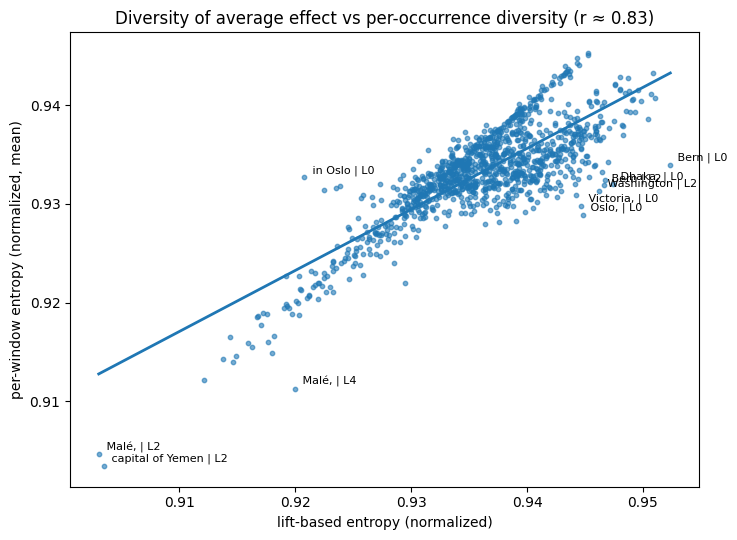

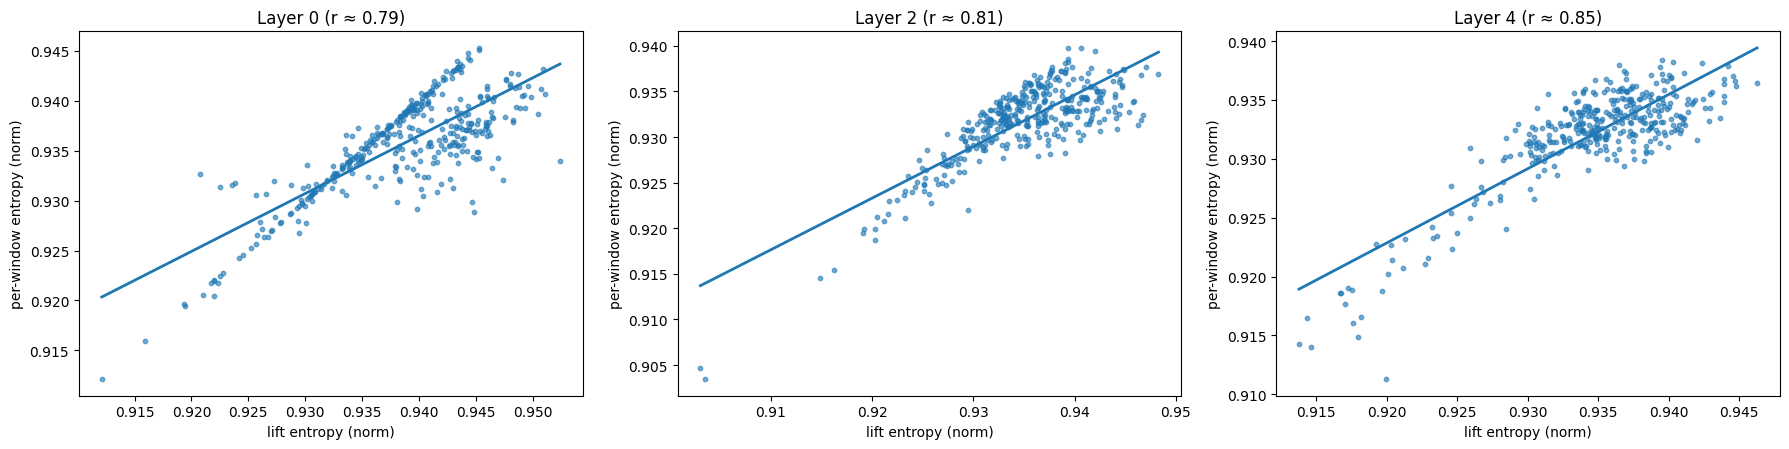

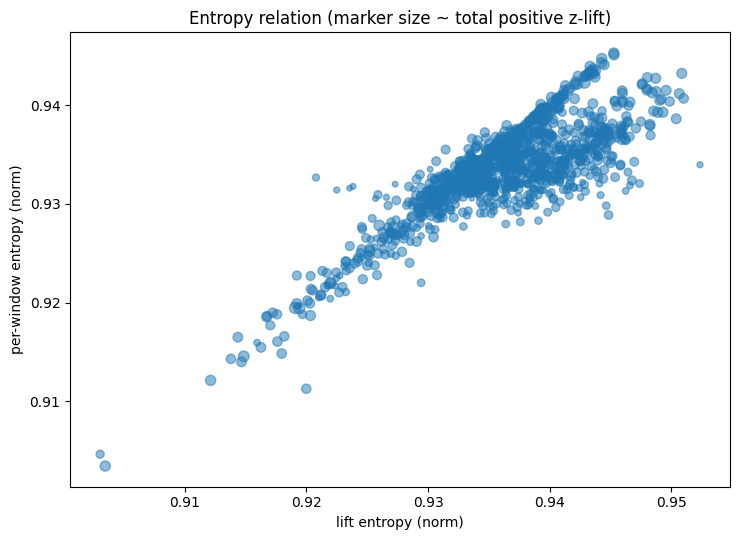

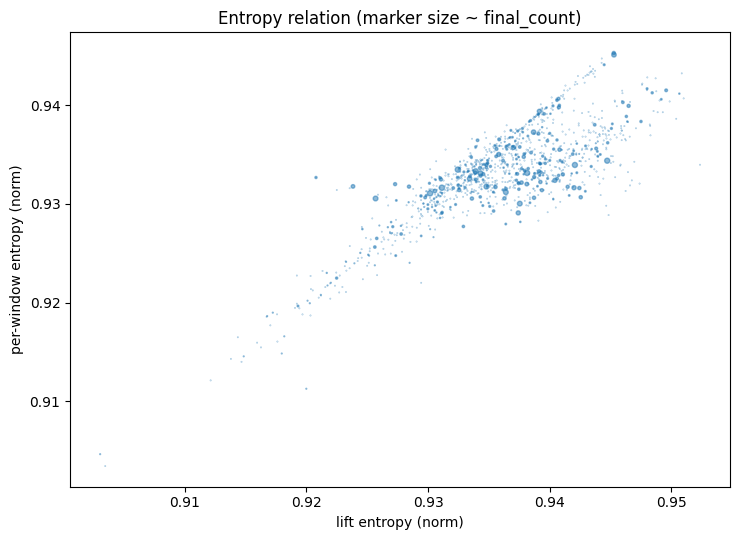

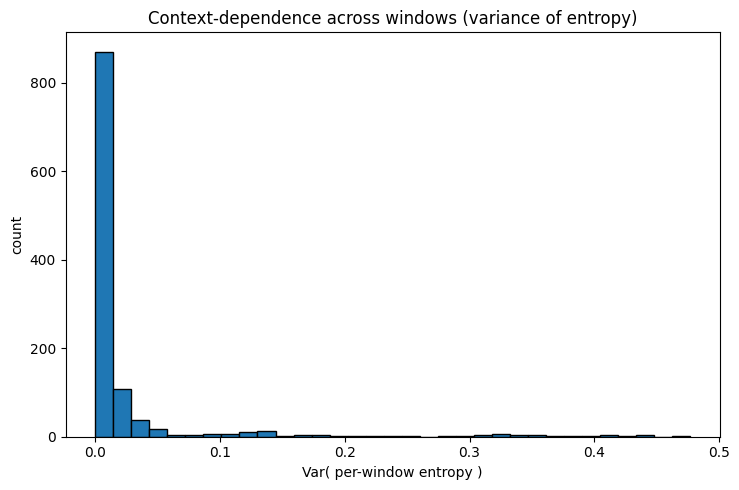

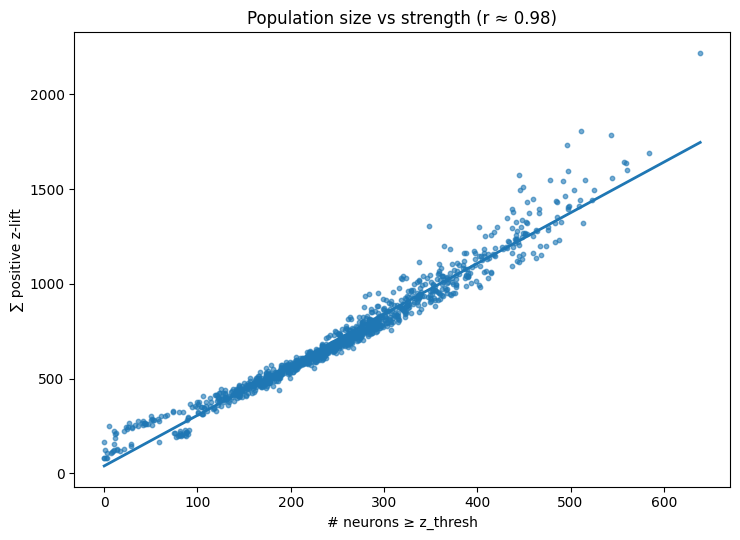

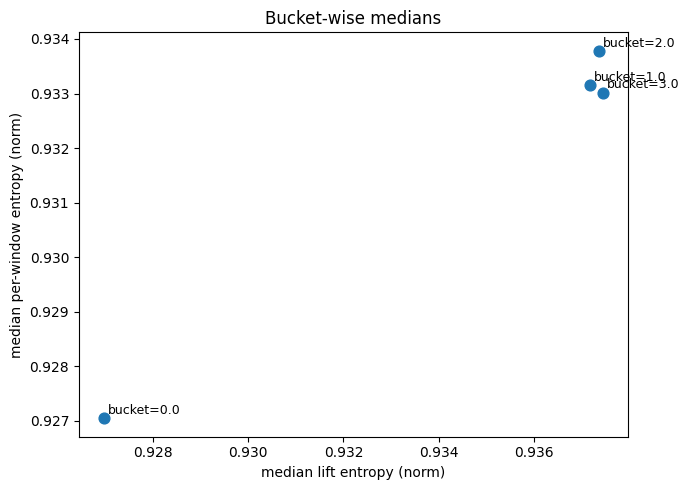

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRIG_DIR = Path("./exposure_artifacts/triggers_step1000/robust")
SUM_PARQ = TRIG_DIR / "gram_layer_diversity.parquet"      # per-gram×layer summary (has div_* and win_entropy_*)
NEU_PARQ = TRIG_DIR / "gram_to_neuron_triggers.parquet"   # per-neuron (optional for some plots)
EXPO_PARQ = "./exposure_artifacts/step1000/exposure_metrics.parquet"  # optional join for final_count

OUT = Path("./exposure_artifacts/step1000/figs_triggers"); OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Load + lightweight prep
# ---------------------------------------------------------------------------
df = pd.read_parquet(SUM_PARQ)

# Optional joins
try:
    df_neu = pd.read_parquet(NEU_PARQ)
except Exception:
    df_neu = None

# Optional exposure join to add frequency proxy (final_count)
try:
    expo = pd.read_parquet(EXPO_PARQ)[["text","final_count","final_rel","bucket"]].rename(columns={"text":"gram_text"})
    df = df.merge(expo, on="gram_text", how="left")
except Exception:
    df["final_count"] = np.nan
    df["final_rel"] = np.nan
    df["bucket"] = np.nan

# Helper: save fig
def _save(fig, name):
    p = OUT / name
    fig.tight_layout()
    fig.savefig(p, dpi=160, bbox_inches="tight")
    print("Saved", p)

# Helper: compute OLS y ~ a + b x
def _ols(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if x.size < 2:
        return (0.0, 0.0, np.zeros_like(x), 0.0)
    X = np.c_[np.ones_like(x), x]
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    # Pearson r
    xv = x - x.mean(); yv = y - y.mean()
    r = float(np.dot(xv, yv) / (np.sqrt((xv**2).sum()) * np.sqrt((yv**2).sum()) + 1e-12))
    return (float(beta[0]), float(beta[1]), yhat, r)

# Helper: annotate top-K residual outliers
def _annotate_outliers(ax, x, y, labels, yhat, k=8):
    resid = np.abs(y - yhat)
    idx = np.argsort(-resid)[:min(k, resid.size)]
    for i in idx:
        ax.annotate(str(labels[i])[:40], (x[i], y[i]), xytext=(3, 3), textcoords="offset points", fontsize=8)

# ---------------------------------------------------------------------------
# 1) div_entropy_norm vs win_entropy_norm_mean (all layers)
# ---------------------------------------------------------------------------
def plot_entropy_scatter_all():
    x = df["div_entropy_norm"].to_numpy(float)
    y = df["win_entropy_norm_mean"].to_numpy(float)
    a, b, yhat, r = _ols(x, y)

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.scatter(x, y, s=10, alpha=0.6)
    # OLS line
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax.plot(xs, a + b * xs, linewidth=2)
    ax.set_xlabel("lift-based entropy (normalized)")
    ax.set_ylabel("per-window entropy (normalized, mean)")
    ax.set_title(f"Diversity of average effect vs per-occurrence diversity (r ≈ {r:.2f})")
    # Outliers by residual
    labels = df["gram_text"].astype(str) + " | L" + df["layer"].astype(int).astype(str)
    _annotate_outliers(ax, x, y, labels.values, yhat, k=10)
    _save(fig, "div_entropy_vs_win_entropy_all.png")

plot_entropy_scatter_all()

# ---------------------------------------------------------------------------
# 2) Same scatter, faceted by layer
# ---------------------------------------------------------------------------
def plot_entropy_scatter_by_layer():
    layers = sorted(df["layer"].dropna().unique().tolist())
    n = len(layers)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.0*ncols, 4.6*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, L in zip(axes, layers):
        sub = df[df["layer"] == L]
        x = sub["div_entropy_norm"].to_numpy(float)
        y = sub["win_entropy_norm_mean"].to_numpy(float)
        a, b, yhat, r = _ols(x, y)
        ax.scatter(x, y, s=10, alpha=0.6)
        if np.isfinite(x).sum() > 1:
            xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            ax.plot(xs, a + b * xs, linewidth=2)
        ax.set_xlabel("lift entropy (norm)")
        ax.set_ylabel("per-window entropy (norm)")
        ax.set_title(f"Layer {L} (r ≈ {r:.2f})")
    # turn off extra axes if any
    for j in range(len(layers), axes.size):
        axes[j].axis("off")
    _save(fig, "div_entropy_vs_win_entropy_by_layer.png")

plot_entropy_scatter_by_layer()

# ---------------------------------------------------------------------------
# 3) Frequency controls: color/size by frequency proxies
# ---------------------------------------------------------------------------
def plot_vs_frequency():
    # sum_pos_z is a strength proxy; final_count is optional from exposure join
    x = df["div_entropy_norm"].to_numpy(float)
    y = df["win_entropy_norm_mean"].to_numpy(float)

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    s = np.sqrt(np.clip(df["sum_pos_z"].to_numpy(float), 0, None) + 1.0) * 1.5
    sc = ax.scatter(x, y, s=s, alpha=0.5)
    ax.set_xlabel("lift entropy (norm)")
    ax.set_ylabel("per-window entropy (norm)")
    ax.set_title("Entropy relation (marker size ~ total positive z-lift)")
    _save(fig, "entropy_relation_sized_by_sum_pos_z.png")

    # If final_count exists, do a second view
    if "final_count" in df.columns and df["final_count"].notna().any():
        fig2, ax2 = plt.subplots(figsize=(7.5, 5.5))
        s2 = np.sqrt(np.clip(df["final_count"].fillna(0).to_numpy(float), 0, None) + 1.0) * 0.1
        ax2.scatter(x, y, s=s2, alpha=0.5)
        ax2.set_xlabel("lift entropy (norm)")
        ax2.set_ylabel("per-window entropy (norm)")
        ax2.set_title("Entropy relation (marker size ~ final_count)")
        _save(fig2, "entropy_relation_sized_by_final_count.png")

plot_vs_frequency()

# ---------------------------------------------------------------------------
# 4) Context-dependence: distribution of per-window entropy variance
# ---------------------------------------------------------------------------
def plot_win_entropy_variance():
    v = df["win_entropy_var"].to_numpy(float)
    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.hist(v[np.isfinite(v)], bins=min(40, max(12, int(np.sqrt(np.isfinite(v).sum())))), edgecolor="black")
    ax.set_xlabel("Var( per-window entropy )")
    ax.set_ylabel("count")
    ax.set_title("Context-dependence across windows (variance of entropy)")
    _save(fig, "win_entropy_variance_hist.png")

plot_win_entropy_variance()

# ---------------------------------------------------------------------------
# 5) How many neurons? Activated-neuron count vs strength
# ---------------------------------------------------------------------------
def plot_active_neurons_vs_strength():
    x = df["div_n_active_zth"].to_numpy(float)  # neurons with z-lift >= threshold
    y = df["sum_pos_z"].to_numpy(float)         # total positive mass
    a, b, yhat, r = _ols(x, y)

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.scatter(x, y, s=10, alpha=0.6)
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax.plot(xs, a + b * xs, linewidth=2)
    ax.set_xlabel("# neurons ≥ z_thresh")
    ax.set_ylabel("∑ positive z-lift")
    ax.set_title(f"Population size vs strength (r ≈ {r:.2f})")
    _save(fig, "active_neurons_vs_strength.png")

plot_active_neurons_vs_strength()

# ---------------------------------------------------------------------------
# 6) Optional: bucket-wise medians (if bucket joined from exposure)
# ---------------------------------------------------------------------------
def plot_bucket_medians():
    if "bucket" not in df.columns or df["bucket"].isna().all():
        return
    groups = df.dropna(subset=["bucket"]).groupby("bucket", sort=True)
    med_x = groups["div_entropy_norm"].median()
    med_y = groups["win_entropy_norm_mean"].median()
    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    ax.scatter(med_x.values, med_y.values, s=60)
    for b, (xx, yy) in enumerate(zip(med_x.values, med_y.values)):
        ax.annotate(f"bucket={med_x.index[b]}", (xx, yy), xytext=(3,3), textcoords="offset points", fontsize=9)
    ax.set_xlabel("median lift entropy (norm)")
    ax.set_ylabel("median per-window entropy (norm)")
    ax.set_title("Bucket-wise medians")
    _save(fig, "bucket_medians_entropy.png")

plot_bucket_medians()

In [ ]:
# === robust_entropy_relationship.py ===
# Examine whether the lift-entropy ↔ per-window-entropy relationship holds without outliers.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
TRIG_DIR = Path("./exposure_artifacts/triggers_step1000/robust")
SUM_PARQ = TRIG_DIR / "gram_layer_diversity.parquet"   # produced by mine_triggers_for_grams_robust
OUT = Path("./exposure_artifacts/step1000/figs_triggers_robust"); OUT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
df = pd.read_parquet(SUM_PARQ).copy()
# keep only finite pairs
df = df[np.isfinite(df["div_entropy_norm"]) & np.isfinite(df["win_entropy_norm_mean"])].copy()

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def ols_stats(x, y):
    """OLS y = a + b x; returns dict with a,b,yhat,r,r2,sigma, leverage, std_resid, cooksD."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    X = np.c_[np.ones_like(x), x]
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ (X.T @ y)
    yhat = X @ beta
    resid = y - yhat
    n, p = X.shape
    sigma2 = (resid @ resid) / max(1, n - p)
    sigma = np.sqrt(sigma2)
    # leverage (hat diag)
    H = (X @ XtX_inv) * X
    h = H.sum(axis=1)
    # standardized residuals
    std_resid = resid / (sigma * np.sqrt(np.maximum(1e-12, 1 - h)))
    # Cook's distance
    cooksD = (std_resid**2) * (h / (p * (1 - h) + 1e-12))
    # Pearson r
    xv = x - x.mean(); yv = y - y.mean()
    r = float(np.dot(xv, yv) / (np.sqrt((xv**2).sum()) * np.sqrt((yv**2).sum()) + 1e-12))
    return {
        "a": float(beta[0]), "b": float(beta[1]),
        "yhat": yhat, "r": r, "r2": r*r,
        "sigma": float(sigma), "std_resid": std_resid, "leverage": h, "cooksD": cooksD,
        "mask": mask
    }

def winsorize(v, lo=0.01, hi=0.99):
    v = np.asarray(v, float).copy()
    lo_v, hi_v = np.nanquantile(v, [lo, hi])
    v = np.clip(v, lo_v, hi_v)
    return v

def scatter_overlay(ax, x_all, y_all, x_trim, y_trim, a_all, b_all, a_trim, b_trim,
                    title, xlabel, ylabel, labels_outliers=None):
    ax.scatter(x_all, y_all, s=8, alpha=0.25, label="all")
    ax.scatter(x_trim, y_trim, s=12, alpha=0.75, label="trimmed")
    if np.isfinite(x_all).sum() > 1:
        xs = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 100)
        ax.plot(xs, a_all + b_all * xs, linewidth=2, label="OLS (all)")
    if np.isfinite(x_trim).sum() > 1:
        xs2 = np.linspace(np.nanmin(x_trim), np.nanmax(x_trim), 100)
        ax.plot(xs2, a_trim + b_trim * xs2, linewidth=2, linestyle="--", label="OLS (trim)")
    if labels_outliers is not None:
        for (x0, y0, lab) in labels_outliers:
            ax.annotate(lab, (x0, y0), xytext=(3,3), textcoords="offset points", fontsize=8)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.legend(frameon=False)

def summarize_block(sub, layer_name, topk=10, do_winsor=True):
    x = sub["div_entropy_norm"].to_numpy(float)
    y = sub["win_entropy_norm_mean"].to_numpy(float)

    # OLS on all
    s_all = ols_stats(x, y)

    # Select outliers by |std_resid|
    idx_all = np.where(s_all["mask"])[0]
    stdr = s_all["std_resid"]
    k = min(topk, stdr.size)
    out_idx_local = np.argsort(-np.abs(stdr))[:k]
    out_idx_global = idx_all[out_idx_local]           # indices in sub
    keep_mask_global = np.ones(sub.shape[0], bool); keep_mask_global[out_idx_global] = False

    # Trimmed OLS
    sub_trim = sub[keep_mask_global].copy()
    xt, yt = sub_trim["div_entropy_norm"].to_numpy(float), sub_trim["win_entropy_norm_mean"].to_numpy(float)
    s_trim = ols_stats(xt, yt)

    # Winsorized (optional)
    if do_winsor:
        xw, yw = winsorize(x), winsorize(y)
        s_win = ols_stats(xw, yw)
    else:
        s_win = None

    # Spearman (rank) correlations for robustness
    def spearman(u, v):
        ru = pd.Series(u).rank().to_numpy(float)
        rv = pd.Series(v).rank().to_numpy(float)
        M = np.isfinite(ru) & np.isfinite(rv)
        if M.sum() < 2: return np.nan
        ru, rv = ru[M], rv[M]
        ru -= ru.mean(); rv -= rv.mean()
        return float(np.dot(ru, rv) / (np.sqrt((ru**2).sum()) * np.sqrt((rv**2).sum()) + 1e-12))
    spr_all  = spearman(x, y)
    spr_trim = spearman(xt, yt)

    # Influence plot (optional): leverage vs standardized residuals
    fig_inf, ax_inf = plt.subplots(figsize=(5.5, 4.2))
    ax_inf.scatter(s_all["leverage"], s_all["std_resid"], s=10, alpha=0.7)
    ax_inf.set_xlabel("leverage (hat diag)"); ax_inf.set_ylabel("standardized residual")
    ax_inf.set_title(f"Influence: layer={layer_name}")
    # annotate top-K
    for gi in out_idx_global:
        ax_inf.annotate(str(sub.iloc[gi]["gram_text"])[:30],
                        (s_all["leverage"][np.where(idx_all==gi)[0][0]],
                         s_all["std_resid"][np.where(idx_all==gi)[0][0]]),
                        xytext=(3,3), textcoords="offset points", fontsize=8)
    fig_inf.tight_layout(); fig_inf.savefig(OUT / f"influence_layer{layer_name}.png", dpi=160, bbox_inches="tight"); plt.close(fig_inf)

    # Scatter overlay
    labels_out = [(x[i], y[i], str(sub.iloc[i]["gram_text"])[:30])
                  for i in out_idx_global[: min(8, len(out_idx_global))]]
    fig, ax = plt.subplots(figsize=(7.6, 5.4))
    scatter_overlay(
        ax, x, y, xt, yt,
        s_all["a"], s_all["b"], s_trim["a"], s_trim["b"],
        title=f"Layer {layer_name}: all vs trimmed (remove top-{k} std-resid)",
        xlabel="lift entropy (normalized)", ylabel="per-window entropy (normalized)",
        labels_outliers=labels_out
    )
    fig.tight_layout(); fig.savefig(OUT / f"scatter_trim_layer{layer_name}.png", dpi=160, bbox_inches="tight"); plt.close(fig)

    # Return numeric summary
    out = {
        "layer": layer_name,
        "n_all": int(np.isfinite(x).sum()),
        "n_trim": int(np.isfinite(xt).sum()),
        "pearson_all": s_all["r"], "pearson_trim": s_trim["r"],
        "spearman_all": spr_all, "spearman_trim": spr_trim,
        "slope_all": s_all["b"], "slope_trim": s_trim["b"],
        "r2_all": s_all["r2"], "r2_trim": s_trim["r2"],
        "sigma_all": s_all["sigma"], "sigma_trim": s_trim["sigma"],
    }
    if s_win is not None:
        out.update({
            "pearson_winsor": s_win["r"],
            "slope_winsor": s_win["b"],
            "r2_winsor": s_win["r2"],
        })
    # Keep the names of removed outliers (for auditing)
    out["removed_examples"] = ", ".join([str(sub.iloc[i]["gram_text"]) for i in out_idx_global[:8]])
    return out

# ------------------------------------------------------------
# Run: per-layer and global
# ------------------------------------------------------------
layers = sorted(df["layer"].dropna().unique().tolist())
summ_rows = []

# Global
summ_rows.append(summarize_block(df, layer_name="ALL", topk=12, do_winsor=True))

# Each layer
for L in layers:
    sub = df[df["layer"] == L].reset_index(drop=True)
    summ_rows.append(summarize_block(sub, layer_name=int(L), topk=8, do_winsor=True))

summary = pd.DataFrame(summ_rows)
summary.to_csv(OUT / "robust_entropy_summary.csv", index=False)
print(summary.round(4))

# Quick text recap in notebook
print("\nSaved figures to:", OUT)
print("Key files:\n - scatter_trim_layer*.png (all vs trimmed overlays)\n - influence_layer*.png (leverage vs standardized residual)\n - robust_entropy_summary.csv")


  layer  n_all  n_trim  pearson_all  pearson_trim  spearman_all  \
0   ALL   1131    1119       0.8258        0.8318        0.7358   
1     0    377     369       0.7949        0.8197        0.6957   
2     2    377     369       0.8075        0.7817        0.6776   
3     4    377     369       0.8453        0.8353        0.6558   

   spearman_trim  slope_all  slope_trim  r2_all  r2_trim  sigma_all  \
0         0.7506     0.6178      0.6195  0.6819   0.6918     0.0027   
1         0.7297     0.5793      0.5991  0.6319   0.6719     0.0030   
2         0.6856     0.5658      0.5231  0.6521   0.6111     0.0026   
3         0.6564     0.6311      0.5840  0.7146   0.6978     0.0023   

   sigma_trim  pearson_winsor  slope_winsor  r2_winsor  \
0      0.0026          0.8196        0.6055     0.6717   
1      0.0028          0.7885        0.5688     0.6217   
2      0.0023          0.7809        0.5230     0.6099   
3      0.0021          0.8460        0.6255     0.7158   

                 

In [ ]:
# === frequency_exposure_impact.py ===
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import shorten

# -----------------------------
# Paths (edit if needed)
# -----------------------------
TRIG_DIR   = Path("./exposure_artifacts/triggers_step1000/robust")
EXPO_FILE  = Path("./exposure_artifacts/step1000/exposure_metrics.parquet")  # <- from build_exposure_metrics
OUT        = Path("./exposure_artifacts/step1000/freq_exposure_vs_triggers")
OUT.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
df_t = pd.read_parquet(TRIG_DIR / "gram_layer_diversity.parquet").copy()
df_e = pd.read_parquet(EXPO_FILE).copy()

# expected keys in these files:
# df_t: gram_text, layer, div_entropy, div_n_active_zth, sum_pos_z, sum_pos_raw, sum_pos_d, ...
# df_e: text, final_count, final_rel, freq_step1000, counts, deltas, exp_rec_tok_hl_*_{ts,final}, exp_rec_steps_hl_*_{ts,final}, ...

# Merge on gram text ↔ exposure text
if "gram_text" not in df_t.columns:
    raise ValueError("Expected 'gram_text' in gram_layer_diversity.parquet.")
if "text" not in df_e.columns:
    raise ValueError("Expected 'text' in exposure_metrics.parquet.")

df = df_t.merge(
    df_e, left_on="gram_text", right_on="text", how="left", suffixes=("", "_expo")
).dropna(subset=["final_count"])

# -----------------------------
# Pick exposure / recency columns automatically
# -----------------------------
tok_final_cols  = [c for c in df.columns if re.fullmatch(r"exp_rec_tok_hl_[0-9.e+-]+_final", c)]
step_final_cols = [c for c in df.columns if re.fullmatch(r"exp_rec_steps_hl_[0-9.e+-]+_final", c)]

def _first_by_halflife(cols):
    # sort by numeric half-life parsed from the column name; return first
    if not cols: return None
    def parse_hl(c):
        m = re.search(r"_hl_([0-9.e+-]+)_final", c)
        return float(m.group(1)) if m else np.inf
    cols_sorted = sorted(cols, key=parse_hl)
    return cols_sorted[0], cols_sorted

TOK_FINAL_COL, TOK_FINAL_ALL = _first_by_halflife(tok_final_cols)
STP_FINAL_COL, STP_FINAL_ALL = _first_by_halflife(step_final_cols)

print("Using recency (tokens):", TOK_FINAL_COL)
print("Using recency (steps): ", STP_FINAL_COL)

# -----------------------------
# Feature assembly
# -----------------------------
# specificity
SPEC = "sum_pos_z" if "sum_pos_z" in df.columns else (
       "sum_pos_raw" if "sum_pos_raw" in df.columns else "sum_pos_d"
)
if SPEC not in df.columns:
    raise ValueError("No specificity signal found (need one of: sum_pos_z, sum_pos_raw, sum_pos_d).")

# diversity
if "div_entropy" not in df.columns or "div_n_active_zth" not in df.columns:
    raise ValueError("Need 'div_entropy' and 'div_n_active_zth' in gram_layer_diversity.parquet.")
DIV_ENT = "div_entropy"
DIV_CNT = "div_n_active_zth"

# frequency/exposure
df["log1p_count"] = np.log1p(df["final_count"].astype(float))
df["log1p_rel"]   = np.log1p(np.maximum(df["final_rel"].astype(float), 0.0))
if TOK_FINAL_COL:
    df["rec_tok_final"] = df[TOK_FINAL_COL].astype(float)
    df["log1p_rec_tok"] = np.log1p(df["rec_tok_final"])
if STP_FINAL_COL:
    df["rec_stp_final"] = df[STP_FINAL_COL].astype(float)
    df["log1p_rec_stp"] = np.log1p(df["rec_stp_final"])

# Working view
keep = ["gram_text","layer",SPEC,DIV_ENT,DIV_CNT,"final_count","final_rel","log1p_count","log1p_rel"]
if TOK_FINAL_COL: keep += ["rec_tok_final","log1p_rec_tok"]
if STP_FINAL_COL: keep += ["rec_stp_final","log1p_rec_stp"]
dfw = df[keep].copy()

# -----------------------------
# Correlations & partials
# -----------------------------
def corr(a, b, method="pearson"):
    s = dfw[[a, b]].replace([np.inf,-np.inf], np.nan).dropna()
    return s.corr(method=method).iloc[0,1] if not s.empty else np.nan

def residualize(y, X):
    y = np.asarray(y, float)
    X = np.asarray(X, float)
    if X.ndim == 1: X = X[:,None]
    mask = np.isfinite(y) & np.isfinite(X).all(1)
    y2, X2 = y[mask], X[mask]
    if len(y2) < 3:
        return np.full_like(y, np.nan, dtype=float)
    Z = np.c_[np.ones_like(y2), X2]
    beta = np.linalg.pinv(Z) @ y2
    resid = np.full_like(y, np.nan, dtype=float)
    resid[mask] = y2 - Z @ beta
    return resid

def partial_corr(x, y, controls):
    xr = residualize(dfw[x], dfw[controls].to_numpy(float))
    yr = residualize(dfw[y], dfw[controls].to_numpy(float))
    m = np.isfinite(xr) & np.isfinite(yr)
    if m.sum() < 3: return np.nan
    xr, yr = xr[m], yr[m]
    xr = (xr - xr.mean()) / (xr.std() + 1e-12)
    yr = (yr - yr.mean()) / (yr.std() + 1e-12)
    return float((xr*yr).mean())

pairs = [
    ("log1p_count", SPEC),
    ("log1p_count", DIV_ENT),
    ("log1p_count", DIV_CNT),
    ("log1p_rel",   SPEC),
    ("log1p_rel",   DIV_ENT),
    ("log1p_rel",   DIV_CNT),
]
if TOK_FINAL_COL:
    pairs += [("log1p_rec_tok", SPEC), ("log1p_rec_tok", DIV_ENT)]
if STP_FINAL_COL:
    pairs += [("log1p_rec_stp", SPEC), ("log1p_rec_stp", DIV_ENT)]

rows=[]
for x, y in pairs:
    rows.append({
        "x": x, "y": y,
        "pearson": corr(x,y,"pearson"),
        "spearman": corr(x,y,"spearman")
    })
df_corr = pd.DataFrame(rows).sort_values(["x","y"]).reset_index(drop=True)
print("\nCorrelation summary:")
print(df_corr.round(4))

# Partial: does SPEC ↔ DIV_ENT hold after frequency?
controls = ["log1p_count"]
if TOK_FINAL_COL:  # you can choose to control with recency instead/too
    pass
pc = partial_corr(SPEC, DIV_ENT, controls)
print(f"\nPartial corr( {SPEC} ↔ {DIV_ENT} | {controls} ) ≈ {pc:.3f}")

# -----------------------------
# Plots
# -----------------------------
def scatter_fit(df_, x, y, title, fname, color=None, annotate_k=8):
    d = df_[[x,y,"gram_text"] + ([color] if color else [])].replace([np.inf,-np.inf],np.nan).dropna()
    if d.empty: return
    fig, ax = plt.subplots(figsize=(7.5,5.6))
    if color:
        c = d[color].to_numpy(float)
        sc = ax.scatter(d[x], d[y], c=c, cmap="viridis", alpha=0.8, s=18)
        cb = fig.colorbar(sc); cb.set_label(color)
    else:
        ax.scatter(d[x], d[y], alpha=0.8, s=18)
    # OLS line
    X = np.c_[np.ones(len(d)), d[x].to_numpy(float)]
    beta = np.linalg.pinv(X) @ d[y].to_numpy(float)
    xs = np.linspace(d[x].min(), d[x].max(), 200)
    ax.plot(xs, beta[0] + beta[1]*xs, linewidth=2)
    # label a few large residuals
    resid = d[y] - (X @ beta)
    s = resid / (resid.std() + 1e-12)
    for i in np.argsort(-np.abs(s))[:annotate_k]:
        ax.annotate(shorten(str(d.iloc[i]["gram_text"]), width=22, placeholder="…"),
                    (d.iloc[i][x], d.iloc[i][y]), xytext=(4,3),
                    textcoords="offset points", fontsize=8)
    ax.set_title(title); ax.set_xlabel(x); ax.set_ylabel(y)
    fig.tight_layout(); fig.savefig(OUT / fname, dpi=160, bbox_inches="tight"); plt.close(fig)

def by_layer_scatter(df_, x, y, prefix):
    for L, sub in df_.groupby("layer"):
        scatter_fit(sub, x, y,
                    title=f"Layer {L}: {y} vs {x}",
                    fname=f"{prefix}_L{L}.png",
                    color=None)

# Frequency vs specificity/diversity
scatter_fit(dfw, "log1p_count", SPEC,     f"{SPEC} vs log1p_count",     "spec_vs_log1p_count.png")
scatter_fit(dfw, "log1p_count", DIV_ENT,  f"{DIV_ENT} vs log1p_count",  "divent_vs_log1p_count.png")
scatter_fit(dfw, "log1p_count", DIV_CNT,  f"{DIV_CNT} vs log1p_count",  "divcnt_vs_log1p_count.png")

# Specificity vs diversity colored by exposure
scatter_fit(dfw, SPEC, DIV_ENT, f"{DIV_ENT} vs {SPEC} (colored by log1p_count)",
            "divent_vs_spec_colfreq.png", color="log1p_count")

# Recency variants (if present)
if TOK_FINAL_COL:
    scatter_fit(dfw, "log1p_rec_tok", SPEC,    f"{SPEC} vs log1p_rec_tok",    "spec_vs_log1p_rec_tok.png")
    scatter_fit(dfw, "log1p_rec_tok", DIV_ENT, f"{DIV_ENT} vs log1p_rec_tok", "divent_vs_log1p_rec_tok.png")
if STP_FINAL_COL:
    scatter_fit(dfw, "log1p_rec_stp", SPEC,    f"{SPEC} vs log1p_rec_stp",    "spec_vs_log1p_rec_stp.png")
    scatter_fit(dfw, "log1p_rec_stp", DIV_ENT, f"{DIV_ENT} vs log1p_rec_stp", "divent_vs_log1p_rec_stp.png")

# Layer-wise views
by_layer_scatter(dfw, "log1p_count", SPEC,    "spec_vs_log1p_count")
by_layer_scatter(dfw, "log1p_count", DIV_ENT, "divent_vs_log1p_count")

# Quartile medians by frequency
def bucket_medians(x_var, y_var, nbins=4, fname="bucket_medians.png"):
    d = dfw[[x_var, y_var, "layer"]].replace([np.inf,-np.inf], np.nan).dropna()
    if d.empty: return
    q = np.nanquantile(d[x_var], np.linspace(0,1,nbins+1))
    d["bucket"] = pd.cut(d[x_var], bins=q, include_lowest=True, labels=False)
    rows=[]
    for (L, b), grp in d.groupby(["layer","bucket"]):
        rows.append({"layer":int(L),"bucket":int(b),
                     "median_x":float(np.nanmedian(grp[x_var])),
                     "median_y":float(np.nanmedian(grp[y_var])),
                     "n":int(len(grp))})
    med = pd.DataFrame(rows).sort_values(["layer","bucket"])
    for L, sub in med.groupby("layer"):
        fig, ax = plt.subplots(figsize=(6.0,4.4))
        ax.plot(sub["median_x"], sub["median_y"], marker="o")
        for r in sub.itertuples(index=False):
            ax.annotate(f"b={r.bucket}, n={r.n}", (r.median_x, r.median_y),
                        xytext=(5,4), textcoords="offset points", fontsize=8)
        ax.set_title(f"Layer {L}: medians across {nbins} frequency buckets")
        ax.set_xlabel(x_var); ax.set_ylabel(y_var)
        fig.tight_layout(); fig.savefig(OUT / f"{Path(fname).stem}_L{L}.png", dpi=160, bbox_inches="tight"); plt.close(fig)
    return med

med1 = bucket_medians("log1p_count", DIV_ENT, nbins=4, fname="bucket_medians_div_entropy.png")
med2 = bucket_medians("log1p_count", SPEC,    nbins=4, fname="bucket_medians_specificity.png")

# Save numeric tables
df_corr.to_csv(OUT / "correlations.csv", index=False)
if med1 is not None: med1.to_csv(OUT / "bucket_medians_div_entropy.csv", index=False)
if med2 is not None: med2.to_csv(OUT / "bucket_medians_specificity.csv", index=False)

print("\nSaved figures to:", OUT)


Using recency (tokens): exp_rec_tok_hl_5e+08_final
Using recency (steps):  exp_rec_steps_hl_6e+01_final

Correlation summary:
               x                 y  pearson  spearman
0    log1p_count       div_entropy   0.0632    0.1147
1    log1p_count  div_n_active_zth  -0.3865   -0.3646
2    log1p_count         sum_pos_z  -0.4229   -0.3932
3  log1p_rec_stp       div_entropy   0.0664    0.1218
4  log1p_rec_stp         sum_pos_z  -0.4109   -0.3928
5  log1p_rec_tok       div_entropy   0.0665    0.1206
6  log1p_rec_tok         sum_pos_z  -0.4138   -0.3913
7      log1p_rel       div_entropy  -0.0400    0.1147
8      log1p_rel  div_n_active_zth  -0.2526   -0.3646
9      log1p_rel         sum_pos_z  -0.2388   -0.3932

Partial corr( sum_pos_z ↔ div_entropy | ['log1p_count'] ) ≈ 0.619

Saved figures to: exposure_artifacts/step1000/freq_exposure_vs_triggers


Todo

- Add Jaccard churn of top-K triggers across checkpoints (repeat this at step 512 vs 1000).
- Wire your counts_matrix to correlate exposure(at t) with assoc_lift(at t); fit a simple GAM/logit.
- Build Neuron summaries + select neurons for additional analysis
- Polysemanticity scores, using entropy/simple statistic as well as neural embeddings statistic
- Find critical frequency/exposure

# deprecated

In [ ]:
from __future__ import annotations
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import numpy as np
import pandas as pd
import torch
from nnsight import LanguageModel

def sample_positions_for_ngram(
    ng_ids: Tuple[int, ...],
    *,
    max_samples: int = 64,
    cutoff_tokens: Optional[int] = None,
) -> np.ndarray:
    """Sorted start positions of the n-gram, optionally filtered to end <= cutoff."""
    pos = tg.positions(ng_ids)
    if pos.size == 0:
        return pos
    if cutoff_tokens is not None:
        pos = pos[(pos + len(ng_ids)) <= cutoff_tokens]
        if pos.size == 0:
            return pos
    if pos.size <= max_samples:
        return pos
    idx = np.linspace(0, pos.size - 1, num=max_samples, dtype=int)
    return pos[idx]

def make_windows_from_positions(
    positions: np.ndarray,
    ng_len: int,
    *,
    seq_len: int = 256,
    anchor_pos: int = 192,   # end token of gram sits here
    prefix_bin: Path,
    dtype,
) -> list[list[int]]:
    """Slice token windows so that gram end token falls at anchor_pos."""
    if positions.size == 0:
        return []
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total = arr.shape[0]
    out: list[list[int]] = []
    for start in positions:
        end = start + ng_len - 1
        win_start = end - anchor_pos
        win_start = max(0, min(int(win_start), total - seq_len))
        out.append(arr[win_start:win_start+seq_len].tolist())
    del arr
    return out

def decode_windows(token_windows: list[list[int]]) -> list[str]:
    return [tok.decode(w) for w in token_windows]

def end_interval_indices(end_positions: np.ndarray, cutoffs_tokens: np.ndarray) -> np.ndarray:
    """
    Map each end position to its training interval index t in [0..T-1].
    We treat cutoffs as cumulative token counts at the END of each interval.
    """
    # interval t: tokens in (cutoffs[t-1], cutoffs[t]] ; define cutoffs[-1]=0
    return np.searchsorted(cutoffs_tokens, end_positions, side="right") - 1

def random_windows_matched_by_intervals(
    counts_per_interval: np.ndarray,
    *,
    seq_len: int,
    anchor_pos: int,
    cutoffs_tokens: np.ndarray,
    prefix_bin: Path,
    dtype,
    avoid_gram: Optional[Tuple[int, ...]] = None,
    max_resample_per_interval: int = 10,
    rng: Optional[np.random.Generator] = None,
) -> list[list[int]]:
    """
    Sample baseline windows that (1) respect the prefix cutoff for each interval and
    (2) match the interval counts provided (one window per requested count per interval).
    We anchor at `anchor_pos` inside each window. Optionally filter out windows whose
    anchor token ends with `avoid_gram`.
    """
    rng = rng or np.random.default_rng(0)
    T = len(cutoffs_tokens)
    lo = np.r_[0, cutoffs_tokens[:-1]]
    hi = cutoffs_tokens
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total = arr.shape[0]
    out: list[list[int]] = []

    for t, k in enumerate(counts_per_interval.tolist()):
        if k <= 0:
            continue
        lo_t, hi_t = int(lo[t]), int(hi[t])
        # end positions allowed in [lo_t, hi_t) (exclusive hi for safety)
        if hi_t <= lo_t:
            continue
        for _ in range(int(k)):
            ok = False
            tries = 0
            while not ok and tries < max_resample_per_interval:
                end_pos = rng.integers(lo_t, hi_t)
                win_start = end_pos - anchor_pos
                win_start = max(0, min(int(win_start), total - seq_len))
                w = arr[win_start:win_start+seq_len].tolist()
                if avoid_gram is not None:
                    # filter out accidental matches where gram ends at anchor
                    ids = tok.encode(tok.decode(w))
                    a = min(anchor_pos, len(ids)-1)
                    g = list(avoid_gram)
                    # check if gram ends at 'a'
                    if a - len(g) + 1 >= 0 and ids[a-len(g)+1:a+1] == g:
                        tries += 1
                        continue
                out.append(w)
                ok = True
    del arr
    return out

    def capture_postacts_fixed_anchor(
    lm: LanguageModel,
    texts: list[str],
    layers: list[int],
    *,
    anchor_pos: int,
    batch_size: int = 32,
    torch_dtype = torch.float16,
) -> Dict[int, np.ndarray]:
    """Return {layer: [N, D]} at a fixed anchor_pos inside each text."""
    if len(texts) == 0:
        return {L: np.zeros((0,1), dtype=np.float32) for L in layers}

    def run_batch(bt: list[str]):
        with lm.trace(bt) as tr:
            caps = [lm.gpt_neox.layers[L].mlp.dense_4h_to_h.input.save() for L in layers]
            _ = lm.output.save()
        return [c.value[:, anchor_pos, :].to("cpu").float().detach().numpy() for c in caps]

    acc = {L: [] for L in layers}
    for i in range(0, len(texts), batch_size):
        bt = texts[i:i+batch_size]
        arrs = run_batch(bt)
        for L, a in zip(layers, arrs): acc[L].append(a)
    return {L: (np.concatenate(v, 0) if v else np.zeros((0,1), np.float32)) for L, v in acc.items()}

def compute_effects(
    gram: Dict[int, np.ndarray],
    base: Dict[int, np.ndarray],
) -> Dict[int, Dict[str, np.ndarray]]:
    """
    For each layer, compute μ, σ, and multiple effect sizes.
    Returns per-layer dict with:
      - mu_gram, mu_base, sd_gram, sd_base
      - lift_raw, lift_z (Glass Δ), lift_d (Cohen’s d)
    """
    out: Dict[int, Dict[str, np.ndarray]] = {}
    for L in gram.keys():
        G = gram[L]; B = base[L]
        if G.shape[0] == 0 or B.shape[0] == 0:
            out[L] = dict(
                mu_gram=None, mu_base=None, sd_gram=None, sd_base=None,
                lift_raw=None, lift_z=None, lift_d=None,
                n_gram=G.shape[0], n_base=B.shape[0]
            )
            continue
        mu_g = G.mean(0); mu_b = B.mean(0)
        sd_g = G.std(0, ddof=1); sd_b = B.std(0, ddof=1)
        lift = mu_g - mu_b
        # Glass delta: standardize by baseline sd
        z = lift / (sd_b + 1e-6)
        # Cohen's d (pooled)
        sd_p = np.sqrt((sd_b**2 + sd_g**2) / 2.0)
        d = lift / (sd_p + 1e-6)

        out[L] = dict(
            mu_gram=mu_g, mu_base=mu_b, sd_gram=sd_g, sd_base=sd_b,
            lift_raw=lift, lift_z=z, lift_d=d,
            n_gram=G.shape[0], n_base=B.shape[0]
        )
    return out

def diversity_from_vector(
    v: np.ndarray,
    *,
    z_thresh: float = 1.0,
    topk: int = 10,
) -> Dict[str, float]:
    """
    v is a per-neuron vector of effects (e.g., z-lift). We form a positive
    mass distribution from ReLU(v). Diversity is measured on that distribution.
    """
    v = np.asarray(v, dtype=np.float64)
    pos = np.clip(v, 0.0, None)
    mass = pos.sum()
    n_pos = int((pos > 0).sum())
    n_zth = int((v >= z_thresh).sum())

    if mass <= 0 or n_pos == 0:
        return dict(
            n_active_pos=0, n_active_zth=n_zth, entropy=0.0, entropy_norm=0.0,
            gini_simpson=0.0, effective_number=0.0, topk_mass=0.0, dw_strength=0.0
        )

    p = pos / mass
    # Shannon entropy
    H = float(-(p * np.log(p + 1e-12)).sum())
    H_norm = H / np.log(n_pos) if n_pos > 1 else 0.0
    # Simpson / Hill
    sumsq = float((p**2).sum())
    gini_simpson = 1.0 - sumsq
    effective_number = 1.0 / sumsq if sumsq > 0 else float(n_pos)
    # Top-k mass
    k = min(topk, p.size)
    topk_mass = float(np.sort(p)[-k:].sum())
    # Diversity-weighted strength (simple: total positive mass × normalized entropy)
    dw_strength = float(mass * H_norm)

    return dict(
        n_active_pos=int(n_pos),
        n_active_zth=n_zth,
        entropy=H,
        entropy_norm=H_norm,
        gini_simpson=gini_simpson,
        effective_number=effective_number,
        topk_mass=topk_mass,
        dw_strength=dw_strength
    )

# ------------------------------ Main mining API -----------------------------

def mine_triggers_for_grams_robust(
    grams_ids: List[Tuple[int, ...]],
    grams_text: List[str],
    *,
    layers: List[int] = (0, 2, 4),
    seq_len: int = 256,
    anchor_pos: int = 192,
    max_occurrences_per_gram: int = 64,
    baseline_ratio: float = 1.0,   # #baseline windows per gram window (matched per interval)
    min_gram_windows: int = 8,     # skip grams with very low support
    hf_id: str = "EleutherAI/pythia-70m-deduped",
    device_map: str = "auto",
    torch_dtype = torch.float16,
    out_dir: Path = Path("./exposure_artifacts/triggers_step1000"),
    cutoff_tokens: Optional[int] = None,  # respect checkpoint cutoff if provided
    z_thresh: float = 1.0,
    diversity_topk: int = 10,
    rng_seed: int = 0,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Robust gram→neuron mining with matched baselines and diversity/entropy metrics.
    Returns (df_per_neuron, df_gram_layer_diversity).
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(rng_seed)

    # Load model ONCE
    lm = LanguageModel(hf_id, device_map=device_map, torch_dtype=torch_dtype, dispatch=True)

    T = len(EARLY_CUTOFFS_12)
    cut_tok = np.asarray(EARLY_CUTOFFS_12, dtype=np.int64)

    per_neuron_rows = []
    per_gram_rows   = []

    # Pre-memmap to compute interval distribution per gram occurrence
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")  # not strictly needed here, but useful if inspecting positions
    del arr

    for g_ids, g_txt in zip(grams_ids, grams_text):
        # --- 1) Sample gram windows (respect cutoff if provided)
        pos = sample_positions_for_ngram(g_ids, max_samples=max_occurrences_per_gram, cutoff_tokens=cutoff_tokens)
        if pos.size == 0:
            continue
        ng_len = len(g_ids)
        end_pos = pos + ng_len - 1
        # interval counts for this gram
        t_idx = end_interval_indices(end_pos, cut_tok)
        gram_counts_per_interval = np.bincount(t_idx, minlength=T)

        # materialize windows & texts
        gram_wins = make_windows_from_positions(pos, ng_len=ng_len, seq_len=seq_len, anchor_pos=anchor_pos,
                                                prefix_bin=prefix_bin, dtype=dtype)
        gram_texts = decode_windows(gram_wins)
        if len(gram_texts) < min_gram_windows:
            continue

        # --- 2) Matched baseline by intervals (respect cutoff)
        k_per_interval = np.round(gram_counts_per_interval * baseline_ratio).astype(int)
        base_wins = random_windows_matched_by_intervals(
            counts_per_interval=k_per_interval,
            seq_len=seq_len, anchor_pos=anchor_pos,
            cutoffs_tokens=cut_tok,
            prefix_bin=prefix_bin, dtype=dtype,
            avoid_gram=g_ids, rng=rng
        )
        base_texts = decode_windows(base_wins)

        # --- 3) Capture activations at anchor_pos
        gram_act = capture_postacts_fixed_anchor(lm, gram_texts, list(layers), anchor_pos=anchor_pos)
        base_act = capture_postacts_fixed_anchor(lm, base_texts, list(layers), anchor_pos=anchor_pos)

        # --- 4) Effects (raw, z, d)
        effects = compute_effects(gram_act, base_act)

        # --- 5) Emit per-neuron rows and per-gram diversity metrics
        for L in layers:
            meta = effects[L]
            if meta["lift_raw"] is None:
                continue

            lift_raw = meta["lift_raw"]
            lift_z   = meta["lift_z"]
            lift_d   = meta["lift_d"]

            # Per-NEURON rows (rank by z-lift)
            idx = np.argsort(-lift_z)  # rank by standardized effect
            for rank, j in enumerate(idx.tolist(), start=1):
                per_neuron_rows.append({
                    "gram_text": g_txt,
                    "gram_ids": list(g_ids),
                    "len": ng_len,
                    "layer": int(L),
                    "neuron": int(j),
                    "rank": int(rank),
                    "lift_raw": float(lift_raw[j]),
                    "lift_z": float(lift_z[j]),
                    "lift_d": float(lift_d[j]),
                    "mu_gram": float(meta["mu_gram"][j]),
                    "mu_base": float(meta["mu_base"][j]),
                    "sd_gram": float(meta["sd_gram"][j]),
                    "sd_base": float(meta["sd_base"][j]),
                    "n_gram": int(meta["n_gram"]),
                    "n_base": int(meta["n_base"]),
                    "baseline_ratio": float(baseline_ratio),
                    "anchor_pos": int(anchor_pos),
                })

            # Gram×Layer DIVERSITY summary from z-lift
            div = diversity_from_vector(lift_z, z_thresh=z_thresh, topk=diversity_topk)
            per_gram_rows.append({
                "gram_text": g_txt,
                "gram_ids": list(g_ids),
                "len": ng_len,
                "layer": int(L),
                "n_gram_windows": int(meta["n_gram"]),
                "n_base_windows": int(meta["n_base"]),
                "z_thresh": float(z_thresh),
                "div_n_active_pos": int(div["n_active_pos"]),
                "div_n_active_zth": int(div["n_active_zth"]),
                "div_entropy": float(div["entropy"]),
                "div_entropy_norm": float(div["entropy_norm"]),
                "div_gini_simpson": float(div["gini_simpson"]),
                "div_effective_number": float(div["effective_number"]),
                "div_topk_mass": float(div["topk_mass"]),
                "div_dw_strength": float(div["dw_strength"]),
                # Strength aggregates (useful to correlate with diversity)
                "sum_pos_z": float(np.clip(lift_z, 0, None).sum()),
                "sum_pos_raw": float(np.clip(lift_raw, 0, None).sum()),
                "sum_pos_d": float(np.clip(lift_d, 0, None).sum()),
            })

    # Assemble outputs
    df_neuron = pd.DataFrame(per_neuron_rows).sort_values(
        ["gram_text", "layer", "rank"], ascending=[True, True, True]
    ).reset_index(drop=True)

    df_div = pd.DataFrame(per_gram_rows).sort_values(
        ["gram_text", "layer"], ascending=[True, True]
    ).reset_index(drop=True)

    # Save
    (out_dir / "robust").mkdir(parents=True, exist_ok=True)
    df_neuron.to_parquet(out_dir / "robust" / "gram_to_neuron_triggers.parquet", index=False)
    df_div.to_parquet(out_dir / "robust" / "gram_layer_diversity.parquet", index=False)
    return df_neuron, df_div

In [ ]:
grams_text = all_texts
grams_ids  = all_ids
df_neuron, df_div = mine_triggers_for_grams_robust(
    grams_ids=grams_ids,
    grams_text=grams_text,
    layers=[0, 2, 4],
    seq_len=256,
    anchor_pos=192,
    max_occurrences_per_gram=64,
    baseline_ratio=1.0,
    min_gram_windows=8,
    hf_id="EleutherAI/pythia-70m-deduped",  # swap to checkpoint-specific id when comparing steps
    out_dir=Path("./exposure_artifacts/triggers_step1000"),
    cutoff_tokens=int(EARLY_CUTOFFS_12[-1]),  # respect 1000 cutoff
    z_thresh=1.0,
    diversity_topk=10,
    rng_seed=0,
)
print(df_neuron.head())
print(df_div.head())

In [ ]:
# =========================== robust_lift_with_entropy.py ===========================
from __future__ import annotations
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import numpy as np
import pandas as pd
import torch
from nnsight import LanguageModel

# ------------------------------ Sampling utils ------------------------------

def sample_positions_for_ngram(
    ng_ids: Tuple[int, ...],
    *,
    max_samples: int = 64,
    cutoff_tokens: Optional[int] = None,
) -> np.ndarray:
    """Sorted start positions of the n-gram, optionally filtered to end <= cutoff."""
    pos = tg.positions(ng_ids)
    if pos.size == 0:
        return pos
    if cutoff_tokens is not None:
        pos = pos[(pos + len(ng_ids)) <= cutoff_tokens]
        if pos.size == 0:
            return pos
    if pos.size <= max_samples:
        return pos
    idx = np.linspace(0, pos.size - 1, num=max_samples, dtype=int)
    return pos[idx]

def make_windows_from_positions(
    positions: np.ndarray,
    ng_len: int,
    *,
    seq_len: int = 256,
    anchor_pos: int = 192,   # end token of gram sits here
    prefix_bin: Path = None,
    dtype=None,
) -> list[list[int]]:
    """Slice token windows so that gram end token falls at anchor_pos."""
    if positions.size == 0:
        return []
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total = arr.shape[0]
    out: list[list[int]] = []
    for start in positions:
        end = start + ng_len - 1
        win_start = end - anchor_pos
        win_start = max(0, min(int(win_start), total - seq_len))
        out.append(arr[win_start:win_start+seq_len].tolist())
    del arr
    return out

def decode_windows(token_windows: list[list[int]]) -> list[str]:
    return [tok.decode(w) for w in token_windows]

# -------------------------- Interval/anchor utilities -----------------------

def end_interval_indices(end_positions: np.ndarray, cutoffs_tokens: np.ndarray) -> np.ndarray:
    """
    Map each end position to its training interval index t in [0..T-1].
    We treat cutoffs as cumulative token counts at the END of each interval.
    """
    return np.searchsorted(cutoffs_tokens, end_positions, side="right") - 1

def random_windows_matched_by_intervals(
    counts_per_interval: np.ndarray,
    *,
    seq_len: int,
    anchor_pos: int,
    cutoffs_tokens: np.ndarray,
    prefix_bin: Path,
    dtype,
    avoid_gram: Optional[Tuple[int, ...]] = None,
    max_resample_per_interval: int = 10,
    rng: Optional[np.random.Generator] = None,
) -> list[list[int]]:
    """
    Sample baseline windows that (1) respect the prefix cutoff for each interval and
    (2) match the interval counts provided (one window per requested count per interval).
    Anchor at `anchor_pos`. Optionally filter out windows whose anchor ends with `avoid_gram`.
    """
    rng = rng or np.random.default_rng(0)
    T = len(cutoffs_tokens)
    lo = np.r_[0, cutoffs_tokens[:-1]]
    hi = cutoffs_tokens
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total = arr.shape[0]
    out: list[list[int]] = []

    for t, k in enumerate(counts_per_interval.tolist()):
        if k <= 0:
            continue
        lo_t, hi_t = int(lo[t]), int(hi[t])
        if hi_t <= lo_t:
            continue
        for _ in range(int(k)):
            ok = False
            tries = 0
            while not ok and tries < max_resample_per_interval:
                end_pos = rng.integers(lo_t, hi_t)
                win_start = end_pos - anchor_pos
                win_start = max(0, min(int(win_start), total - seq_len))
                w = arr[win_start:win_start+seq_len].tolist()
                if avoid_gram is not None:
                    # filter out accidental matches where gram ends at anchor
                    ids = tok.encode(tok.decode(w))
                    a = min(anchor_pos, len(ids)-1)
                    g = list(avoid_gram)
                    if a - len(g) + 1 >= 0 and ids[a-len(g)+1:a+1] == g:
                        tries += 1
                        continue
                out.append(w)
                ok = True
    del arr
    return out

# ------------------------------ Capture utils -------------------------------

def capture_postacts_fixed_anchor(
    lm: LanguageModel,
    texts: list[str],
    layers: list[int],
    *,
    anchor_pos: int,
    batch_size: int = 32,
) -> Dict[int, np.ndarray]:
    """Return {layer: [N, D]} at a fixed anchor_pos inside each text."""
    if len(texts) == 0:
        return {L: np.zeros((0,1), dtype=np.float32) for L in layers}

    def run_batch(bt: list[str]):
        with lm.trace(bt) as tr:
            caps = [lm.gpt_neox.layers[L].mlp.dense_4h_to_h.input.save() for L in layers]
            _ = lm.output.save()
        return [c.value[:, anchor_pos, :].to("cpu").float().detach().numpy() for c in caps]

    acc = {L: [] for L in layers}
    for i in range(0, len(texts), batch_size):
        bt = texts[i:i+batch_size]
        arrs = run_batch(bt)
        for L, a in zip(layers, arrs): acc[L].append(a)
    return {L: (np.concatenate(v, 0) if v else np.zeros((0,1), np.float32)) for L, v in acc.items()}

# ------------------------------ Effect sizes --------------------------------

def compute_effects(
    gram: Dict[int, np.ndarray],
    base: Dict[int, np.ndarray],
) -> Dict[int, Dict[str, np.ndarray]]:
    """
    For each layer, compute μ, σ, and multiple effect sizes.
    Returns per-layer dict with:
      - mu_gram, mu_base, sd_gram, sd_base
      - lift_raw, lift_z (Glass Δ), lift_d (Cohen’s d)
    """
    out: Dict[int, Dict[str, np.ndarray]] = {}
    for L in gram.keys():
        G = gram[L]; B = base[L]
        if G.shape[0] == 0 or B.shape[0] == 0:
            out[L] = dict(
                mu_gram=None, mu_base=None, sd_gram=None, sd_base=None,
                lift_raw=None, lift_z=None, lift_d=None,
                n_gram=G.shape[0], n_base=B.shape[0]
            )
            continue
        mu_g = G.mean(0); mu_b = B.mean(0)
        sd_g = G.std(0, ddof=1); sd_b = B.std(0, ddof=1)
        lift = mu_g - mu_b
        # Glass delta: standardize by baseline sd
        z = lift / (sd_b + 1e-6)
        # Cohen's d (pooled)
        sd_p = np.sqrt((sd_b**2 + sd_g**2) / 2.0)
        d = lift / (sd_p + 1e-6)

        out[L] = dict(
            mu_gram=mu_g, mu_base=mu_b, sd_gram=sd_g, sd_base=sd_b,
            lift_raw=lift, lift_z=z, lift_d=d,
            n_gram=G.shape[0], n_base=B.shape[0]
        )
    return out

# -------------------------- Diversity / entropy utils -----------------------

def diversity_from_vector(
    v: np.ndarray,
    *,
    z_thresh: float = 1.0,
    topk: int = 10,
) -> Dict[str, float]:
    """
    v is a per-neuron vector of effects (e.g., z-lift). We form a positive
    mass distribution from ReLU(v). Diversity is measured on that distribution.
    """
    v = np.asarray(v, dtype=np.float64)
    pos = np.clip(v, 0.0, None)
    mass = pos.sum()
    n_pos = int((pos > 0).sum())
    n_zth = int((v >= z_thresh).sum())

    if mass <= 0 or n_pos == 0:
        return dict(
            n_active_pos=0, n_active_zth=n_zth, entropy=0.0, entropy_norm=0.0,
            gini_simpson=0.0, effective_number=0.0, topk_mass=0.0, dw_strength=0.0
        )

    p = pos / mass
    H = float(-(p * np.log(p + 1e-12)).sum())                 # Shannon entropy
    H_norm = H / np.log(n_pos) if n_pos > 1 else 0.0          # normalized 0..1
    sumsq = float((p**2).sum())
    gini_simpson = 1.0 - sumsq
    effective_number = 1.0 / sumsq if sumsq > 0 else float(n_pos)
    k = min(topk, p.size)
    topk_mass = float(np.sort(p)[-k:].sum())
    dw_strength = float(mass * H_norm)                        # diversity-weighted strength

    return dict(
        n_active_pos=int(n_pos),
        n_active_zth=n_zth,
        entropy=H,
        entropy_norm=H_norm,
        gini_simpson=gini_simpson,
        effective_number=effective_number,
        topk_mass=topk_mass,
        dw_strength=dw_strength
    )

def per_window_entropy(
    A: np.ndarray,
    *,
    mu_b: np.ndarray | None = None,
    sd_b: np.ndarray | None = None,
    mode: str = "zresid",   # "zresid" (baseline-adjusted, ReLU) or "relu" on raw activations
) -> Dict[str, float]:
    """
    A: [N, D] activations for a layer (windows × neurons).
    If mode="zresid" and mu_b/sd_b provided, compute per-window z residuals -> ReLU.
    If mode="relu", just use ReLU(A).
    Returns mean/median/var for entropy and normalized entropy across windows.
    """
    if A.size == 0:
        return dict(
            win_entropy_mean=0.0, win_entropy_med=0.0, win_entropy_var=0.0,
            win_entropy_norm_mean=0.0, win_entropy_norm_med=0.0, win_entropy_norm_var=0.0
        )
    if mode == "zresid" and (mu_b is not None) and (sd_b is not None):
        Z = (A - mu_b[None, :]) / (sd_b[None, :] + 1e-6)
        M = np.clip(Z, 0.0, None)
    else:
        M = np.clip(A, 0.0, None)

    row_sums = M.sum(axis=1, keepdims=True)
    P = M / np.maximum(row_sums, 1e-12)
    H = -(P * np.log(P + 1e-12)).sum(axis=1)                  # [N]
    k_active = (M > 0).sum(axis=1).clip(min=1)
    Hn = H / np.log(k_active)                                  # normalized 0..1

    return dict(
        win_entropy_mean=float(H.mean()),
        win_entropy_med=float(np.median(H)),
        win_entropy_var=float(H.var(ddof=1) if H.size > 1 else 0.0),
        win_entropy_norm_mean=float(Hn.mean()),
        win_entropy_norm_med=float(np.median(Hn)),
        win_entropy_norm_var=float(Hn.var(ddof=1) if Hn.size > 1 else 0.0),
    )

# ------------------------------ Main mining API -----------------------------

def mine_triggers_for_grams_robust(
    grams_ids: List[Tuple[int, ...]],
    grams_text: List[str],
    *,
    layers: List[int] = (0, 2, 4),
    seq_len: int = 256,
    anchor_pos: int = 192,
    max_occurrences_per_gram: int = 64,
    baseline_ratio: float = 1.0,   # baseline windows per gram window (matched per interval)
    min_gram_windows: int = 8,     # skip grams with very low support
    hf_id: str = "EleutherAI/pythia-70m-deduped",
    revision: str | None = None, # Add revision parameter
    device_map: str = "auto",
    torch_dtype = torch.float16,
    out_dir: Path = Path("./exposure_artifacts/triggers_step1000"),
    cutoff_tokens: Optional[int] = None,  # respect checkpoint cutoff if provided
    z_thresh: float = 1.0,
    diversity_topk: int = 10,
    window_entropy_mode: str = "zresid",  # "zresid" or "relu"
    rng_seed: int = 0,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Robust gram→neuron mining with matched baselines, standardized effects,
    diversity metrics, and per-window activation entropy summaries.

    Returns (df_per_neuron, df_gram_layer_summary).
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(rng_seed)

    # Load model ONCE
    lm = LanguageModel(hf_id, revision=revision, device_map=device_map, torch_dtype=torch_dtype, dispatch=True)

    T = len(EARLY_CUTOFFS_12)
    cut_tok = np.asarray(EARLY_CUTOFFS_12, dtype=np.int64)

    per_neuron_rows = []
    per_gram_rows   = []

    for g_ids, g_txt in zip(grams_ids, grams_text):
        # --- 1) Sample gram windows (respect cutoff if provided)
        pos = sample_positions_for_ngram(g_ids, max_samples=max_occurrences_per_gram, cutoff_tokens=cutoff_tokens)
        if pos.size == 0:
            continue
        ng_len = len(g_ids)
        end_pos = pos + ng_len - 1
        # interval counts for this gram
        t_idx = end_interval_indices(end_pos, cut_tok)
        gram_counts_per_interval = np.bincount(t_idx, minlength=T)

        gram_wins = make_windows_from_positions(pos, ng_len=ng_len, seq_len=seq_len, anchor_pos=anchor_pos,
                                                prefix_bin=prefix_bin, dtype=dtype)
        gram_texts = decode_windows(gram_wins)
        if len(gram_texts) < min_gram_windows:
            continue

        # --- 2) Matched baseline by intervals (respect cutoff)
        k_per_interval = np.round(gram_counts_per_interval * baseline_ratio).astype(int)
        base_wins = random_windows_matched_by_intervals(
            counts_per_interval=k_per_interval,
            seq_len=seq_len, anchor_pos=anchor_pos,
            cutoffs_tokens=cut_tok,
            prefix_bin=prefix_bin, dtype=dtype,
            avoid_gram=g_ids, rng=rng
        )
        base_texts = decode_windows(base_wins)

        # --- 3) Capture activations at anchor_pos
        gram_act = capture_postacts_fixed_anchor(lm, gram_texts, list(layers), anchor_pos=anchor_pos)
        base_act = capture_postacts_fixed_anchor(lm, base_texts, list(layers), anchor_pos=anchor_pos)

        # --- 4) Effects (raw, z, d)
        effects = compute_effects(gram_act, base_act)

        # --- 5) Emit per-neuron rows and per-gram diversity + per-window entropy
        for L in layers:
            meta = effects[L]
            if meta["lift_raw"] is None:
                continue

            lift_raw = meta["lift_raw"]
            lift_z   = meta["lift_z"]
            lift_d   = meta["lift_d"]

            # Per-NEURON rows (rank by z-lift)
            idx = np.argsort(-lift_z)
            for rank, j in enumerate(idx.tolist(), start=1):
                per_neuron_rows.append({
                    "gram_text": g_txt,
                    "gram_ids": list(g_ids),
                    "len": ng_len,
                    "layer": int(L),
                    "neuron": int(j),
                    "rank": int(rank),
                    "lift_raw": float(lift_raw[j]),
                    "lift_z": float(lift_z[j]),
                    "lift_d": float(lift_d[j]),
                    "mu_gram": float(meta["mu_gram"][j]),
                    "mu_base": float(meta["mu_base"][j]),
                    "sd_gram": float(meta["sd_gram"][j]),
                    "sd_base": float(meta["sd_base"][j]),
                    "n_gram": int(meta["n_gram"]),
                    "n_base": int(meta["n_base"]),
                    "baseline_ratio": float(baseline_ratio),
                    "anchor_pos": int(anchor_pos),
                })

            # Gram×Layer DIVERSITY from z-lift
            div = diversity_from_vector(lift_z, z_thresh=z_thresh, topk=diversity_topk)

            # Per-window activation entropy (using gram activations)
            pw = per_window_entropy(
                gram_act[L],
                mu_b=meta["mu_base"],
                sd_b=meta["sd_base"],
                mode=window_entropy_mode,
            )

            # Aggregate: also include simple counts of "activated neurons" by thresholds on z-lift
            n_active_pos = div["n_active_pos"]
            n_active_zth = div["n_active_zth"]

            per_gram_rows.append({
                "gram_text": g_txt,
                "gram_ids": list(g_ids),
                "len": ng_len,
                "layer": int(L),
                "n_gram_windows": int(meta["n_gram"]),
                "n_base_windows": int(meta["n_base"]),
                "z_thresh": float(z_thresh),
                # Diversity on average effect (z-lift):
                "div_n_active_pos": int(n_active_pos),
                "div_n_active_zth": int(n_active_zth),
                "div_entropy": float(div["entropy"]),
                "div_entropy_norm": float(div["entropy_norm"]),
                "div_gini_simpson": float(div["gini_simpson"]),
                "div_effective_number": float(div["effective_number"]),
                "div_topk_mass": float(div["topk_mass"]),
                "div_dw_strength": float(div["dw_strength"]),
                "sum_pos_z": float(np.clip(lift_z, 0, None).sum()),
                "sum_pos_raw": float(np.clip(lift_raw, 0, None).sum()),
                "sum_pos_d": float(np.clip(lift_d, 0, None).sum()),
                # Per-window activation entropy summaries:
                "win_entropy_mode": window_entropy_mode,
                "win_entropy_mean": pw["win_entropy_mean"],
                "win_entropy_med": pw["win_entropy_med"],
                "win_entropy_var": pw["win_entropy_var"],
                "win_entropy_norm_mean": pw["win_entropy_norm_mean"],
                "win_entropy_norm_med": pw["win_entropy_norm_med"],
                "win_entropy_norm_var": pw["win_entropy_norm_var"],
            })

    # Assemble outputs
    df_neuron = pd.DataFrame(per_neuron_rows).sort_values(
        ["gram_text", "layer", "rank"], ascending=[True, True, True]
    ).reset_index(drop=True)

    df_summary = pd.DataFrame(per_gram_rows).sort_values(
        ["gram_text", "layer"], ascending=[True, True]
    ).reset_index(drop=True)

    # Save
    out_sub = out_dir / "robust"
    out_sub.mkdir(parents=True, exist_ok=True)
    df_neuron.to_parquet(out_sub / "gram_to_neuron_triggers.parquet", index=False)
    df_summary.to_parquet(out_sub / "gram_layer_diversity.parquet", index=False)

    return df_neuron, df_summary

# ------------------------------ Example call -------------------------------
# grams_text = all_texts
# grams_ids  = all_ids
# df_neuron, df_summary = mine_triggers_for_grams_robust(
#     grams_ids=grams_ids,
#     grams_text=grams_text,
#     layers=[0, 2, 4],
#     seq_len=256,
#     anchor_pos=192,
#     max_occurrences_per_gram=64,
#     baseline_ratio=2.0,                 # more baseline improves variance
#     min_gram_windows=8,
#     hf_id="EleutherAI/pythia-70m-deduped",  # swap to checkpoint-specific id to compare steps
#     out_dir=Path("./exposure_artifacts/triggers_step1000"),
#     cutoff_tokens=int(EARLY_CUTOFFS_12[-1]),  # respect step1000 cutoff; use 512 for earlier pass
#     z_thresh=1.0,
#     diversity_topk=10,
#     window_entropy_mode="zresid",       # or "relu"
#     rng_seed=0,
# )
# print(df_neuron.head(), df_summary.head(), sep="\n\n")

In [ ]:
from nnsight import LanguageModel
import torch, math
import numpy as np
import pandas as pd
from pathlib import Path

# ------- 1) Sample gram windows from the prefix -------
def sample_positions_for_ngram(ng_ids: tuple[int, ...], max_samples: int = 64, cutoff_tokens: int | None = None) -> np.ndarray:
    """Grab up to `max_samples` start indices for this n-gram, limited to the prefix length."""
    pos = tg.positions(ng_ids)  # sorted start positions
    if cutoff_tokens is not None:
        pos = pos[pos + len(ng_ids) <= cutoff_tokens]  # stay within prefix tokens
    if pos.size == 0:
        return pos
    if pos.size <= max_samples:
        return pos
    # uniform subsample without replacement
    idx = np.linspace(0, pos.size - 1, num=max_samples, dtype=int)
    return pos[idx]

def make_windows_from_positions(
    positions: np.ndarray,
    ng_len: int,
    *,
    seq_len: int = 256,
    anchor_pos: int = 192,   # where the n-gram **ends** in the window
    prefix_bin: Path,
    dtype
) -> list[list[int]]:
    """
    Build token windows so that the n-gram's **end token** is at anchor_pos.
    """
    if positions.size == 0:
        return []
    # mmap once
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total_tokens = arr.shape[0]

    windows = []
    for start_pos in positions:
        end_pos = start_pos + ng_len - 1  # inclusive end index in the stream
        win_start = end_pos - anchor_pos
        # clip into valid range
        win_start = max(0, min(int(win_start), total_tokens - seq_len))
        win_end = win_start + seq_len
        w = arr[win_start:win_end].tolist()
        windows.append(w)
    del arr
    return windows

def decode_windows(token_windows: list[list[int]]) -> list[str]:
    # decode to text; HF will re-encode on model side (fine for few thousand windows)
    return [tok.decode(w) for w in token_windows]

# ------- 2) Build a small baseline (for E[act]) -------
def sample_random_windows(
    *,
    num_windows: int = 1024,
    seq_len: int = 256,
    prefix_bin: Path,
    dtype
) -> list[str]:
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total_tokens = arr.shape[0]
    starts = np.random.randint(0, max(1, total_tokens - seq_len), size=num_windows)
    texts = [tok.decode(arr[s:s+seq_len].tolist()) for s in starts]
    del arr
    return texts

# ------- 3) Capture post-activation MLP vectors with NNsight -------
def capture_mlp_postacts_texts(
    texts: list[str],
    layers: list[int],
    *,
    anchor_pos: int,
    batch_size: int = 32,
    hf_id: str = "EleutherAI/pythia-70m-deduped",
    device_map: str = "auto",
    dtype_torch = torch.float16,
):
    """
    Returns dict[layer] -> np.array [N, D] of activations at anchor_pos.
    """
    lm = LanguageModel(hf_id, device_map=device_map, torch_dtype=dtype_torch, dispatch=True)

    def run_batch(batch: list[str]):
        with lm.trace(batch) as tracer:
            # capture post-activation FFN representation: input to down_proj
            caps = [lm.gpt_neox.layers[L].mlp.dense_4h_to_h.input.save() for L in layers]
            _ = lm.output.save()
        # [B, T, 4H] -> pick token at anchor_pos
        return [c.value[:, anchor_pos, :].to("cpu").float().detach().numpy() for c in caps]

    # batched execution
    accum = {L: [] for L in layers}
    for i in range(0, len(texts), batch_size):
        bt = texts[i:i+batch_size]
        layer_arrays = run_batch(bt)
        for L, arr in zip(layers, layer_arrays):
            accum[L].append(arr)

    out = {L: np.concatenate(chunks, axis=0) if len(chunks)>0 else np.zeros((0, 1), dtype=np.float32)
           for L, chunks in accum.items()}
    return out

# ------- 4) Association: E[act | g] - E[act] -------
def association_lift(
    gram_texts: list[str],
    baseline_texts: list[str],
    *,
    layers: list[int],
    anchor_pos: int,
) -> dict[int, dict[str, np.ndarray]]:
    """
    Returns: {layer: {"mean_baseline": [D], "assoc": [D], "mean_gram": [D], "n_baseline": int, "n_gram": int}}
    """
    base = capture_mlp_postacts_texts(baseline_texts, layers, anchor_pos=anchor_pos)
    gram = capture_mlp_postacts_texts(gram_texts, layers, anchor_pos=anchor_pos)

    out = {}
    for L in layers:
        if base[L].shape[0] == 0 or gram[L].shape[0] == 0:
            out[L] = {"mean_baseline": None, "assoc": None, "mean_gram": None, "n_baseline": base[L].shape[0], "n_gram": gram[L].shape[0]}
            continue
        mu_base = base[L].mean(axis=0)          # [D]
        mu_gram = gram[L].mean(axis=0)          # [D]
        assoc = (mu_gram - mu_base)             # [D]
        out[L] = {"mean_baseline": mu_base, "assoc": assoc, "mean_gram": mu_gram, "n_baseline": base[L].shape[0], "n_gram": gram[L].shape[0]}
    return out

# ------- 5) End-to-end: from grams -> triggers -------
def mine_triggers_for_grams(
    grams_ids: list[tuple[int, ...]],
    grams_text: list[str],
    *,
    layers: list[int] = (0, 2, 4),     # small 70M: lightweight layers to probe
    seq_len: int = 256,
    anchor_pos: int = 192,
    max_occurrences_per_gram: int = 64,
    baseline_windows: int = 1024,
    topk: int = 20,
    out_dir: Path = Path("./exposure_artifacts/triggers_step1000"),
):
    out_dir.mkdir(parents=True, exist_ok=True)

    # 5.1 Build baseline once
    baseline_texts = sample_random_windows(num_windows=baseline_windows, seq_len=seq_len, prefix_bin=prefix_bin, dtype=dtype)

    # 5.2 For each gram, gather windows, run association, keep top-K neurons per layer
    rows = []
    for g_ids, g_txt in zip(grams_ids, grams_text):
        pos = sample_positions_for_ngram(g_ids, max_samples=max_occurrences_per_gram, cutoff_tokens=None)
        wins = make_windows_from_positions(pos, ng_len=len(g_ids), seq_len=seq_len, anchor_pos=anchor_pos, prefix_bin=prefix_bin, dtype=dtype)
        gram_texts = decode_windows(wins)
        if len(gram_texts) == 0:
            continue

        res = association_lift(gram_texts, baseline_texts, layers=list(layers), anchor_pos=anchor_pos)
        for L in layers:
            meta = res[L]
            if meta["assoc"] is None:
                continue
            assoc = meta["assoc"]  # [D]
            idx = np.argsort(-assoc)[:topk]  # top-K neurons by lift
            for rank, j in enumerate(idx.tolist(), start=1):
                rows.append({
                    "gram_text": g_txt,
                    "gram_ids": list(g_ids),
                    "len": len(g_ids),
                    "layer": int(L),
                    "neuron": int(j),
                    "assoc_lift": float(assoc[j]),
                    "rank": int(rank),
                    "n_windows": int(meta["n_gram"]),
                    "n_baseline": int(meta["n_baseline"]),
                })

    df = pd.DataFrame(rows).sort_values(["layer", "assoc_lift"], ascending=[True, False]).reset_index(drop=True)
    df.to_parquet(out_dir / "gram_to_neuron_triggers.parquet", index=False)

    # 5.3 Also invert: top grams per neuron (handy for browsing)
    if not df.empty:
        inv_rows = []
        for (L, j), grp in df.groupby(["layer", "neuron"]):
            top_g = grp.sort_values("assoc_lift", ascending=False).head(topk)
            for r, row in enumerate(top_g.itertuples(index=False), start=1):
                inv_rows.append({
                    "layer": int(L),
                    "neuron": int(j),
                    "rank": int(r),
                    "gram_text": row.gram_text,
                    "assoc_lift": float(row.assoc_lift),
                    "n_windows": int(row.n_windows)
                })
        df_inv = pd.DataFrame(inv_rows)
        df_inv.to_parquet(out_dir / "neuron_to_top_grams.parquet", index=False)
    else:
        df_inv = pd.DataFrame()

    return df, df_inv

In [ ]:
grams_text = all_texts
grams_ids  = all_ids

df_trig, df_inv = mine_triggers_for_grams(
    grams_ids=grams_ids,
    grams_text=grams_text,
    layers=[0, 2, 4],
    seq_len=256,
    anchor_pos=192,
    max_occurrences_per_gram=64,
    baseline_windows=1024,
    topk=20,
    out_dir=Path("./exposure_artifacts/triggers_step1000"),
)
print("Top triggers (gram → neuron):")
print(df_trig.head(10))
print("Top grams per neuron:")
print(df_inv.head(10))

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

Top triggers (gram → neuron):
             gram_text            gram_ids  len  layer  neuron  assoc_lift  \
0          Washington,          [5041, 13]    2      0    1040    3.663587   
1     capital of Spain  [5347, 273, 11268]    3      0     960    3.201391   
2               Tokyo,         [17413, 13]    2      0    1040    3.081670   
3            in Madrid        [275, 21924]    2      0    1518    2.963546   
4             in Tokyo        [275, 17413]    2      0    1518    2.915068   
5            in Ottawa        [275, 29539]    2      0    1518    2.914178   
6             in Seoul        [275, 36546]    2      0    1518    2.864681   
7            in Berlin        [275, 12911]    2      0    1518    2.864547   
8            in London         [275, 4693]    2      0    1518    2.816684   
9   capital of Germany   [5347, 273, 6176]    3      0    1351    2.776454   

   rank  n_windows  n_baseline  
0     1         64        1024  
1     1         12        1024  
2     1     

In [ ]:
# --- Robust association with per-text anchors + checkpoint cutoffs ---

from typing import List, Tuple, Dict, Optional
import torch, numpy as np, pandas as pd
from pathlib import Path
from nnsight import LanguageModel

# Reuse: tok, tg, prefix_bin, dtype, grams_text, grams_ids, EARLY_STEPS_12, EARLY_CUTOFFS_12

def sample_windows_for_ngram_upto(
    ng_ids: Tuple[int, ...],
    *,
    max_samples: int,
    cutoff_tokens: int,   # e.g., step512 cutoff
    seq_len: int = 256,
    margin: int = 32,     # keep room so gram fits inside window after clipping
) -> List[List[int]]:
    """Return token windows drawn from prefix where the gram occurrence ends <= cutoff."""
    pos = tg.positions(ng_ids)
    if pos.size == 0:
        return []
    # end index is start + len - 1; require end <= cutoff_tokens - 1
    pos = pos[(pos + len(ng_ids) - 1) < cutoff_tokens]
    if pos.size == 0:
        return []
    if pos.size > max_samples:
        # uniform subsample over the span (stratified pick)
        idx = np.linspace(0, pos.size - 1, num=max_samples, dtype=int)
        pos = pos[idx]

    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total = arr.shape[0]
    windows: List[List[int]] = []
    for start in pos:
        end = start + len(ng_ids) - 1
        # center window roughly around the gram end, but make sure we stay inside [0, total)
        win_end = max(end + margin, 0)
        win_start = max(0, min(win_end - seq_len, end))  # ensure gram included
        win_end = min(win_start + seq_len, total)
        windows.append(arr[win_start:win_end].tolist())
    del arr
    return windows

def find_anchor_positions_in_texts(
    texts: List[str],
    gram_ids: Tuple[int, ...],
) -> List[Optional[int]]:
    """Return anchor positions (end index) of gram_ids in each text after re-encoding, else None."""
    anchors: List[Optional[int]] = []
    for s in texts:
        ids = tok.encode(s)
        g = list(gram_ids)
        # simple scan
        pos = None
        for i in range(0, len(ids) - len(g) + 1):
            if ids[i:i+len(g)] == g:
                pos = i + len(g) - 1  # end index
                break
        anchors.append(pos)
    return anchors

def capture_postacts_varanchor(
    texts: List[str],
    anchors: List[Optional[int]],
    layers: List[int],
    *,
    hf_id: str = "EleutherAI/pythia-70m-deduped",
    batch_size: int = 32,
    device_map: str = "auto",
    torch_dtype = torch.float16,
) -> Dict[int, np.ndarray]:
    """Return {layer: [N, D]} post-activation vectors gathered at per-text anchors."""
    keep = [(t, a) for (t, a) in zip(texts, anchors) if a is not None]
    if not keep:
        return {L: np.zeros((0,1), np.float32) for L in layers}
    texts2, anchors2 = zip(*keep)

    lm = LanguageModel(hf_id, device_map=device_map, torch_dtype=torch_dtype, dispatch=True)

    def run_batch(bt: List[str], an: List[int]):
        with lm.trace(bt) as tr:
            caps = [lm.gpt_neox.layers[L].mlp.dense_4h_to_h.input.save() for L in layers]
            _ = lm.output.save()
        outs = []
        for c in caps:
            # c.value: [B, T, 4H]; gather per-row at that row’s anchor index
            v = c.value  # torch tensor
            rows = []
            for r, a in enumerate(an):
                rows.append(v[r, int(a), :].to("cpu").float().detach())
            outs.append(torch.stack(rows, dim=0).numpy())
        return outs

    accum = {L: [] for L in layers}
    for i in range(0, len(texts2), batch_size):
        bt = list(texts2[i:i+batch_size])
        an = list(anchors2[i:i+batch_size])
        layer_arrays = run_batch(bt, an)
        for L, arr in zip(layers, layer_arrays):
            accum[L].append(arr)

    return {L: (np.concatenate(v, axis=0) if v else np.zeros((0,1), np.float32)) for L, v in accum.items()}


def assoc_lift_for_gram_at_checkpoint(
    gram_text: str,
    gram_ids: Tuple[int, ...],
    *,
    cutoff_tokens: int,
    layers: List[int],
    seq_len: int = 256,
    max_occ: int = 64,
    baseline_windows: int = 1024,
) -> Dict[int, Dict[str, np.ndarray]]:
    # sample windows up to cutoff
    wins = sample_windows_for_ngram_upto(gram_ids, max_samples=max_occ, cutoff_tokens=cutoff_tokens, seq_len=seq_len)
    if not wins:
        return {L: {"mean_base": None, "mean_gram": None, "assoc": None, "n_base": 0, "n_gram": 0} for L in layers}
    texts = [tok.decode(w) for w in wins]
    anchors = find_anchor_positions_in_texts(texts, gram_ids)

    # random baseline windows up to cutoff (sample anywhere ≤ cutoff)
    base_texts = sample_random_windows(num_windows=baseline_windows, seq_len=seq_len, prefix_bin=prefix_bin, dtype=dtype)

    # capture
    gram_act = capture_postacts_varanchor(texts, anchors, layers)
    base_act = capture_postacts_varanchor(base_texts, [seq_len-1]*len(base_texts), layers)  # baseline: use last token

    out = {}
    for L in layers:
        G = gram_act[L]; B = base_act[L]
        if G.shape[0] == 0 or B.shape[0] == 0:
            out[L] = {"mean_base": None, "mean_gram": None, "assoc": None, "n_base": B.shape[0], "n_gram": G.shape[0]}
            continue
        mu_g = G.mean(axis=0); mu_b = B.mean(axis=0)
        out[L] = {"mean_base": mu_b, "mean_gram": mu_g, "assoc": mu_g - mu_b, "n_base": B.shape[0], "n_gram": G.shape[0]}
    return out

# --- Compare step512 vs step1000 for a few grams ---
layers = [0, 2, 4]
cut512 = int(EARLY_CUTOFFS_12[EARLY_STEPS_12.tolist().index(512)])
cut1000= int(EARLY_CUTOFFS_12[-1])

def top_neurons(res, topk=10):
    rows=[]
    for L, meta in res.items():
        if meta["assoc"] is None: continue
        idx = np.argsort(-meta["assoc"])[:topk]
        rows.extend([(L,int(j),float(meta["assoc"][j])) for j in idx])
    return rows

probe = [(" in Tokyo", (tok.encode(" in Tokyo"))), ("Tokyo,", tuple(tok.encode("Tokyo,")))]
# ensure tuples of ints
probe = [(t, tuple(map(int, ids))) for (t, ids) in probe]

for text, ids in probe:
    r512  = assoc_lift_for_gram_at_checkpoint(text, ids, cutoff_tokens=cut512, layers=layers)
    r1000 = assoc_lift_for_gram_at_checkpoint(text, ids, cutoff_tokens=cut1000, layers=layers)
    print(f"\n=== {text} ===")
    print(" step512 top:", top_neurons(r512)[:5])
    print("step1000 top:", top_neurons(r1000)[:5])


===  in Tokyo ===
 step512 top: [(0, 1351, 2.4787251949310303), (0, 787, 1.7015942335128784), (0, 804, 1.5902174711227417), (0, 24, 1.400856852531433), (0, 1671, 1.2409894466400146)]
step1000 top: [(0, 1518, 2.8484127521514893), (0, 305, 2.4434773921966553), (0, 853, 0.8713550567626953), (0, 1381, 0.7087840437889099), (0, 660, 0.30024954676628113)]

=== Tokyo, ===
 step512 top: [(0, 1040, 3.6264631748199463), (0, 333, 0.6749836206436157), (0, 1789, 0.18467363715171814), (0, 25, 0.0951622873544693), (0, 1844, 0.08393323421478271)]
step1000 top: [(0, 1040, 1.8784126043319702), (0, 718, 0.7789309024810791), (0, 757, 0.47759193181991577), (0, 24, 0.42058902978897095), (0, 642, 0.41093385219573975)]


In [ ]:
# ==== Step: quantify emergence + contrasts across many capitals ====
from typing import List, Tuple, Dict, Optional
import numpy as np, pandas as pd
from pathlib import Path

def positions_in_range(ng: Tuple[int,...], lo: int, hi: int) -> np.ndarray:
    """Return occurrences whose end index lies in [lo, hi)."""
    pos = tg.positions(ng)
    if pos.size == 0: return pos
    end = pos + len(ng) - 1
    mask = (end >= lo) & (end < hi)
    return pos[mask]

def sample_windows_for_ngram_range(
    ng: Tuple[int,...], lo: int, hi: int,
    *, max_samples=64, seq_len=256, margin=32
) -> List[List[int]]:
    pos = positions_in_range(ng, lo, hi)
    if pos.size == 0: return []
    if pos.size > max_samples:
        idx = np.linspace(0, pos.size - 1, num=max_samples, dtype=int)
        pos = pos[idx]
    arr = np.memmap(prefix_bin, dtype=dtype, mode="r")
    total = arr.shape[0]
    out = []
    for start in pos:
        end = start + len(ng) - 1
        win_end = max(end + margin, 0)
        win_start = max(0, min(win_end - seq_len, end))
        win_end = min(win_start + seq_len, total)
        out.append(arr[win_start:win_end].tolist())
    del arr
    return out

def assoc_for_texts_at_anchors(texts: List[str], gram_ids: Tuple[int,...], layers: List[int], batch_size=32):
    anchors = find_anchor_positions_in_texts(texts, gram_ids)
    return capture_postacts_varanchor(texts, anchors, layers, batch_size=batch_size)

def mean_lift_vs_baseline(gram_act: Dict[int,np.ndarray], base_act: Dict[int,np.ndarray]) -> Dict[int,np.ndarray]:
    out = {}
    for L in gram_act:
        G, B = gram_act[L], base_act[L]
        if G.shape[0]==0 or B.shape[0]==0: out[L]=None
        else: out[L] = G.mean(0) - B.mean(0)
    return out

def bootstrap_ci(a: np.ndarray, b: np.ndarray, n=1000, seed=0, alpha=0.05) -> Tuple[float,float,float]:
    """CI for mean(a)-mean(b) per-neuron; returns (delta, lo, hi)."""
    rng = np.random.default_rng(seed)
    delta = a.mean(0) - b.mean(0)
    # vectorized bootstrap over samples; if dims>1 do per-feature outside this helper
    boots = []
    for _ in range(n):
        ai = rng.integers(0, a.shape[0], a.shape[0])
        bi = rng.integers(0, b.shape[0], b.shape[0])
        boots.append(a[ai].mean(0) - b[bi].mean(0))
    boots = np.stack(boots, 0)
    lo, hi = np.quantile(boots, [alpha/2, 1-alpha/2], axis=0)
    return delta, lo, hi

def eval_template_and_punct(
    capitals: List[str],
    layers: List[int] = [0,2,4],
    seq_len=256, max_occ=64, baseline_windows=1024,
    step_lo=512, step_hi=1000,  # compare 512 vs 1000, inclusive prefixes
    incremental=True            # if True, 1000 uses only occurrences after 512
):
    # grams
    g_in   = [f" in {c}" for c in capitals]
    g_com  = [f"{c}," if not c.endswith(",") else c for c in capitals]

    # encode, keep <=3 tokens
    def keep_ids(gs):
        txt, ids = [], []
        for s in gs:
            e = tok.encode(s);
            if 1 <= len(e) <= 3:
                txt.append(s); ids.append(tuple(map(int,e)))
        return txt, ids
    t_in,  id_in  = keep_ids(g_in)
    t_com, id_com = keep_ids(g_com)

    # cutoffs
    s2i = {int(s): i for i,s in enumerate(EARLY_STEPS_12)}
    cut512  = int(EARLY_CUTOFFS_12[s2i[512]])
    cut1000 = int(EARLY_CUTOFFS_12[s2i[1000]])
    lo1000  = (cut512 if incremental else 0)
    hi1000  = cut1000

    # baseline windows once
    base_texts = sample_random_windows(num_windows=baseline_windows, seq_len=seq_len, prefix_bin=prefix_bin, dtype=dtype)
    base_act   = capture_postacts_varanchor(base_texts, [seq_len-1]*len(base_texts), layers)

    rows = []
    for bucket_name, T, IDs in [("in_capital", t_in, id_in), ("capital_comma", t_com, id_com)]:
        for txt, ids in zip(T, IDs):
            # 512 set
            wins512 = sample_windows_for_ngram_upto(ids, max_samples=max_occ, cutoff_tokens=cut512, seq_len=seq_len)
            G512 = assoc_for_texts_at_anchors([tok.decode(w) for w in wins512], ids, layers)
            # 1000 set (prefix or incremental)
            wins1000 = sample_windows_for_ngram_range(ids, lo=lo1000, hi=hi1000, max_samples=max_occ, seq_len=seq_len)
            G1000 = assoc_for_texts_at_anchors([tok.decode(w) for w in wins1000], ids, layers)

            for L in layers:
                if G512[L].shape[0]==0 or G1000[L].shape[0]==0 or base_act[L].shape[0]==0:
                    continue
                # mean lifts
                mu_b = base_act[L].mean(0)
                lift512  = G512[L].mean(0)  - mu_b
                lift1000 = G1000[L].mean(0) - mu_b
                delta = lift1000 - lift512
                topk512  = np.argsort(-lift512)[:10]
                topk1000 = np.argsort(-lift1000)[:10]

                for j in np.union1d(topk512, topk1000):
                    rows.append({
                        "bucket": bucket_name, "text": txt, "layer": int(L), "neuron": int(j),
                        "lift512": float(lift512[j]), "lift1000": float(lift1000[j]),
                        "delta": float(delta[j]),
                        "n512": int(G512[L].shape[0]), "n1000": int(G1000[L].shape[0]), "nbase": int(base_act[L].shape[0]),
                    })
    df = pd.DataFrame(rows).sort_values(["layer","delta"], ascending=[True,False]).reset_index(drop=True)
    return df

# ---- Run it on a bigger set of capitals (add more if you like)
capitals = ["Tokyo","Seoul","Paris","Berlin","Madrid","London","Ottawa","Rome","Canberra","Washington"]
df_delta = eval_template_and_punct(capitals, layers=[0], incremental=True)
print(df_delta.head(20))

           bucket            text  layer  neuron   lift512  lift1000  \
0      in_capital   in Washington      0     804  0.189334  2.375943   
1   capital_comma     Washington,      0    1040  0.042862  1.968403   
2      in_capital   in Washington      0    1351  0.168176  1.923386   
3   capital_comma         Berlin,      0    1040  1.824743  3.529932   
4   capital_comma         Ottawa,      0    1040  0.395583  2.047247   
5      in_capital   in Washington      0    1671  0.141425  1.708266   
6      in_capital   in Washington      0     787  0.043563  1.507447   
7      in_capital       in London      0    1518 -0.139482  1.231443   
8      in_capital        in Tokyo      0    1518 -0.165280  1.167376   
9      in_capital        in Seoul      0    1351  0.139340  1.345219   
10     in_capital   in Washington      0     625  0.073297  1.274299   
11     in_capital        in Paris      0    1351  1.166591  2.346237   
12     in_capital   in Washington      0     326  0.094078  1.21

In [ ]:
# df_delta from your last step
import pandas as pd, numpy as np

def pick_tracked_neurons(df: pd.DataFrame, bucket: str, topk: int = 5):
    g = (df[df["bucket"]==bucket]
         .groupby(["layer","neuron"], as_index=False)
         .agg(lift512_mean=("lift512","mean"),
              lift1000_mean=("lift1000","mean"),
              delta_mean=("delta","mean"),
              n=("text","nunique")))
    return g.sort_values("delta_mean", ascending=False).head(topk)

tracked_template   = pick_tracked_neurons(df_delta, "in_capital", topk=8)
tracked_punctuation= pick_tracked_neurons(df_delta, "capital_comma", topk=8)
print(tracked_template)
print(tracked_punctuation)

    layer  neuron  lift512_mean  lift1000_mean  delta_mean  n
6       0     326      0.094078       1.212672    1.118594  1
24      0     986     -0.041196       0.960462    1.001658  1
22      0     942     -0.028809       0.832815    0.861624  1
1       0      61      0.134099       0.944577    0.810478  1
20      0     822      0.088952       0.649935    0.560982  1
23      0     952      0.453978       0.996826    0.542848  1
9       0     384      0.552795       1.093095    0.540300  1
17      0     752      0.493632       0.983148    0.489517  1
    layer  neuron  lift512_mean  lift1000_mean  delta_mean  n
22      0     705      0.072267       0.741817    0.669550  1
60      0    1717      0.051205       0.679133    0.627928  2
25      0     752      0.054819       0.668191    0.613373  1
8       0     302     -0.059252       0.513405    0.572657  1
11      0     384      0.068229       0.559220    0.490991  1
35      0     952      0.015092       0.505700    0.490608  1
46      

In [ ]:
cut512, cut1000 = EARLY_CUTOFFS_12[-2], EARLY_CUTOFFS_12[-1]

counts_map = batch_counts(ngrams=grams_ids, cutoffs=EARLY_CUTOFFS_12, index=tg, cutoffs_are_token_counts=True)
C = np.vstack([counts_map[ng] for ng in grams_ids])
df_expo = pd.DataFrame({
    "text": grams_text,
    "count512": C[:, -2],
    "count1000": C[:, -1],
})
df_expo["dlogcount"] = np.log1p(df_expo["count1000"]) - np.log1p(df_expo["count512"])

# Merge with Δlifts for a neuron of interest, e.g., L0N1518 template bucket
jL, jN = 0, 1518
df_j = (df_delta[(df_delta.layer==jL)]
        .pivot_table(index="text", values="delta", columns="bucket", aggfunc="mean")
        .reset_index())
df_join = df_expo.merge(df_j, on="text", how="inner")
rho = df_join[["dlogcount","in_capital"]].corr(method="spearman").iloc[0,1]
print("Spearman(Δlogcount, Δlift) for L0N1518 / in_capital =", rho)

Spearman(Δlogcount, Δlift) for L0N1518 / in_capital = 0.5333333333333333


In [ ]:
from scipy.stats import spearmanr
import numpy as np

x = df_join["dlogcount"].to_numpy()
y = df_join["in_capital"].to_numpy()

# Spearman + p-value
rho, p = spearmanr(x, y)
print(rho, p)

# Bootstrap CI
def spearman_ci(x, y, B=5000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    boots=[]
    n=len(x)
    for _ in range(B):
        idx=rng.integers(0, n, n)
        boots.append(spearmanr(x[idx], y[idx]).correlation)
    lo, hi = np.quantile(boots, [alpha/2, 1-alpha/2])
    return lo, hi
print(spearman_ci(x, y))

# Permutation p-value (two-sided)
def perm_pvalue(x, y, R=10000, seed=0):
    rng = np.random.default_rng(seed)
    obs = spearmanr(x, y).correlation
    cnt = 0
    for _ in range(R):
        yp = rng.permutation(y)
        if abs(spearmanr(x, yp).correlation) >= abs(obs):
            cnt += 1
    return (cnt + 1) / (R + 1)
print(perm_pvalue(x, y))

from scipy.stats import kendalltau
print(kendalltau(x, y))

nan nan
(np.float64(nan), np.float64(nan))
9.999000099990002e-05
SignificanceResult(statistic=np.float64(nan), pvalue=np.float64(nan))


In [ ]:
def bootstrap_delta_ci(acts512: np.ndarray, acts1000: np.ndarray, j: int, n=1000, alpha=0.05, seed=0):
    # acts*: [N, D]; j is neuron index
    rng = np.random.default_rng(seed)
    d = acts1000[:, j].mean() - acts512[:, j].mean()
    bs = []
    for _ in range(n):
        i1 = rng.integers(0, acts512.shape[0], acts512.shape[0])
        i2 = rng.integers(0, acts1000.shape[0], acts1000.shape[0])
        bs.append(acts1000[i2, j].mean() - acts512[i1, j].mean())
    lo, hi = np.quantile(bs, [alpha/2, 1-alpha/2])
    return float(d), float(lo), float(hi)

In [ ]:
STEPS = EARLY_STEPS_12
CUTOFFS = EARLY_CUTOFFS_12

def encode_keep_upto3(grams: List[str]) -> Tuple[List[str], List[Tuple[int,...]]]:
    texts, ids = [], []
    seen = set()
    for s in grams:
        ids_ = tok.encode(s)
        if 1 <= len(ids_) <= 3:
            tup = tuple(map(int, ids_))
            if tup not in seen:
                seen.add(tup); texts.append(s); ids.append(tup)
    return texts, ids

def exposure_curves_for(grams_text: List[str]) -> pd.DataFrame:
    texts, ids = encode_keep_upto3(grams_text)
    cmap = batch_counts(ngrams=ids, cutoffs=CUTOFFS, index=tg, batch_size=5000, cutoffs_are_token_counts=True)
    rows = []
    for t, ng in zip(texts, ids):
        counts = cmap[ng]
        for step, cutoff, c in zip(STEPS, CUTOFFS, counts):
            rows.append({
                "text": t, "ngram_ids": list(ng), "len": len(ng),
                "step": int(step), "cutoff_tokens": int(cutoff),
                "count": int(c), "log_exp": float(np.log(c+1.0)),
                "rel_exp": float(c / max(1, int(cutoff))),
            })
    return pd.DataFrame(rows)

grams_for_curves = sorted(set(df_delta["text"].tolist()))
df_exp = exposure_curves_for(grams_for_curves)
df_exp.to_parquet("./exposure_artifacts/step1000/exposure_curves.parquet", index=False)
print(df_exp.head(10))

         text     ngram_ids  len  step  cutoff_tokens  count   log_exp  \
0   in Berlin  [275, 12911]    2     0              0      0  0.000000   
1   in Berlin  [275, 12911]    2     1        2097152      8  2.197225   
2   in Berlin  [275, 12911]    2     2        4194304     19  2.995732   
3   in Berlin  [275, 12911]    2     4        8388608     30  3.433987   
4   in Berlin  [275, 12911]    2     8       16777216     45  3.828641   
5   in Berlin  [275, 12911]    2    16       33554432     82  4.418841   
6   in Berlin  [275, 12911]    2    32       67108864    150  5.017280   
7   in Berlin  [275, 12911]    2    64      134217728    301  5.710427   
8   in Berlin  [275, 12911]    2   128      268435456    574  6.354370   
9   in Berlin  [275, 12911]    2   256      536870912   1163  7.059618   

    rel_exp  
0  0.000000  
1  0.000004  
2  0.000005  
3  0.000004  
4  0.000003  
5  0.000002  
6  0.000002  
7  0.000002  
8  0.000002  
9  0.000002  
